# Week 28

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in run-level results before node filter: 290
[INFO] Applied TrainRatio filter: TrainRatio == 90
[INFO] Run-level rows after filtering: 16,010
Version
dir_neg     10350
original     5660
dtype: int64
[INFO] Web-level rows after averaging runs: 490
          FoodWebs  MinRuns  MedianRuns  MaxRuns
Version                                         
dir_neg        207       50        50.0       50
original       283       20        20.0       20

=== Web-level predictive metric summary ===


,Version,Metric,Mean,Median,SD,Variance
0,Original,ROC-AUC,0.7686,0.8244,0.1812,0.0328
1,Original,PR-AUC,0.5328,0.5946,0.2201,0.0484
2,Original,F1,0.5700,0.6471,0.2576,0.0664
3,Original,MCC,0.4415,0.5218,0.2910,0.0847
4,Original,Precision,0.6046,0.7000,0.2594,0.0673
5,Original,Recall,0.5642,0.6250,0.2650,0.0702
6,Original,TSS,0.4359,0.5000,0.2796,0.0782
7,Directed-negative,ROC-AUC,0.9056,0.9337,0.1013,0.0103
8,Directed-negative,PR-AUC,0.4798,0.4674,0.1724,0.0297
9,Directed-negative,F1,0.6605,0.7100,0.2487,0.0619


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/performance_207_constraint_sufficient_webs/statistical_tests/athen/figures/predictive_metrics_original_vs_dir_neg_train90_web_level.png


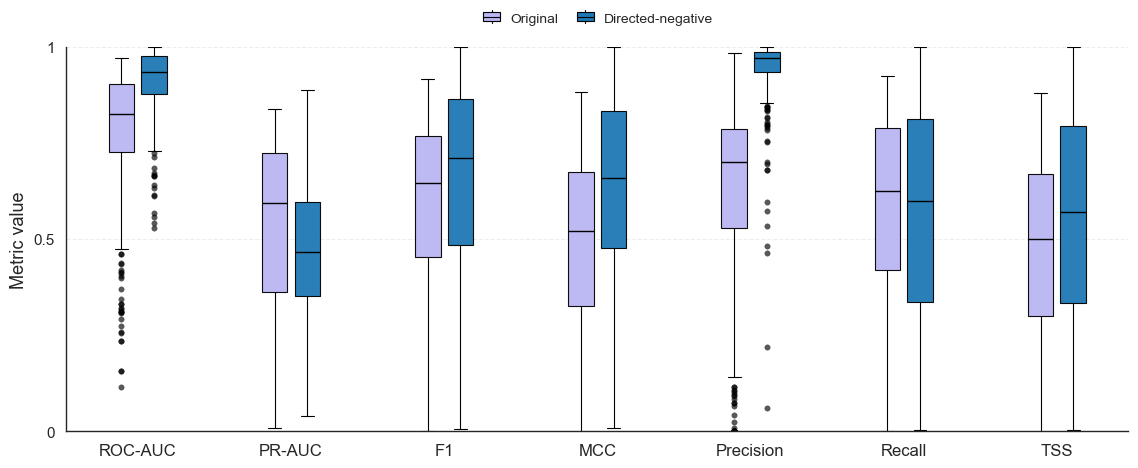

In [37]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.1)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
TRAIN_RATIO_TARGET = 90
NODES_THRESHOLD = 0

RESULTS_DIR_ORIGINAL = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "prediction_scores_logs"
)

RESULTS_DIR_DIR_NEG = (
    REPO_ROOT
    / "src/matlab/data/performance_207_constraint_sufficient_webs"
    / "prediction_scores_logs"
)

FOODWEB_CSV = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/performance_207_constraint_sufficient_webs"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / f"predictive_metrics_original_vs_dir_neg_train{TRAIN_RATIO_TARGET}_web_level.png"

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]

K_TARGET = None
K_COL = "K"
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIR_NEG = "*_tax_mass_results_random_wlnm_dir_neg.csv"

SHOW_WEB_LEVEL_FLIERS = True

# ============================================================
# Helpers
# ============================================================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    if TRAIN_RATIO_COL not in df.columns:
        print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
        return None

    df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

    if df.empty:
        return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    records = []
    foodweb = parse_foodweb_from_name(csv_path.name)

    for run_idx, row in df.reset_index(drop=True).iterrows():
        out = {
            "Foodweb": foodweb,
            "Version": version,
            "Run": run_idx + 1,
            "n_runs_in_file_after_filter": int(len(df)),
            "file": csv_path.name,
            "folder": str(csv_path.parent),
        }

        valid_any = False

        for metric in METRICS:
            if metric in df.columns:
                val = row[metric]
                out[metric] = float(val) if pd.notna(val) else np.nan
                if pd.notna(val):
                    valid_any = True
            else:
                out[metric] = np.nan

        if valid_any:
            records.append(out)

    return records if records else None


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        recs = load_one_csv(p, version=version)
        if recs is not None:
            rows.extend(recs)

    return rows


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# Load run-level CSVs
# ============================================================
rows = []
rows += load_folder(
    RESULTS_DIR_ORIGINAL,
    GLOB_PATTERN_ORIGINAL,
    version="original",
)
rows += load_folder(
    RESULTS_DIR_DIR_NEG,
    GLOB_PATTERN_DIR_NEG,
    version="dir_neg",
)

run_df = pd.DataFrame(rows)

if run_df.empty:
    raise RuntimeError("No valid rows after loading folders. Check paths or CSV columns.")

# ============================================================
# Apply node filter
# ============================================================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
run_df["FW_KEY"] = run_df["Foodweb"].apply(normalize_fw_label)

allowed_fw_keys = set(
    meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in run-level results before node filter: {run_df['FW_KEY'].nunique()}")

run_df = run_df[run_df["FW_KEY"].isin(allowed_fw_keys)].copy()

if run_df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")
print(f"[INFO] Run-level rows after filtering: {len(run_df):,}")
print(run_df.groupby("Version").size())

# ============================================================
# Web-level aggregation
# ============================================================
# This is the key correction:
# one row per Foodweb × Version, after averaging repeated runs.
agg_dict = {metric: "mean" for metric in METRICS}
agg_dict["Run"] = "count"

web_df = (
    run_df
    .groupby(["Foodweb", "FW_KEY", "Version"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Run": "ValidRuns"})
)

print(f"[INFO] Web-level rows after averaging runs: {len(web_df):,}")
print(web_df.groupby("Version").agg(
    FoodWebs=("Foodweb", "nunique"),
    MinRuns=("ValidRuns", "min"),
    MedianRuns=("ValidRuns", "median"),
    MaxRuns=("ValidRuns", "max"),
))

# ============================================================
# Summary table
# ============================================================
order = ["original", "dir_neg"]

label_map = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

palette = {
    "original": "#bab6f2",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

summary_rows = []

for version in order:
    for metric_col, metric_label in plot_metrics:
        vals = web_df.loc[web_df["Version"] == version, metric_col].dropna()

        summary_rows.append({
            "Version": label_map.get(version, version),
            "Metric": metric_label,
            # "N food webs": int(vals.shape[0]),
            "Mean": vals.mean(),
            "Median": vals.median(),
            "SD": vals.std(ddof=1),
            "Variance": vals.var(ddof=1),
        })

summary_table = pd.DataFrame(summary_rows)
for col in ["Mean", "Median", "SD", "Variance"]:
    summary_table[col] = summary_table[col].round(4)

print("\n=== Web-level predictive metric summary ===")
display(summary_table)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

offsets = np.array([-0.16, 0.16])
box_width = 0.25

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            web_df.loc[web_df["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.65,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [label for _, label in plot_metrics],
    rotation=0,
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Metric value", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(order),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(ax=ax)
plt.tight_layout()

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_45789/3440769619.py:104: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FOODWEB"] = derive_foodweb_from_filename(path)
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_45789/3440769619.py:154: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)


[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 207
[INFO] Foodwebs in results after filter: 207
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 207


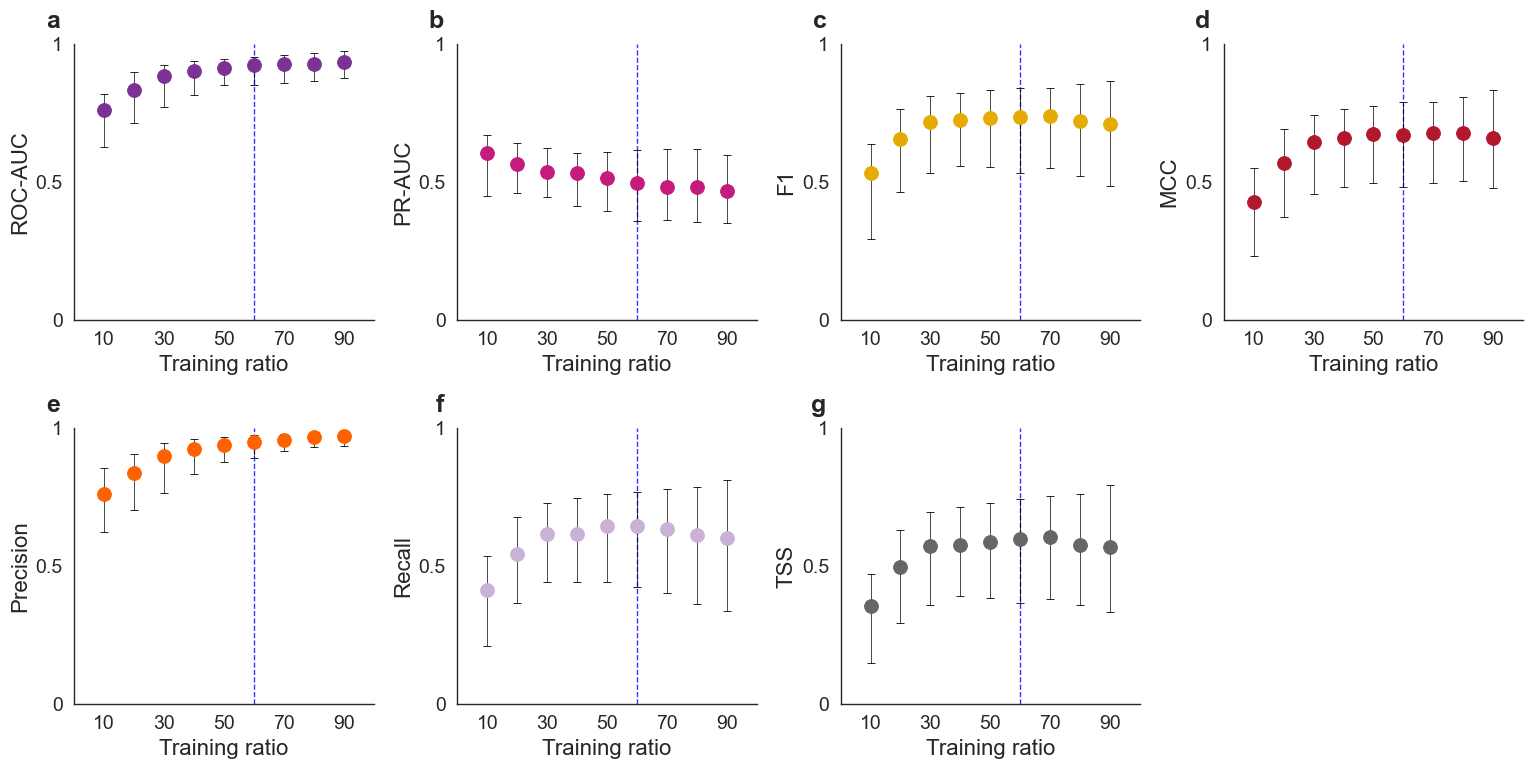

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.35)
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/performance_207_constraint_sufficient_webs/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = False
Y_MIN = 0.0

# Static y-axis for all panels
INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # brown
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_tax_mass_results_random_wlnm_dir_neg", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    # Keep all plotted train-ratio values, but only label the main x-axis ticks.
    visible_ticks = [10, 30, 50, 70, 90]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels([str(t) for t in visible_ticks])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}

# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False
)

# Make axes always 2D, then flatten for easy indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    # No panel title; use the metric name as the y-axis title for each panel
    ax.set_title("")

    # Add x-axis label to all panels
    ax.set_xlabel("Training ratio", fontsize=16)

    # y-axis title for each panel
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=16)

    # Panel letters
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

# Hide any unused subplot(s)
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/performance_207_constraint_sufficient_webs/statistical_tests/athen/outlier_filtered/train_ratio_60/athen_web_level_metrics_train60_outlier_filtered.csv
[INFO] Loaded outlier-filtered web-level rows: 828
[INFO] Plotting rows after empirical/mean-pseudo expansion: 1,656
[INFO] Each food web contributes one empirical value and one filtered mean pseudo value.
[INFO] Mean pseudo values were calculated after removing pseudo-run outliers.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,207,228,37,50.0
1,MeanGenerality,207,288,40,49.0
2,MeanTrophicHeight,207,726,19,45.0
3,MeanVulnerability,207,202,41,50.0


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/performance_207_constraint_sufficient_webs/statistical_tests/athen/outlier_filtered/train_ratio_60/fig5_wlnm_dir_neg_train60_web_level_outlier_filtered.png


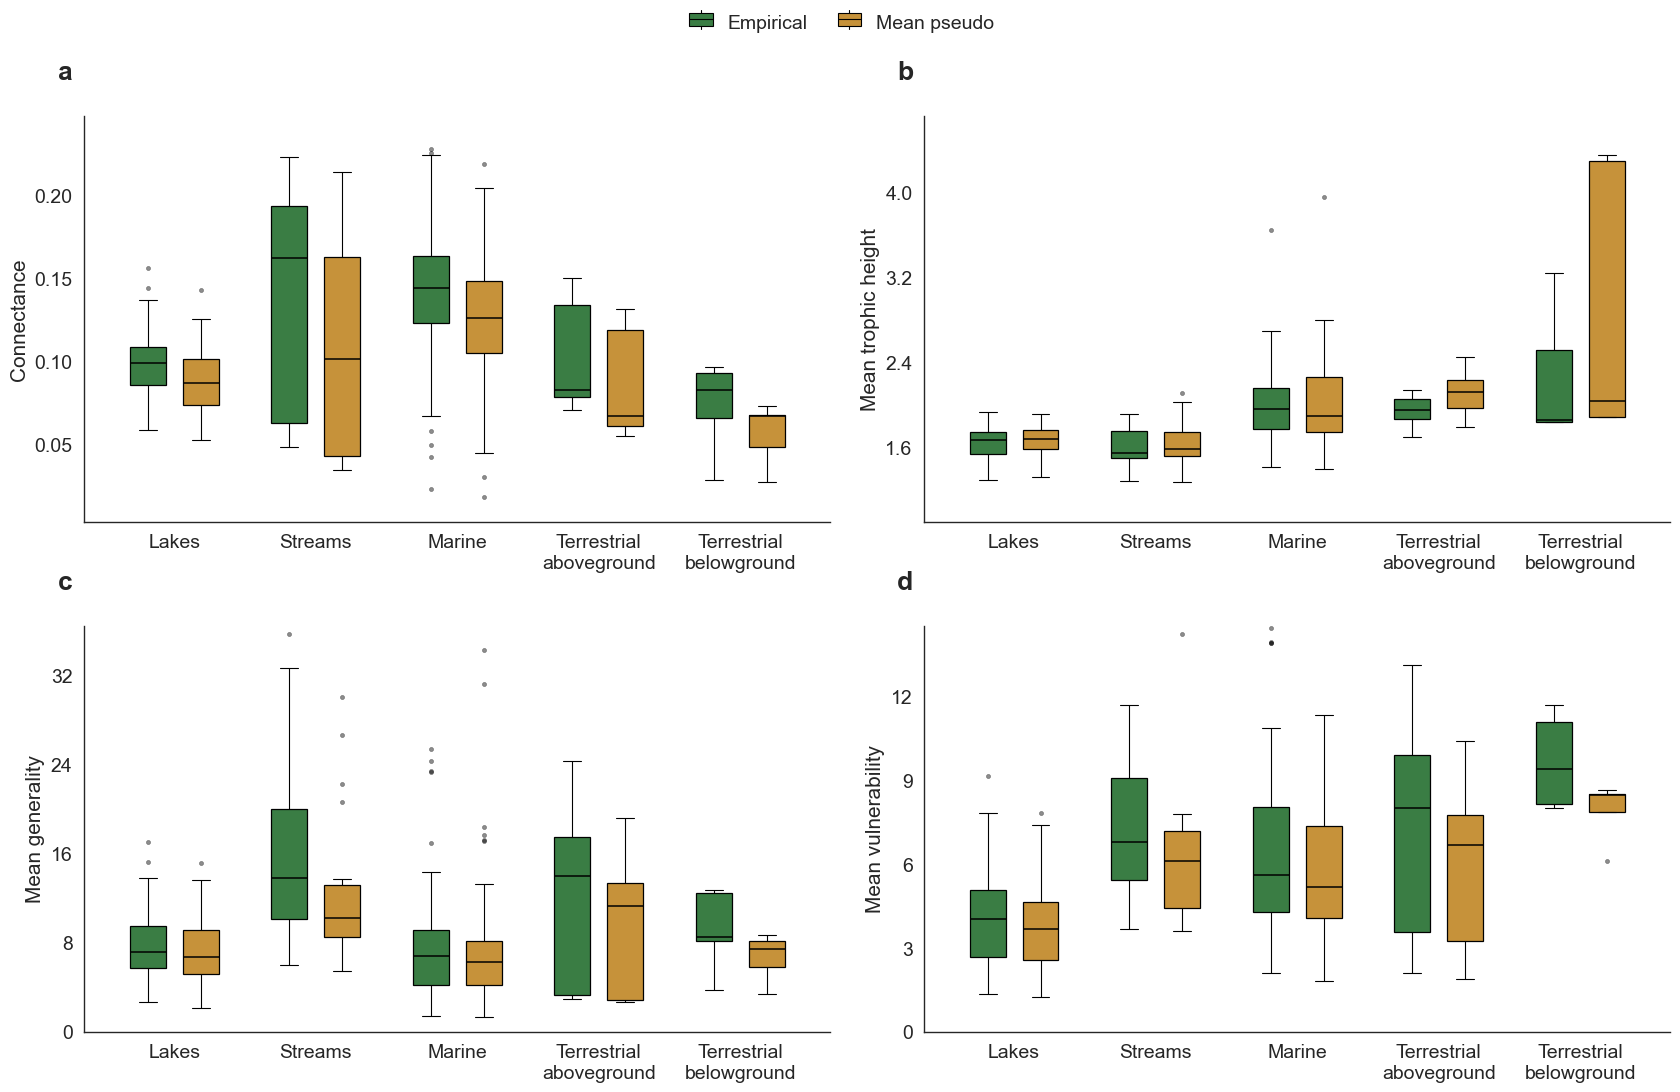

In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()
TRAIN_RATIO = 60

ATHEN_OUTLIER_DIR = (
    REPO_ROOT
    / "src/matlab/data/performance_207_constraint_sufficient_webs"
    / "statistical_tests/athen/outlier_filtered"
    / f"train_ratio_{TRAIN_RATIO}"
)

ATHEN_WEB_LEVEL_FILTERED = (
    ATHEN_OUTLIER_DIR
    / f"athen_web_level_metrics_train{TRAIN_RATIO}_outlier_filtered.csv"
)

OUT_PATH = (
    ATHEN_OUTLIER_DIR
    / f"fig5_wlnm_dir_neg_train{TRAIN_RATIO}_web_level_outlier_filtered.png"
)

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.30
TYPE_OFFSET = 0.22
GROUP_SPACING = 1.18

# These are web-level boxplot fliers, not the pseudo-run outliers.
# Pseudo-run outliers have already been removed before MeanPseudoAfterFiltering.
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

type_palette = {
    "Empirical": "#3A7D44",
    "Mean pseudo": "#C6923A",
}

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def draw_box(ax, values, position, facecolor, showfliers=False):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={
            "facecolor": facecolor,
            "edgecolor": "black",
            "linewidth": 0.9,
        },
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.8,
        },
        capprops={
            "color": "black",
            "linewidth": 0.8,
        },
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(grouped_values, lower_bound=0.0, pad_fraction=0.12):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr

            non_fliers = values[
                (values >= lower_fence)
                & (values <= upper_fence)
            ]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([lower_whisker, q1])
        visible_highs.extend([upper_whisker, q3])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(visible_lows)
    local_max = np.nanmax(visible_highs)

    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD OUTLIER-FILTERED WEB-LEVEL DATA
# ============================================================
athen = pd.read_csv(ATHEN_WEB_LEVEL_FILTERED)

athen["TrainRatio"] = pd.to_numeric(athen["TrainRatio"], errors="coerce")
athen["EmpiricalValue"] = pd.to_numeric(athen["EmpiricalValue"], errors="coerce")
athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
    athen["MeanPseudoAfterFiltering"],
    errors="coerce",
)
athen["IncludedAfterFiltering"] = (
    pd.to_numeric(athen["IncludedAfterFiltering"], errors="coerce")
    .fillna(0)
    .astype(int)
)
athen["OutlierRunsRemoved"] = pd.to_numeric(
    athen["OutlierRunsRemoved"],
    errors="coerce",
).fillna(0).astype(int)
athen["ValidRunsAfterFiltering"] = pd.to_numeric(
    athen["ValidRunsAfterFiltering"],
    errors="coerce",
).fillna(0).astype(int)

plot_source = (
    athen[
        (athen["TrainRatio"] == TRAIN_RATIO)
        & (athen["Metric"].isin(metric_order))
        & (athen["IncludedAfterFiltering"] == 1)
    ]
    .copy()
)

plot_source["ecosystem"] = (
    plot_source["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Build plotting dataframe:
# one empirical value per food web and one filtered mean pseudo value per food web.
empirical_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "EmpiricalValue"]
].rename(columns={"EmpiricalValue": "value"})
empirical_df["Web type"] = "Empirical"

pseudo_df = plot_source[
    ["FoodWeb", "ecosystem", "Metric", "MeanPseudoAfterFiltering"]
].rename(columns={"MeanPseudoAfterFiltering": "value"})
pseudo_df["Web type"] = "Mean pseudo"

plot_df = pd.concat([empirical_df, pseudo_df], ignore_index=True)
plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
plot_df = plot_df.dropna(subset=["value", "ecosystem", "Metric", "Web type"])

print(f"[INFO] Source file: {ATHEN_WEB_LEVEL_FILTERED}")
print(f"[INFO] Loaded outlier-filtered web-level rows: {len(plot_source):,}")
print(f"[INFO] Plotting rows after empirical/mean-pseudo expansion: {len(plot_df):,}")
print("[INFO] Each food web contributes one empirical value and one filtered mean pseudo value.")
print("[INFO] Mean pseudo values were calculated after removing pseudo-run outliers.")

removed_summary = (
    plot_source
    .groupby("Metric", as_index=False)
    .agg(
        FoodWebs=("FoodWeb", "nunique"),
        TotalPseudoRunOutliersRemoved=("OutlierRunsRemoved", "sum"),
        MinRetainedRuns=("ValidRunsAfterFiltering", "min"),
        MedianRetainedRuns=("ValidRunsAfterFiltering", "median"),
    )
)

display(removed_summary)

# ============================================================
# PLOT
# ============================================================
n_panels = len(metric_order)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
axes = np.array(axes).reshape(-1)

legend_handles = [
    {"facecolor": type_palette["Empirical"], "edgecolor": "black", "linewidth": 0.8},
    {"facecolor": type_palette["Mean pseudo"], "edgecolor": "black", "linewidth": 0.8},
]
legend_labels = ["Empirical", "Mean pseudo"]

for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
    panel_df = plot_df[plot_df["Metric"] == metric].copy()

    if panel_df.empty:
        ax.set_visible(False)
        continue

    present_ecosystems = [
        eco for eco in base_ecosystem_order
        if eco in panel_df["ecosystem"].unique()
    ]
    extra_ecosystems = [
        eco for eco in panel_df["ecosystem"].unique()
        if eco not in base_ecosystem_order
    ]
    eco_order = present_ecosystems + extra_ecosystems

    base_positions = np.arange(len(eco_order)) * GROUP_SPACING
    boxplot_groups = []

    for eco, base_x in zip(eco_order, base_positions):
        eco_df = panel_df[panel_df["ecosystem"] == eco]

        empirical_values = (
            eco_df[eco_df["Web type"] == "Empirical"]["value"]
            .dropna()
            .values
        )

        pseudo_values = (
            eco_df[eco_df["Web type"] == "Mean pseudo"]["value"]
            .dropna()
            .values
        )

        if len(empirical_values):
            draw_box(
                ax=ax,
                values=empirical_values,
                position=base_x - TYPE_OFFSET,
                facecolor=type_palette["Empirical"],
                showfliers=SHOW_WEB_LEVEL_FLIERS,
            )
            boxplot_groups.append(empirical_values)

        if len(pseudo_values):
            draw_box(
                ax=ax,
                values=pseudo_values,
                position=base_x + TYPE_OFFSET,
                facecolor=type_palette["Mean pseudo"],
                showfliers=SHOW_WEB_LEVEL_FLIERS,
            )
            boxplot_groups.append(pseudo_values)

    ax.set_title("")
    ax.set_ylabel(metric_labels[metric], fontsize=15)
    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=14)

    ylim = get_boxplot_visible_ylim(
        boxplot_groups,
        lower_bound=0.0,
        pad_fraction=0.12,
    )

    if ylim is not None:
        ax.set_ylim(*ylim)
        ax.yaxis.set_major_locator(MaxNLocator(5))

    ax.set_xlim(base_positions[0] - 0.75, base_positions[-1] + 0.75)

    ax.set_xticks(base_positions)
    ax.set_xticklabels(
        [format_ecosystem_label(eco) for eco in eco_order],
        rotation=0,
        fontsize=14,
    )

    ax.grid(False, axis="x")
    ax.grid(False, axis="y")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[idx],
        xy=(0, 1.05),
        xycoords="axes fraction",
        xytext=(-8, 8),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=19,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(len(metric_order), len(axes)):
    axes[j].set_visible(False)

# ============================================================
# GLOBAL LEGEND
# ============================================================
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={dict: HandlerMiniBoxplot()},
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    columnspacing=1.4,
    borderpad=0.2,
    labelspacing=0.45,
)

fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_45789/529112139.py:109: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Foodweb"] = os.path.basename(file).split("_results_")[0]


[INFO] Filtered results by TrainRatio: kept only TrainRatio = 90.
[INFO] Run-level rows after TrainRatio filter: 10,350
[INFO] Filtered food webs by size: kept 207 / 207 (>= 0 nodes).

[INFO] Run-level observations after filtering:
Total rows in df_merged: 10,350
Rows per ecosystem:
EcosystemType
lakes                      2600
marine                     5600
streams                    1150
terrestrial aboveground     750
terrestrial belowground     250
dtype: int64

[INFO] Web-level observations after averaging repeated runs:
Total web-level rows: 207


,EcosystemType,FoodWebs,MinRunsAveraged,MedianRunsAveraged,MaxRunsAveraged
0,lakes,52,50,50.0,50
1,marine,112,50,50.0,50
2,streams,23,50,50.0,50
3,terrestrial aboveground,15,50,50.0,50
4,terrestrial belowground,5,50,50.0,50



=== Web-level precision median and variance by ecosystem ===


,EcosystemType,n_foodwebs,Precision_Median,Precision_Variance
0,lakes,52,0.9856,0.007255
1,marine,112,0.9567,0.010219
2,streams,23,0.9863,0.060272
3,terrestrial aboveground,15,0.9850,0.003979
4,terrestrial belowground,5,0.9541,0.000298



=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial belowground (median = 0.9541, variance = 0.000298, n_foodwebs = 5)
Highest median precision: streams (median = 0.9863, variance = 0.060272, n_foodwebs = 23)
Lowest variance:          terrestrial belowground (variance = 0.000298, median = 0.9541, n_foodwebs = 5)
Highest variance:         streams (variance = 0.060272, median = 0.9863, n_foodwebs = 23)
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/performance_207_constraint_sufficient_webs/statistical_tests/athen/figures/predictive_metrics_wlnm_dir_neg_train60_by_ecosystem_web_level.png


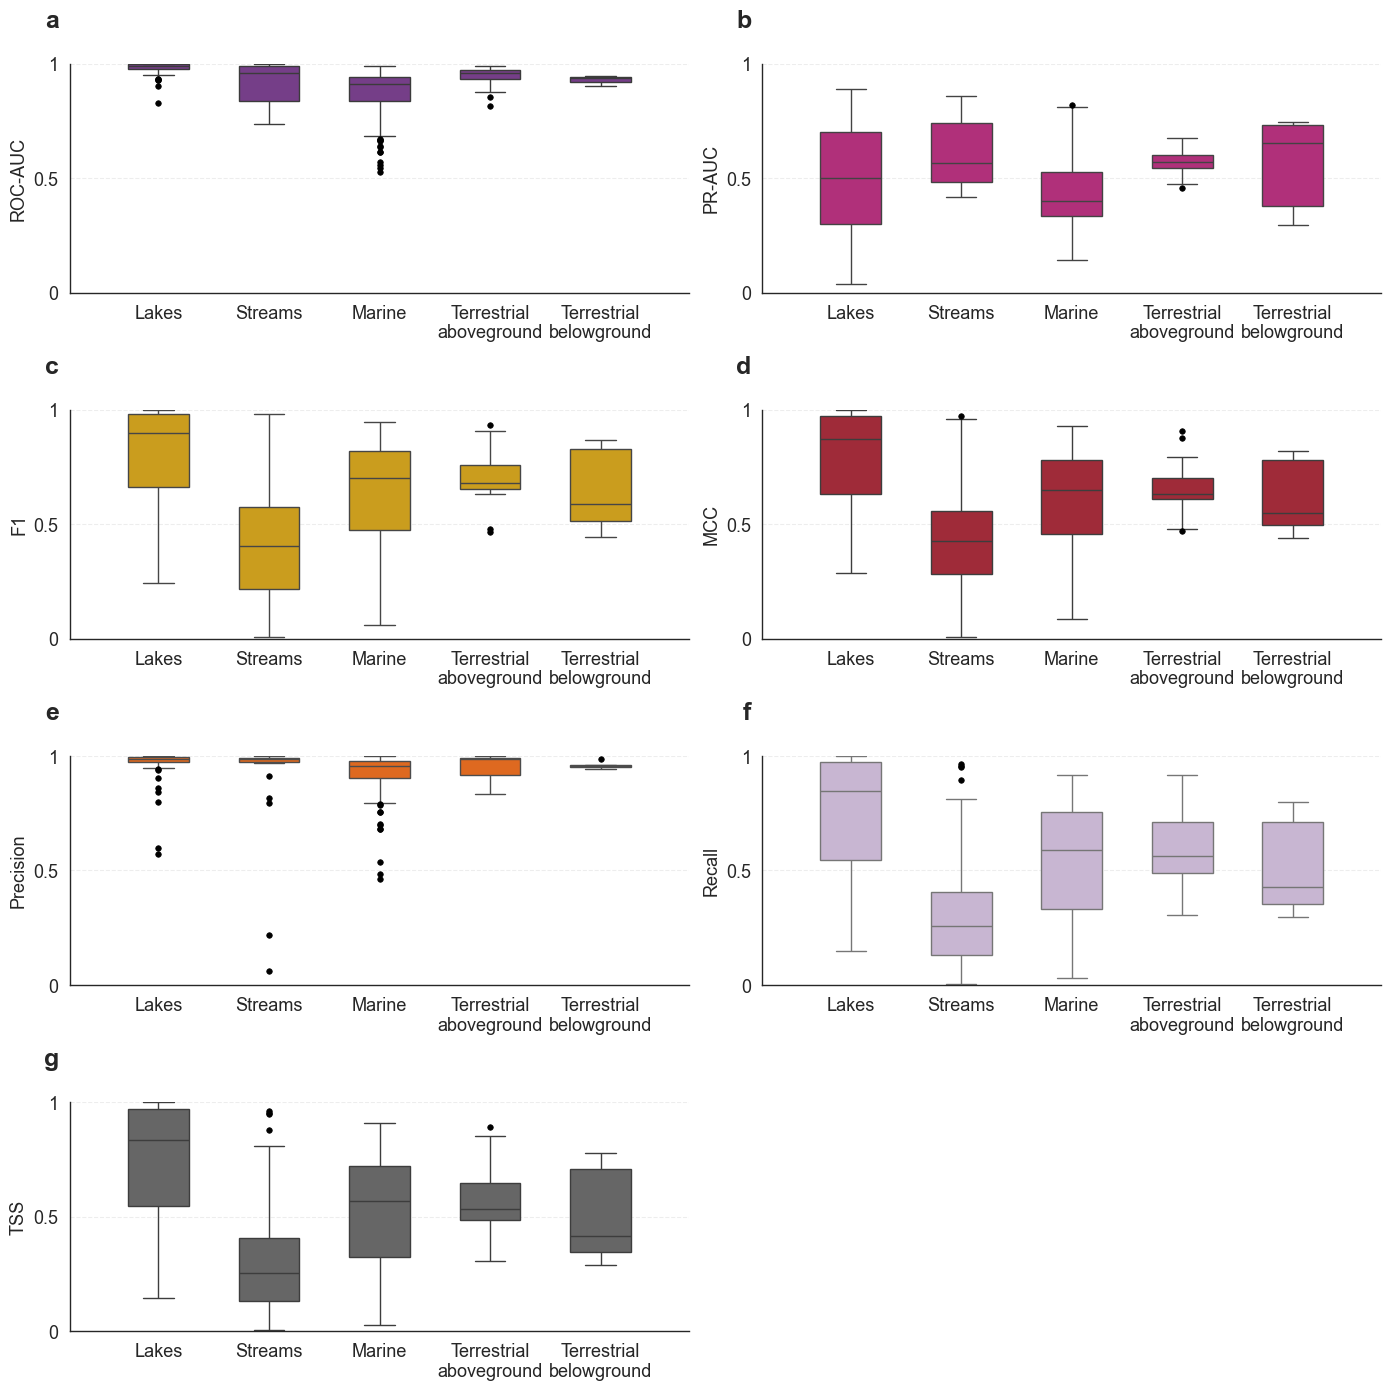

In [ ]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_context("paper")
sns.set_style("white")

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
results_dir = (
    REPO_ROOT
    / "src/matlab/data/performance_207_constraint_sufficient_webs"
    / "prediction_scores_logs"
)

ecosystem_file = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/performance_207_constraint_sufficient_webs"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "predictive_metrics_wlnm_dir_neg_train60_by_ecosystem_web_level.png"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
xtick_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC", "Precision", "Recall", "TSS"]

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

SHOW_WEB_LEVEL_FLIERS = True

metric_palette = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "TestMCC": "#B2182B",
    "TestTSS": "#666666",
    "TestTPR": "#1B9E77",
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}

# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one, e.g. 'S', 'nodes', 'num_species', or 'node_count'."
    )

# ============================================================
# Load result CSVs
# ============================================================
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# ============================================================
# Filter TrainRatio = 60
# ============================================================
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

for metric in METRIC_ORDER:
    if metric in df_all.columns:
        df_all[metric] = pd.to_numeric(df_all[metric], errors="coerce")
    else:
        raise RuntimeError(f"Metric column '{metric}' not found in result CSVs.")

print(f"[INFO] Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")
print(f"[INFO] Run-level rows after TrainRatio filter: {len(df_all):,}")

# ============================================================
# Merge metrics with ecosystem metadata
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left",
)

# ============================================================
# Apply node-count filter
# ============================================================
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"[INFO] Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

if df_merged.empty:
    raise ValueError(f"No food webs left after filtering Nodes >= {MIN_NODES}.")

print("\n[INFO] Run-level observations after filtering:")
print(f"Total rows in df_merged: {len(df_merged):,}")
print("Rows per ecosystem:")
print(df_merged.groupby("EcosystemType").size())

# ============================================================
# Key correction: web-level aggregation
# ============================================================
# Each food web contributes one observation per metric.
# The 20 repeated WLNM runs are averaged before plotting.
agg_dict = {metric: "mean" for metric in METRIC_ORDER}
agg_dict.update({
    "Iteration": "count",
    node_col: "first",
})

df_web = (
    df_merged
    .groupby(["Foodweb", "EcosystemType"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Iteration": "RunsAveraged"})
)

print("\n[INFO] Web-level observations after averaging repeated runs:")
print(f"Total web-level rows: {len(df_web):,}")
display(
    df_web
    .groupby("EcosystemType")
    .agg(
        FoodWebs=("Foodweb", "nunique"),
        MinRunsAveraged=("RunsAveraged", "min"),
        MedianRunsAveraged=("RunsAveraged", "median"),
        MaxRunsAveraged=("RunsAveraged", "max"),
    )
    .reset_index()
)

# ============================================================
# Precision summary by ecosystem, web-level
# ============================================================
precision_summary = (
    df_web
    .dropna(subset=["EcosystemType", "Precision"])
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Web-level precision median and variance by ecosystem ===")
display(precision_summary)

lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]
lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")
print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']}, "
    f"n_foodwebs = {lowest_precision['n_foodwebs']})"
)
print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']}, "
    f"n_foodwebs = {highest_precision['n_foodwebs']})"
)
print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']}, "
    f"n_foodwebs = {lowest_variance['n_foodwebs']})"
)
print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']}, "
    f"n_foodwebs = {highest_variance['n_foodwebs']})"
)

# ============================================================
# Prepare long-format web-level data
# ============================================================
df_plot = df_web.melt(
    id_vars=["Foodweb", "EcosystemType", "RunsAveraged"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)

# ============================================================
# Preferred ecosystem order
# ============================================================
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_web["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# ============================================================
# Labels
# ============================================================
labels_map = (
    df_web[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)

def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    return label_replacements.get(eco_lower, eco_clean.capitalize())

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

subset = df_plot.copy()
subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        width=0.55,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)
    ax.set_ylim(0, 1.0)
    ax.grid(False, axis="x")

    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Result files found: 207
[INFO] Food webs in result files before filtering: 207
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 207 -> 207 food webs
[CHECK] TrainRatio = 90.0: 207 -> 207 food webs
[CHECK] Nodes >= 0: 207 -> 207 food webs
[CHECK] available connectance for x-axis: 207 -> 207 food webs
[FINAL] Food webs retained after structural filters: 207

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = 0.2499x + 0.8741; F1,205 = 2.3907; R² = 0.0115; P = 0.1236; n = 207
b) PR-AUC: y = 0.7239x + 0.3886; F1,205 = 7.0859; R² = 0.0334; P = 0.0084; n = 207
c) F1: y = 0.2847x + 0.6246; F1,205 = 0.5099; R² = 0.0025; P = 0.4760; n = 207
d) MCC: y = 0.1771x + 0.6202; F1,205 = 0.2297; R² = 0.0011; P = 0.6323; n = 207
e) Precision: y = 0.0034x + 0.9300; F1,205 = 0.0003; R² = 0.0000; P = 0.9858; n = 207
f) Recall: y = 0.2842x + 0.5377; F1,205 = 0.4071; R² = 0.0020; P = 0.5242; n = 207
g) TSS: y = 0.2155x + 0.5319; F1,205 = 0.2404; R² = 0.0012; P = 0.6244;

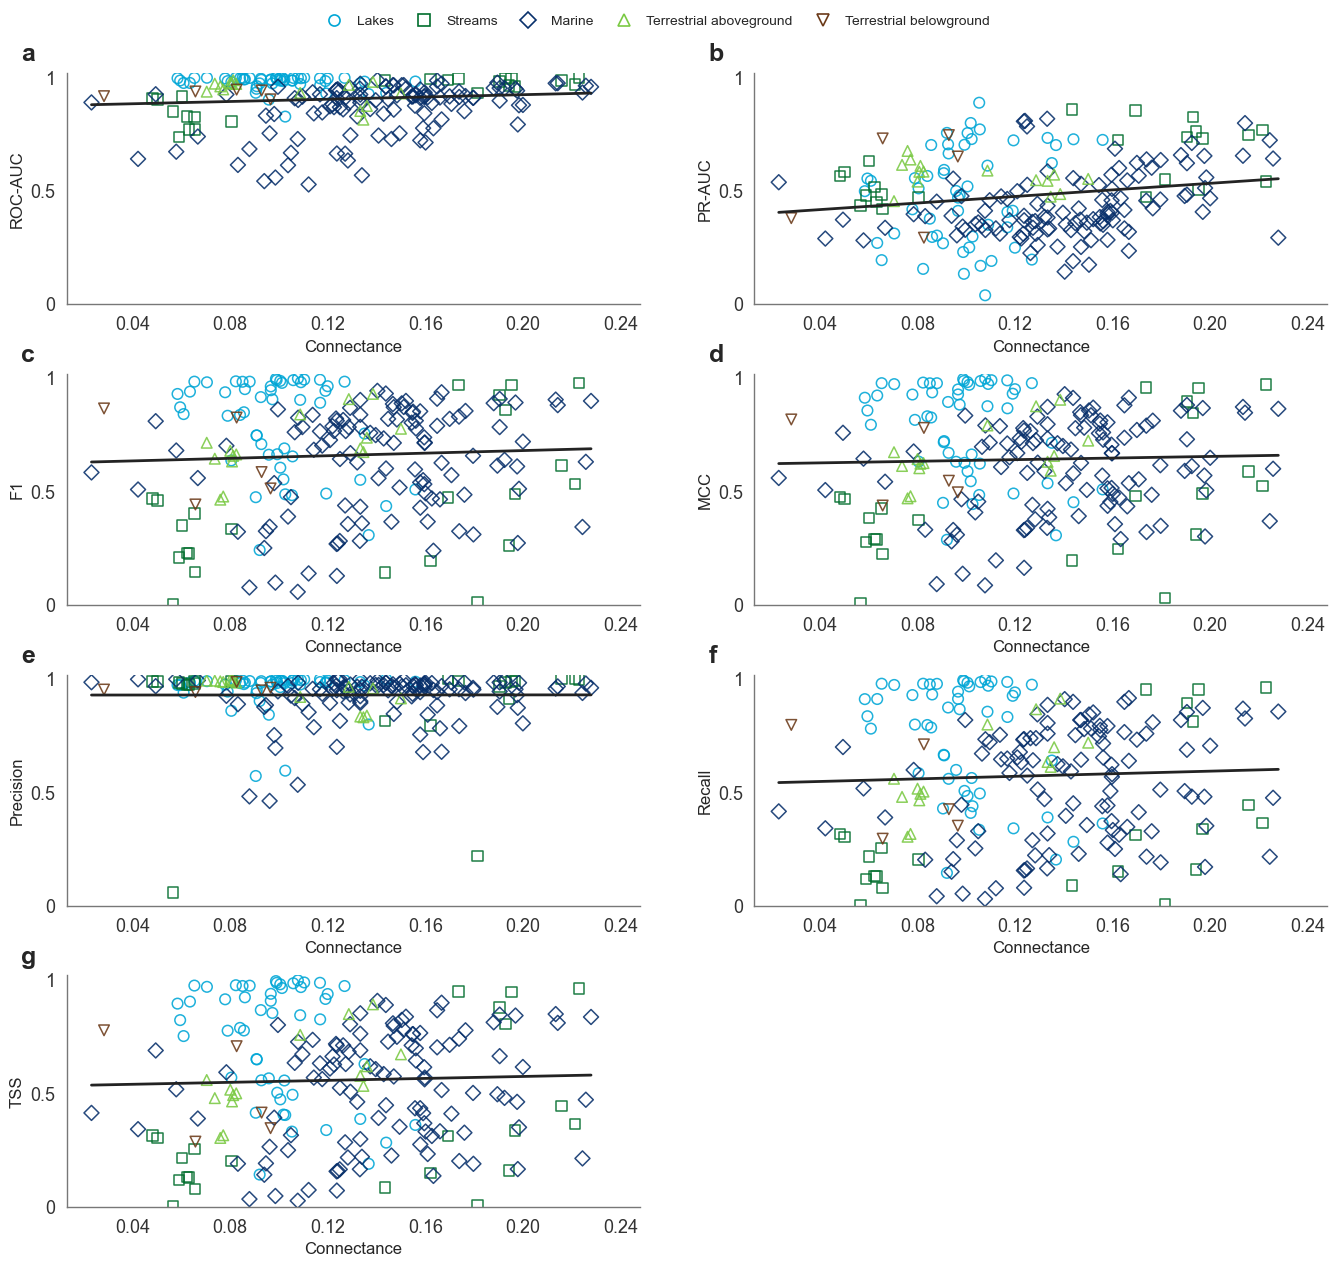

In [ ]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "src/matlab/data/performance_207_constraint_sufficient_webs/prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    # Removed deprecated copy=False argument to avoid Pandas4Warning.
    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(
        meta["MetadataConnectance"],
        errors="coerce",
    )

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "TestTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )

    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (
            df.loc[can_compute_conn, "Nodes"]
            * (df.loc[can_compute_conn, "Nodes"] - 1)
        )
    )

    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO}", before, after)
    before = after

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"]).copy()
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_count("available connectance for x-axis", df_before_x, df_after_x)

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after structural filters: {df['Foodweb'].nunique()}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(data: pd.DataFrame, metric: str, n_points: int = 100):
    """
    Fits an OLS linear regression:

        metric ~ EmpiricalConnectanceForPlot

    Returns fitted line coordinates, equation coefficients, R², P-value,
    F-statistic, degrees of freedom, and n.
    """
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return None

    work["EmpiricalConnectanceForPlot"] = work["EmpiricalConnectanceForPlot"].astype(float)
    work[metric] = work[metric].astype(float)

    if len(work) < 3 or work["EmpiricalConnectanceForPlot"].nunique() < 2:
        return None

    x = work[["EmpiricalConnectanceForPlot"]]
    y = work[metric]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["EmpiricalConnectanceForPlot"]

    x_line = np.linspace(
        work["EmpiricalConnectanceForPlot"].min(),
        work["EmpiricalConnectanceForPlot"].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {"EmpiricalConnectanceForPlot": x_line}
    )
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["EmpiricalConnectanceForPlot"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def format_equation(slope: float, intercept: float) -> str:
    sign = "+" if intercept >= 0 else "-"
    return f"y = {slope:.4f}x {sign} {abs(intercept):.4f}"


def format_p_value(p_value: float) -> str:
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Connectance", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(axis="both", colors="#333333", labelsize=13)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    available_ecosystems = (
        plot_df["EcosystemType"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(eco): eco
        for eco in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        eco
        for eco in available_ecosystems
        if eco not in eco_order
    ]

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        # figsize=(12.5, 4.6 * n_rows),
        figsize=(14, 14),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    total_foodwebs = plot_df["Foodweb"].nunique()

    x_min = plot_df["EmpiricalConnectanceForPlot"].min()
    x_max = plot_df["EmpiricalConnectanceForPlot"].max()

    print("\n=== OLS linear regression: metric ~ empirical connectance ===")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric]).copy()
        n_metric_foodwebs = data["Foodweb"].nunique()

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]

            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        fit = fit_linear_regression(data, metric)

        if fit is not None:
            ax.plot(
                fit["x_line"],
                fit["y_line"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(fit["slope"], fit["intercept"])
            p_text = format_p_value(fit["p_value"])

            print(
                f"{panel_letters[i]}) {label}: "
                f"{equation}; "
                f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
                f"R² = {fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[i]}) {label}: "
                "regression not fitted; insufficient data."
            )

        style_axes(ax, label)

        # ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)

        ax.set_xlim(
            max(0.0, x_min - 0.01),
            x_max + 0.02,
        )

        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(["0", "0.5", "1"])

        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

Filtered data: TrainRatio = 90.0, Nodes >= 0. Rows kept: 10350 / 93150. Food webs kept: 207 / 207.

=== OLS linear regression: metric ~ number of nodes ===
a) ROC-AUC: y = 0.927220 - 0.000420x; F1,205 = 13.6396; R² = 0.0624; P = 0.0003; n = 207
b) PR-AUC: y = 0.477665 + 0.000042x; F1,205 = 0.0445; R² = 0.0002; P = 0.8331; n = 207
c) F1: y = 0.706377 - 0.000891x; F1,205 = 9.9918; R² = 0.0465; P = 0.0018; n = 207
d) MCC: y = 0.682601 - 0.000778x; F1,205 = 8.8259; R² = 0.0413; P = 0.0033; n = 207
e) Precision: y = 0.915230 + 0.000295x; F1,205 = 4.5790; R² = 0.0218; P = 0.0335; n = 207
f) Recall: y = 0.637938 - 0.001250x; F1,205 = 16.2193; R² = 0.0733; P < 0.0001; n = 207
g) TSS: y = 0.618032 - 0.001145x; F1,205 = 13.8450; R² = 0.0633; P = 0.0003; n = 207


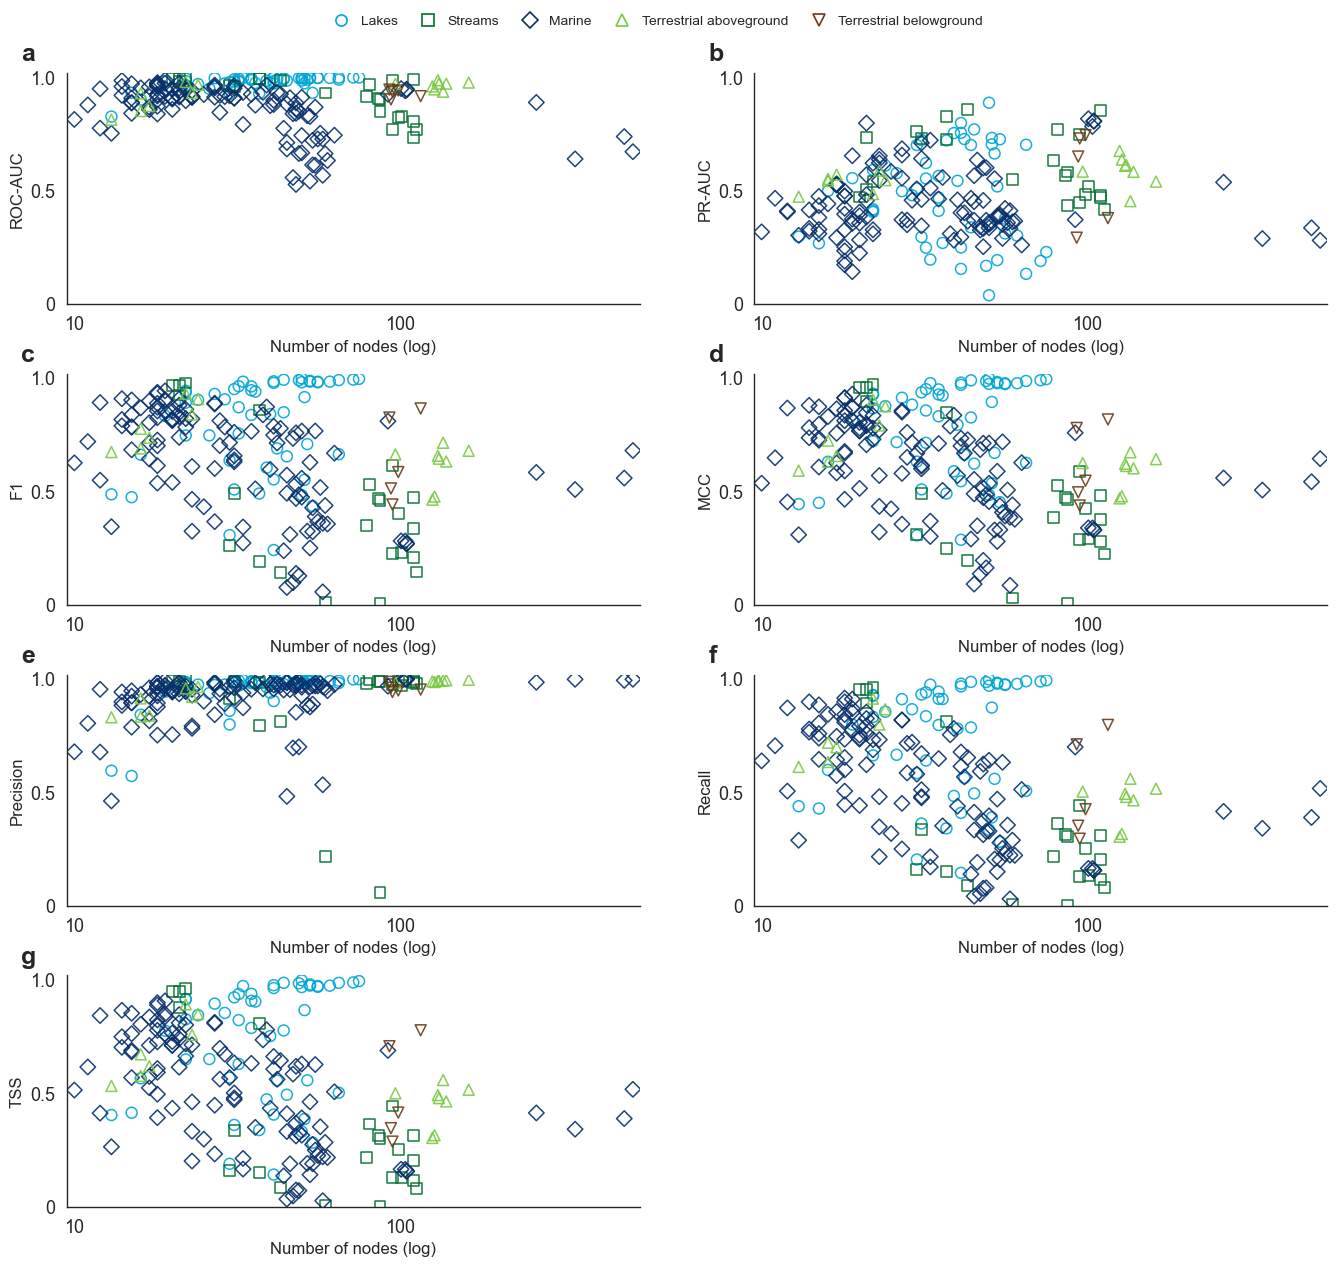

In [ ]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, ScalarFormatter


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

RESULTS_DIR = Path(
    "../../../src/matlab/data/performance_207_constraint_sufficient_webs/prediction_scores_logs"
)
ECOSYSTEM_FILE = Path(
    "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
MIN_NODES = 0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def format_p_value(p_value: float) -> str:
    if pd.isna(p_value):
        return "P = NA"
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


def format_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.6f} {sign} {abs(slope):.6f}x"


# ============================================================
# Regression helper
# ============================================================

def fit_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
    n_points: int = 100,
):
    """
    Fits an OLS linear regression:

        y_col ~ x_col

    For this figure:
        metric ~ Nodes

    The x-axis is linear, so Nodes are used directly without log transformation.
    """
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = work[x_col].astype(float)
    work[y_col] = work[y_col].astype(float)

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    x = work[[x_col]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params[x_col]

    x_line = np.linspace(
        work[x_col].min(),
        work[x_col].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({x_col: x_line})
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "intercept": intercept,
        "slope": slope,
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "p_value": model.pvalues[x_col],
        "r_squared": model.rsquared,
        "n": len(work),
        "model": model,
    }


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(ECOSYSTEM_FILE).copy()

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(
    df_ecosystem,
    ["ecosystemtype", "ecosystem", "ecosystem_type"],
)
nodes_col = find_column(
    df_ecosystem,
    ["nodes", "n_nodes", "num_nodes", "nodecount", "s"],
)

df_ecosystem = df_ecosystem.rename(
    columns={
        foodweb_col: "MetadataFoodweb",
        ecosystem_col: "EcosystemType",
        nodes_col: "Nodes",
    }
)

df_ecosystem = df_ecosystem[
    [
        "MetadataFoodweb",
        "EcosystemType",
        "Nodes",
    ]
].copy()

df_ecosystem["MetadataFoodweb"] = df_ecosystem["MetadataFoodweb"].astype(str)
df_ecosystem["FoodwebKey"] = df_ecosystem["MetadataFoodweb"].apply(
    normalize_foodweb_name
)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

df_ecosystem = df_ecosystem.drop_duplicates(subset=["FoodwebKey"]).copy()


# ============================================================
# Load results
# ============================================================

csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))

if not csv_files:
    raise RuntimeError(
        f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}"
    )

frames = []

for file in csv_files:
    df = pd.read_csv(file).copy()

    foodweb = extract_foodweb_name(file)
    foodweb_key = normalize_foodweb_name(foodweb)

    file_meta = pd.DataFrame(
        {
            "Foodweb": foodweb,
            "FoodwebKey": foodweb_key,
        },
        index=df.index,
    )

    df = pd.concat([df, file_meta], axis=1).copy()
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True).copy()

if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"}).copy()

if "TestMCC" not in df_all.columns and "MCC" in df_all.columns:
    df_all = df_all.rename(columns={"MCC": "TestMCC"}).copy()

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]

if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")


# ============================================================
# Merge + filter
# ============================================================

df_merged = df_all.merge(
    df_ecosystem[["FoodwebKey", "EcosystemType", "Nodes"]],
    on="FoodwebKey",
    how="left",
).copy()

if "TrainRatio" not in df_merged.columns:
    raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

df_merged["TrainRatio"] = normalize_train_ratio(df_merged["TrainRatio"])
df_merged["Nodes"] = pd.to_numeric(df_merged["Nodes"], errors="coerce")
df_merged["EcosystemType"] = df_merged["EcosystemType"].fillna("Unknown")

numeric_cols = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
    "TestTPR",
]

for col in numeric_cols:
    if col in df_merged.columns:
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

before_rows = len(df_merged)
before_foodwebs = df_merged["Foodweb"].nunique()

df_tr = df_merged[
    np.isclose(df_merged["TrainRatio"], TARGET_RATIO, equal_nan=False)
    & (df_merged["Nodes"] >= MIN_NODES)
].copy()

after_rows = len(df_tr)
after_foodwebs = df_tr["Foodweb"].nunique()

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: {after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        f"No rows left after filtering TrainRatio = {TARGET_RATIO} "
        f"and Nodes >= {MIN_NODES}."
    )


# ============================================================
# Mean per food web
# ============================================================

agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}

df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
    .copy()
)

df_scatter = df_scatter.dropna(subset=["Nodes"]).copy()

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

x_min = max(1, df_scatter["Nodes"].min() * 0.95)
x_max = min(X_MAX, df_scatter["Nodes"].max() * 1.05)


# ============================================================
# Ecosystem order + palette
# ============================================================

available_ecosystems = (
    df_scatter["EcosystemType"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

available_by_label = {
    format_ecosystem_label(eco): eco
    for eco in available_ecosystems
}

eco_order = [
    available_by_label[label]
    for label in ECOSYSTEM_ORDER
    if label in available_by_label
]

eco_order += [
    eco
    for eco in available_ecosystems
    if eco not in eco_order
]

df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True,
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

eco_markers = {
    eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
    for eco in eco_order
}


# ============================================================
# Plot
# ============================================================

n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(14, 14),
    sharex=False,
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")
total_foodwebs = df_scatter["Foodweb"].nunique()

print("\n=== OLS linear regression: metric ~ number of nodes ===")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    data = df_scatter.dropna(subset=["Nodes", metric_col]).copy()
    n_metric_foodwebs = data["Foodweb"].nunique()

    for eco in eco_order:
        sub = data[data["EcosystemType"] == eco]

        if sub.empty:
            continue

        ax.scatter(
            sub["Nodes"],
            sub[metric_col],
            marker=eco_markers[eco],
            facecolors="none",
            edgecolors=eco_palette[eco],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(eco),
        )

    fit = fit_linear_regression(data, "Nodes", metric_col)

    if fit is not None:
        # ax.plot(
        #     fit["x_line"],
        #     fit["y_line"],
        #     color="black",
        #     linewidth=2.0,
        #     linestyle="-",
        #     zorder=5,
        # )

        equation = format_equation(fit["intercept"], fit["slope"])
        p_text = format_p_value(fit["p_value"])

        print(
            f"{panel_letters[i]}) {metric_label}: "
            f"{equation}; "
            f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
            f"R² = {fit['r_squared']:.4f}; "
            f"{p_text}; "
            f"n = {fit['n']}"
        )

    else:
        print(
            f"{panel_letters[i]}) {metric_label}: "
            "regression not fitted; insufficient data."
        )

    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Number of nodes (log)", fontsize=12)

    ax.tick_params(axis="x", labelbottom=True, labelsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(axis="x", style="plain")

    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1.0"], fontsize=13)

    sns.despine(ax=ax)

    ax.text(
        -0.08,
        1.03,
        panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()


# ============================================================
# Figure-level legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=eco_markers[eco],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[eco],
        markeredgewidth=1.2,
        label=format_ecosystem_label(eco),
    )
    for eco in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    fontsize=10,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09,
)

plt.show()

---

CSV files found: 290
Rows: 1174500
Food webs: 290
Train ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


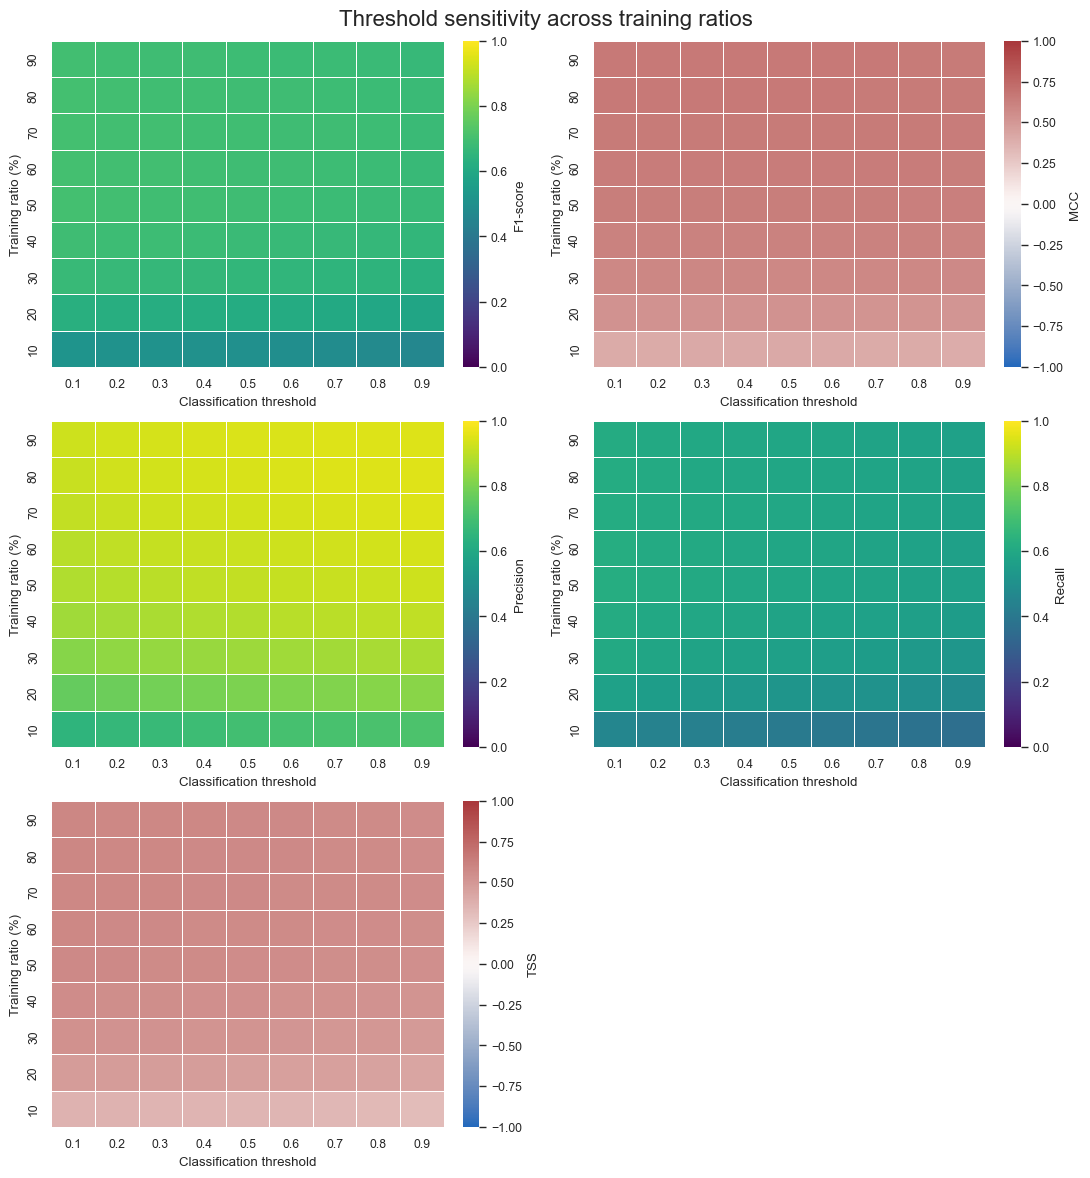

In [ ]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

# Metrics in the exact order requested
numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_labels = {
    "F1Score": "F1-score",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

usecols = [
    "Iteration",
    "Version",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *numeric_cols,
]

# -----------------------------
# Load CSV logs
# -----------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {LOG_DIR}")

frames = []
for csv_file in csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Keep only threshold-sweep rows
df = df[df["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep")].copy()

# Numeric cleanup
for col in ["TrainRatio", "Threshold", *numeric_cols]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Round axis values to avoid floating point label noise
df["TrainRatio"] = df["TrainRatio"].round(0).astype("Int64")
df["Threshold"] = df["Threshold"].round(2)

print("Rows:", len(df))
print("Food webs:", df["FoodWeb"].nunique())
print("Train ratios:", sorted(df["TrainRatio"].dropna().unique().tolist()))
print("Thresholds:", sorted(df["Threshold"].dropna().unique().tolist()))

# -----------------------------
# Aggregate
# -----------------------------
foodweb_level = (
    df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

summary = (
    foodweb_level.groupby(["TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Heatmap figure: 2 metrics per row
# -----------------------------
sns.set_theme(style="white", context="paper")

n_metrics = len(numeric_cols)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.4 * ncols, 3.8 * nrows),
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

train_order = sorted(summary["TrainRatio"].dropna().unique(), reverse=True)
threshold_order = sorted(summary["Threshold"].dropna().unique())

diverging_metrics = {"TestMCC", "TestTSS"}

for ax, metric_col in zip(axes, numeric_cols):
    metric_label = metric_labels.get(metric_col, metric_col)

    heat = summary.pivot(index="TrainRatio", columns="Threshold", values=metric_col)
    heat = heat.reindex(index=train_order, columns=threshold_order)

    if metric_col in diverging_metrics:
        cmap = "vlag"
        vmin = -1
        vmax = 1
        center = 0
    else:
        cmap = "viridis"
        vmin = 0
        vmax = 1
        center = None

    sns.heatmap(
        heat,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": metric_label},
    )

    # ax.set_title(metric_label)
    ax.set_xlabel("Classification threshold")
    ax.set_ylabel("Training ratio (%)")
    ax.set_xticklabels([f"{x:.1f}" for x in threshold_order], rotation=0)

for ax in axes[n_metrics:]:
    ax.axis("off")

fig.suptitle(
    "Threshold sensitivity across training ratios",
    fontsize=16,
    y=1.02,
)

plt.show()

CSV files found: 290
Rows: 1174500
Food webs: 290
Train ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


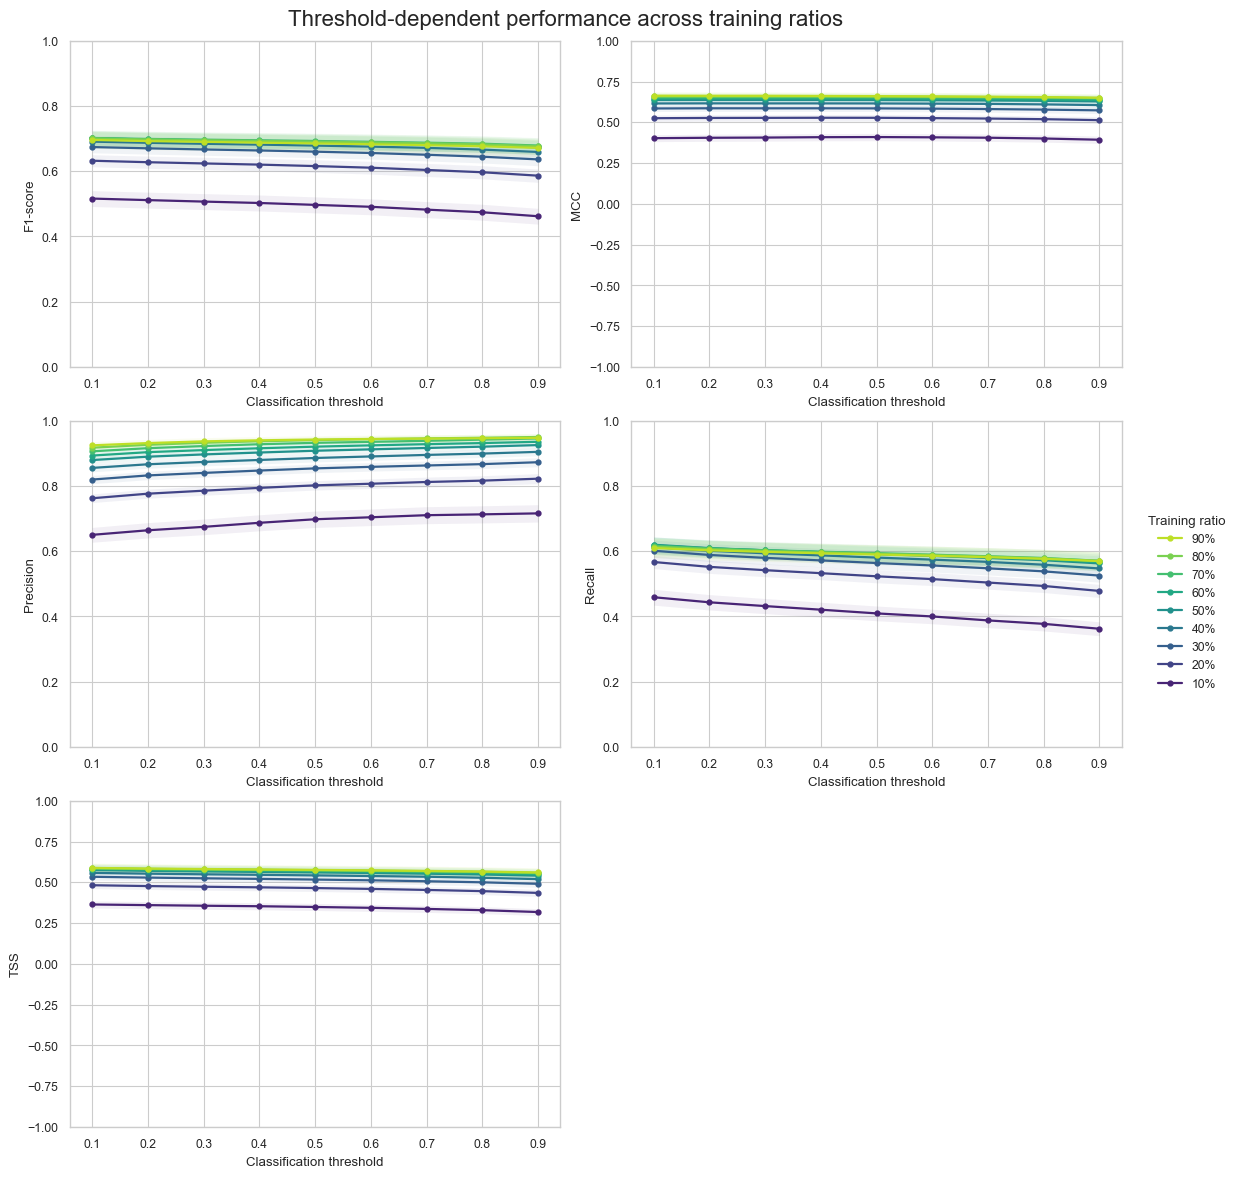

In [ ]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

usecols = [
    "Iteration",
    "Version",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *numeric_cols,
]

# -----------------------------
# Load CSV logs
# -----------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {LOG_DIR}")

frames = []
for csv_file in csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Keep only threshold-sweep rows
df = df[df["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep")].copy()

# Numeric cleanup
for col in ["TrainRatio", "Threshold", *numeric_cols]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Round axis values to avoid floating point label noise
df["TrainRatio"] = df["TrainRatio"].round(0).astype("Int64")
df["Threshold"] = df["Threshold"].round(2)

print("Rows:", len(df))
print("Food webs:", df["FoodWeb"].nunique())
print("Train ratios:", sorted(df["TrainRatio"].dropna().unique().tolist()))
print("Thresholds:", sorted(df["Threshold"].dropna().unique().tolist()))

# -----------------------------
# Aggregate
# -----------------------------
foodweb_level = (
    df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Figure 2: threshold curves by train ratio
# -----------------------------
# Assumes the previous cell already created:
# df, foodweb_level

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_labels = {
    "F1Score": "F1-score",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

# If needed, rebuild foodweb_level from df
missing_foodweb_level = (
    "foodweb_level" not in globals()
    or not set(numeric_cols).issubset(set(foodweb_level.columns))
)

if missing_foodweb_level:
    foodweb_level = (
        df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
        .mean()
        .reset_index()
    )

# Mean and uncertainty across food webs
summary_line = (
    foodweb_level
    .groupby(["TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .agg(["mean", "median", "std", "count"])
)

summary_line.columns = ["_".join(col).strip() for col in summary_line.columns]
summary_line = summary_line.reset_index()

# 95% CI around the food-web mean
for metric_col in numeric_cols:
    summary_line[f"{metric_col}_se"] = (
        summary_line[f"{metric_col}_std"] / np.sqrt(summary_line[f"{metric_col}_count"])
    )
    summary_line[f"{metric_col}_ci95"] = 1.96 * summary_line[f"{metric_col}_se"]

train_ratios = sorted(summary_line["TrainRatio"].dropna().unique())
thresholds = sorted(summary_line["Threshold"].dropna().unique())

palette = sns.color_palette("viridis", n_colors=len(train_ratios))
color_by_ratio = dict(zip(train_ratios, palette))

sns.set_theme(style="whitegrid", context="paper")

n_metrics = len(numeric_cols)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.6 * ncols, 3.8 * nrows),
    sharex=False,
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

for ax, metric_col in zip(axes, numeric_cols):
    metric_label = metric_labels.get(metric_col, metric_col)

    for train_ratio in train_ratios:
        sub = summary_line[summary_line["TrainRatio"] == train_ratio].sort_values("Threshold")

        x = sub["Threshold"].to_numpy(dtype=float)
        y = sub[f"{metric_col}_mean"].to_numpy(dtype=float)
        ci = sub[f"{metric_col}_ci95"].to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.6,
            markersize=3.5,
            color=color_by_ratio[train_ratio],
            label=f"{int(train_ratio)}%",
        )

        ax.fill_between(
            x,
            y - ci,
            y + ci,
            color=color_by_ratio[train_ratio],
            alpha=0.07,
            linewidth=0,
        )

    # ax.set_title(metric_label)
    ax.set_xlabel("Classification threshold")
    ax.set_ylabel(metric_label)
    ax.set_xticks(thresholds)

    if metric_col in ["TestMCC", "TestTSS"]:
        ax.set_ylim(-1.0, 1.0)
    else:
        ax.set_ylim(0.0, 1.0)

for ax in axes[n_metrics:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
handles = handles[::-1]
labels = labels[::-1]
fig.legend(
    handles,
    labels,
    title="Training ratio",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
)

fig.suptitle(
    "Threshold-dependent performance across training ratios",
    fontsize=16,
    y=1.02,
)

plt.show()

CSV files found: 290
Rows: 1174500
Food webs: 290
Train ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Metric,MetricColumn,TrainRatio,BestThreshold,BestValue
0,F1-score,F1Score,10,0.1,0.516263
1,F1-score,F1Score,20,0.1,0.632330
2,F1-score,F1Score,30,0.1,0.674260
3,F1-score,F1Score,40,0.1,0.690889
4,F1-score,F1Score,50,0.1,0.700927
5,F1-score,F1Score,60,0.1,0.701276
6,F1-score,F1Score,70,0.1,0.701981
7,F1-score,F1Score,80,0.1,0.700523
8,F1-score,F1Score,90,0.1,0.696121
9,MCC,TestMCC,10,0.5,0.409838


,Metric,TrainRatio,MedianBestThreshold,Q1BestThreshold,Q3BestThreshold,MeanBestThreshold,NumFoodWebs
0,F1-score,10,0.1,0.1,0.100,0.136897,290
1,F1-score,20,0.1,0.1,0.200,0.178276,290
2,F1-score,30,0.1,0.1,0.175,0.170345,290
3,F1-score,40,0.1,0.1,0.100,0.157241,290
4,F1-score,50,0.1,0.1,0.175,0.160000,290
5,F1-score,60,0.1,0.1,0.200,0.175172,290
6,F1-score,70,0.1,0.1,0.200,0.196552,290
7,F1-score,80,0.1,0.1,0.200,0.202069,290
8,F1-score,90,0.1,0.1,0.300,0.212414,290
9,MCC,10,0.3,0.1,0.500,0.340345,290


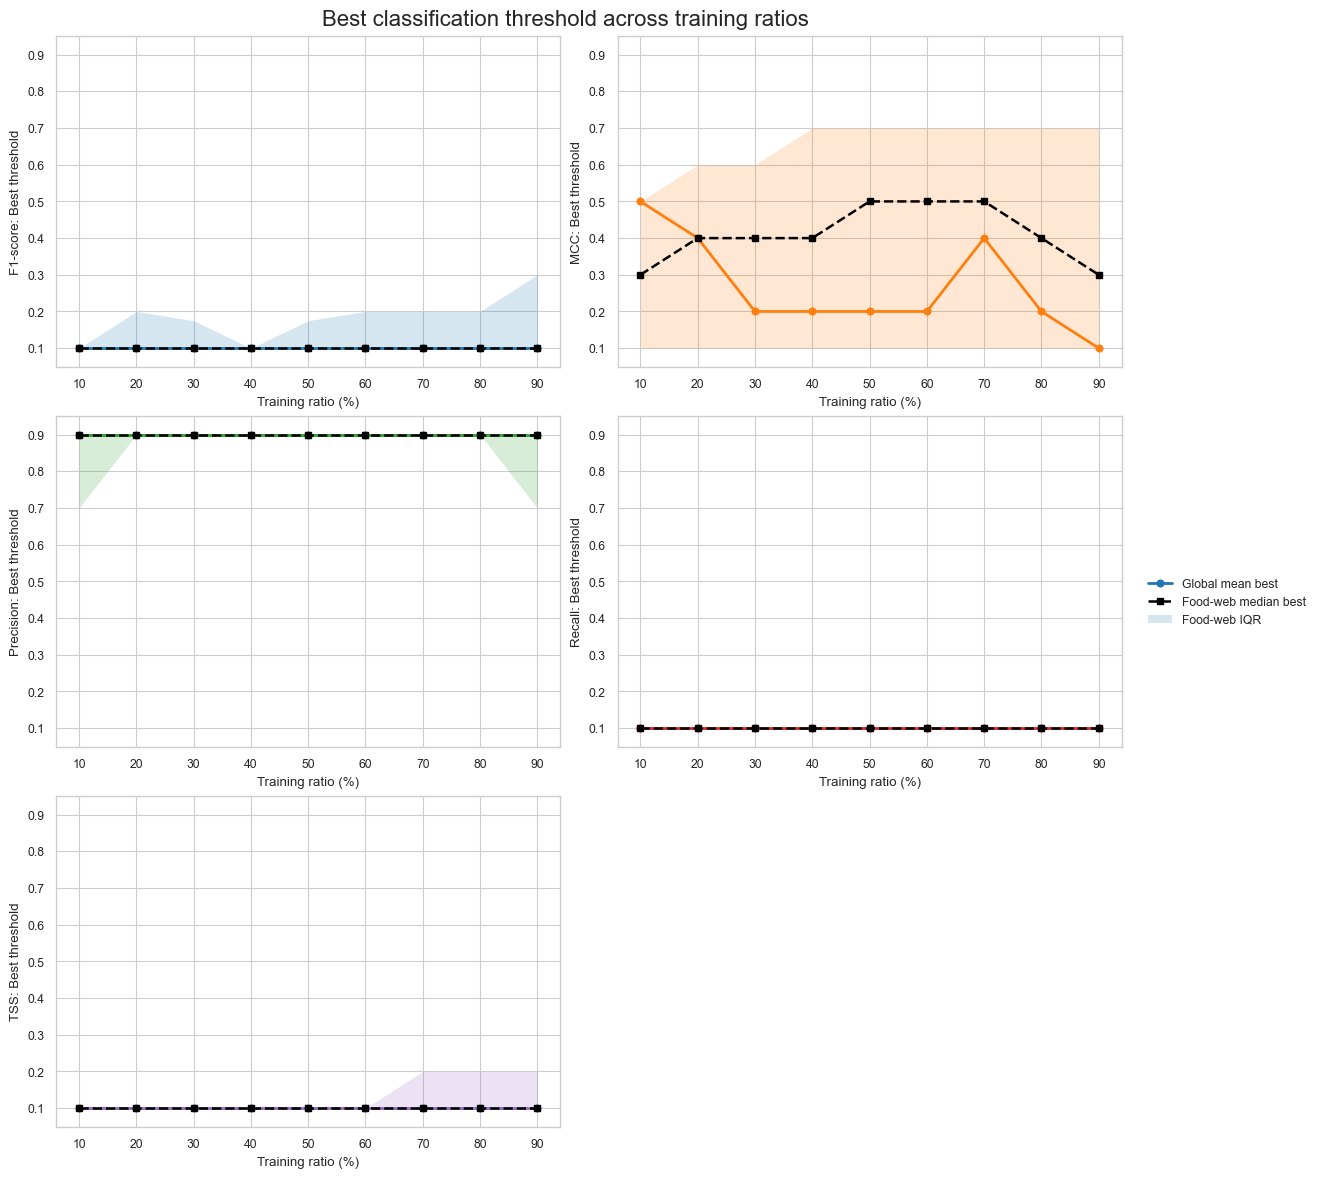

In [ ]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

usecols = [
    "Iteration",
    "Version",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *numeric_cols,
]

# -----------------------------
# Load CSV logs
# -----------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {LOG_DIR}")

frames = []
for csv_file in csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Keep only threshold-sweep rows
df = df[df["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep")].copy()

# Numeric cleanup
for col in ["TrainRatio", "Threshold", *numeric_cols]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Round axis values to avoid floating point label noise
df["TrainRatio"] = df["TrainRatio"].round(0).astype("Int64")
df["Threshold"] = df["Threshold"].round(2)

print("Rows:", len(df))
print("Food webs:", df["FoodWeb"].nunique())
print("Train ratios:", sorted(df["TrainRatio"].dropna().unique().tolist()))
print("Thresholds:", sorted(df["Threshold"].dropna().unique().tolist()))

# -----------------------------
# Aggregate
# -----------------------------
foodweb_level = (
    df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Figure 3: best threshold by train ratio
# -----------------------------
# Assumes the previous cells already created:
# df, foodweb_level

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_labels = {
    "F1Score": "F1-score",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

# If needed, rebuild foodweb_level from df
missing_foodweb_level = (
    "foodweb_level" not in globals()
    or not set(numeric_cols).issubset(set(foodweb_level.columns))
)

if missing_foodweb_level:
    foodweb_level = (
        df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
        .mean()
        .reset_index()
    )

# Global mean per TrainRatio x Threshold, with equal weight per food web.
summary_best = (
    foodweb_level
    .groupby(["TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# Determine the best threshold for each metric and train ratio.
best_rows = []

for metric_col in numeric_cols:
    metric_label = metric_labels.get(metric_col, metric_col)

    for train_ratio, sub in summary_best.groupby("TrainRatio", observed=True):
        sub = sub.dropna(subset=[metric_col]).copy()
        if sub.empty:
            continue

        # If there is a tie, choose the smallest threshold for a conservative decision boundary.
        best_value = sub[metric_col].max()
        best_threshold = sub.loc[sub[metric_col].eq(best_value), "Threshold"].min()

        best_rows.append({
            "Metric": metric_label,
            "MetricColumn": metric_col,
            "TrainRatio": train_ratio,
            "BestThreshold": best_threshold,
            "BestValue": best_value,
        })

best_thresholds = pd.DataFrame(best_rows)

metric_order = [metric_labels[col] for col in numeric_cols]
best_thresholds["Metric"] = pd.Categorical(
    best_thresholds["Metric"],
    categories=metric_order,
    ordered=True,
)

display(best_thresholds.sort_values(["Metric", "TrainRatio"]).head(10))

# -----------------------------
# Food-web-level stability
# -----------------------------
foodweb_best_rows = []

for metric_col in numeric_cols:
    metric_label = metric_labels.get(metric_col, metric_col)

    for (foodweb, train_ratio), sub in foodweb_level.groupby(["FoodWeb", "TrainRatio"], observed=True):
        sub = sub.dropna(subset=[metric_col]).copy()
        if sub.empty:
            continue

        best_value = sub[metric_col].max()
        best_threshold = sub.loc[sub[metric_col].eq(best_value), "Threshold"].min()

        foodweb_best_rows.append({
            "FoodWeb": foodweb,
            "Metric": metric_label,
            "MetricColumn": metric_col,
            "TrainRatio": train_ratio,
            "BestThreshold": best_threshold,
            "BestValue": best_value,
        })

foodweb_best = pd.DataFrame(foodweb_best_rows)

foodweb_best["Metric"] = pd.Categorical(
    foodweb_best["Metric"],
    categories=metric_order,
    ordered=True,
)

best_threshold_summary = (
    foodweb_best
    .groupby(["Metric", "TrainRatio"], observed=True)
    .agg(
        MedianBestThreshold=("BestThreshold", "median"),
        Q1BestThreshold=("BestThreshold", lambda x: x.quantile(0.25)),
        Q3BestThreshold=("BestThreshold", lambda x: x.quantile(0.75)),
        MeanBestThreshold=("BestThreshold", "mean"),
        NumFoodWebs=("FoodWeb", "nunique"),
    )
    .reset_index()
)

display(best_threshold_summary.sort_values(["Metric", "TrainRatio"]).head(10))

# -----------------------------
# Plot: 2 metrics per row
# -----------------------------
sns.set_theme(style="whitegrid", context="paper")

n_metrics = len(numeric_cols)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.6 * ncols, 3.8 * nrows),
    sharex=False,
    sharey=False,
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

metric_palette = dict(zip(metric_order, sns.color_palette("tab10", n_colors=n_metrics)))

for ax, metric_col in zip(axes, numeric_cols):
    metric_label = metric_labels.get(metric_col, metric_col)

    global_sub = (
        best_thresholds[best_thresholds["Metric"] == metric_label]
        .sort_values("TrainRatio")
    )

    fw_sub = (
        best_threshold_summary[best_threshold_summary["Metric"] == metric_label]
        .sort_values("TrainRatio")
    )

    # Global best threshold from the mean metric.
    ax.plot(
        global_sub["TrainRatio"].to_numpy(dtype=float),
        global_sub["BestThreshold"].to_numpy(dtype=float),
        marker="o",
        linewidth=2,
        color=metric_palette[metric_label],
        label="Global mean best",
    )

    # Food-web-level median best threshold and IQR.
    x = fw_sub["TrainRatio"].to_numpy(dtype=float)
    y = fw_sub["MedianBestThreshold"].to_numpy(dtype=float)
    q1 = fw_sub["Q1BestThreshold"].to_numpy(dtype=float)
    q3 = fw_sub["Q3BestThreshold"].to_numpy(dtype=float)

    ax.plot(
        x,
        y,
        marker="s",
        linewidth=1.8,
        linestyle="--",
        color="black",
        label="Food-web median best",
    )

    ax.fill_between(
        x,
        q1,
        q3,
        alpha=0.18,
        color=metric_palette[metric_label],
        linewidth=0,
        label="Food-web IQR",
    )

    # ax.set_title(metric_label)
    ax.set_xlabel("Training ratio (%)")
    ax.set_ylabel(f"{metric_label}: Best threshold")
    ax.set_xticks(sorted(summary_best["TrainRatio"].dropna().unique()))
    ax.set_yticks(sorted(summary_best["Threshold"].dropna().unique()))
    ax.set_ylim(0.05, 0.95)

for ax in axes[n_metrics:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
)

fig.suptitle(
    "Best classification threshold across training ratios",
    fontsize=16,
    y=1.02,
)

plt.show()

CSV files found: 290
Rows: 1174500
Food webs: 290
Train ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


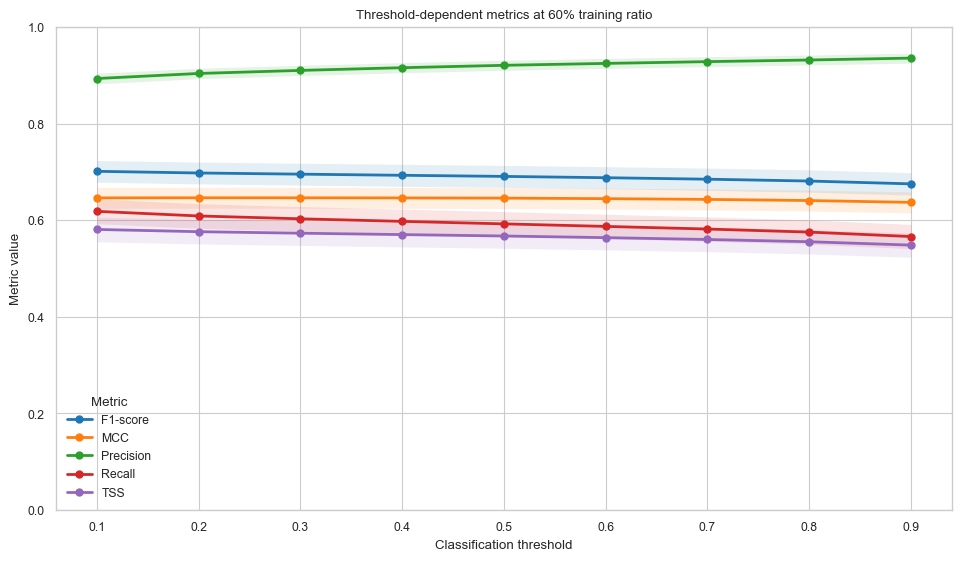

In [ ]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

usecols = [
    "Iteration",
    "Version",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *numeric_cols,
]

# -----------------------------
# Load CSV logs
# -----------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {LOG_DIR}")

frames = []
for csv_file in csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Keep only threshold-sweep rows
df = df[df["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep")].copy()

# Numeric cleanup
for col in ["TrainRatio", "Threshold", *numeric_cols]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Round axis values to avoid floating point label noise
df["TrainRatio"] = df["TrainRatio"].round(0).astype("Int64")
df["Threshold"] = df["Threshold"].round(2)

print("Rows:", len(df))
print("Food webs:", df["FoodWeb"].nunique())
print("Train ratios:", sorted(df["TrainRatio"].dropna().unique().tolist()))
print("Thresholds:", sorted(df["Threshold"].dropna().unique().tolist()))

# -----------------------------
# Aggregate
# -----------------------------
foodweb_level = (
    df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Figure 1: metric curves vs threshold at TrainRatio = 60%
# -----------------------------

target_train_ratio = 60

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_labels = {
    "F1Score": "F1-score",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

# Rebuild foodweb_level if needed
missing_foodweb_level = (
    "foodweb_level" not in globals()
    or not set(numeric_cols).issubset(set(foodweb_level.columns))
)

if missing_foodweb_level:
    foodweb_level = (
        df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
        .mean()
        .reset_index()
    )

# Keep only target train ratio
fw_60 = foodweb_level[foodweb_level["TrainRatio"] == target_train_ratio].copy()

if fw_60.empty:
    raise ValueError(f"No data found for TrainRatio = {target_train_ratio}")

# Summarise across food webs
summary_60 = (
    fw_60
    .groupby("Threshold", observed=True)[numeric_cols]
    .agg(["mean", "median", "std", "count"])
)

summary_60.columns = ["_".join(col).strip() for col in summary_60.columns]
summary_60 = summary_60.reset_index()

# 95% CI around food-web mean
for metric_col in numeric_cols:
    summary_60[f"{metric_col}_se"] = (
        summary_60[f"{metric_col}_std"] / np.sqrt(summary_60[f"{metric_col}_count"])
    )
    summary_60[f"{metric_col}_ci95"] = 1.96 * summary_60[f"{metric_col}_se"]

thresholds = sorted(summary_60["Threshold"].dropna().unique())

# Long format for clean plotting
plot_rows = []
for metric_col in numeric_cols:
    metric_label = metric_labels.get(metric_col, metric_col)

    for _, row in summary_60.iterrows():
        plot_rows.append({
            "Threshold": row["Threshold"],
            "Metric": metric_label,
            "Mean": row[f"{metric_col}_mean"],
            "CI95": row[f"{metric_col}_ci95"],
        })

plot_df = pd.DataFrame(plot_rows)

# -----------------------------
# Plot
# -----------------------------
sns.set_theme(style="whitegrid", context="paper")

palette = dict(zip(
    [metric_labels[col] for col in numeric_cols],
    sns.color_palette("tab10", n_colors=len(numeric_cols))
))

fig, ax = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)

for metric_col in numeric_cols:
    metric_label = metric_labels.get(metric_col, metric_col)
    sub = plot_df[plot_df["Metric"] == metric_label].sort_values("Threshold")

    x = sub["Threshold"].to_numpy(dtype=float)
    y = sub["Mean"].to_numpy(dtype=float)
    ci = sub["CI95"].to_numpy(dtype=float)

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        markersize=5,
        color=palette[metric_label],
        label=metric_label,
    )

    ax.fill_between(
        x,
        y - ci,
        y + ci,
        color=palette[metric_label],
        alpha=0.12,
        linewidth=0,
    )

ax.set_title(f"Threshold-dependent metrics at {target_train_ratio}% training ratio")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Metric value")
ax.set_xticks(thresholds)
ax.set_ylim(0, 1)
ax.legend(title="Metric", frameon=False, loc="best")

plt.show()

CSV files found: 290
Rows: 1174500
Food webs: 290
Train ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Food webs by ecosystem at target train ratio:


EcosystemType
Lakes                       55
Streams                     28
Marine                     134
Terrestrial aboveground     21
Terrestrial belowground     52
Name: FoodWeb, dtype: int64

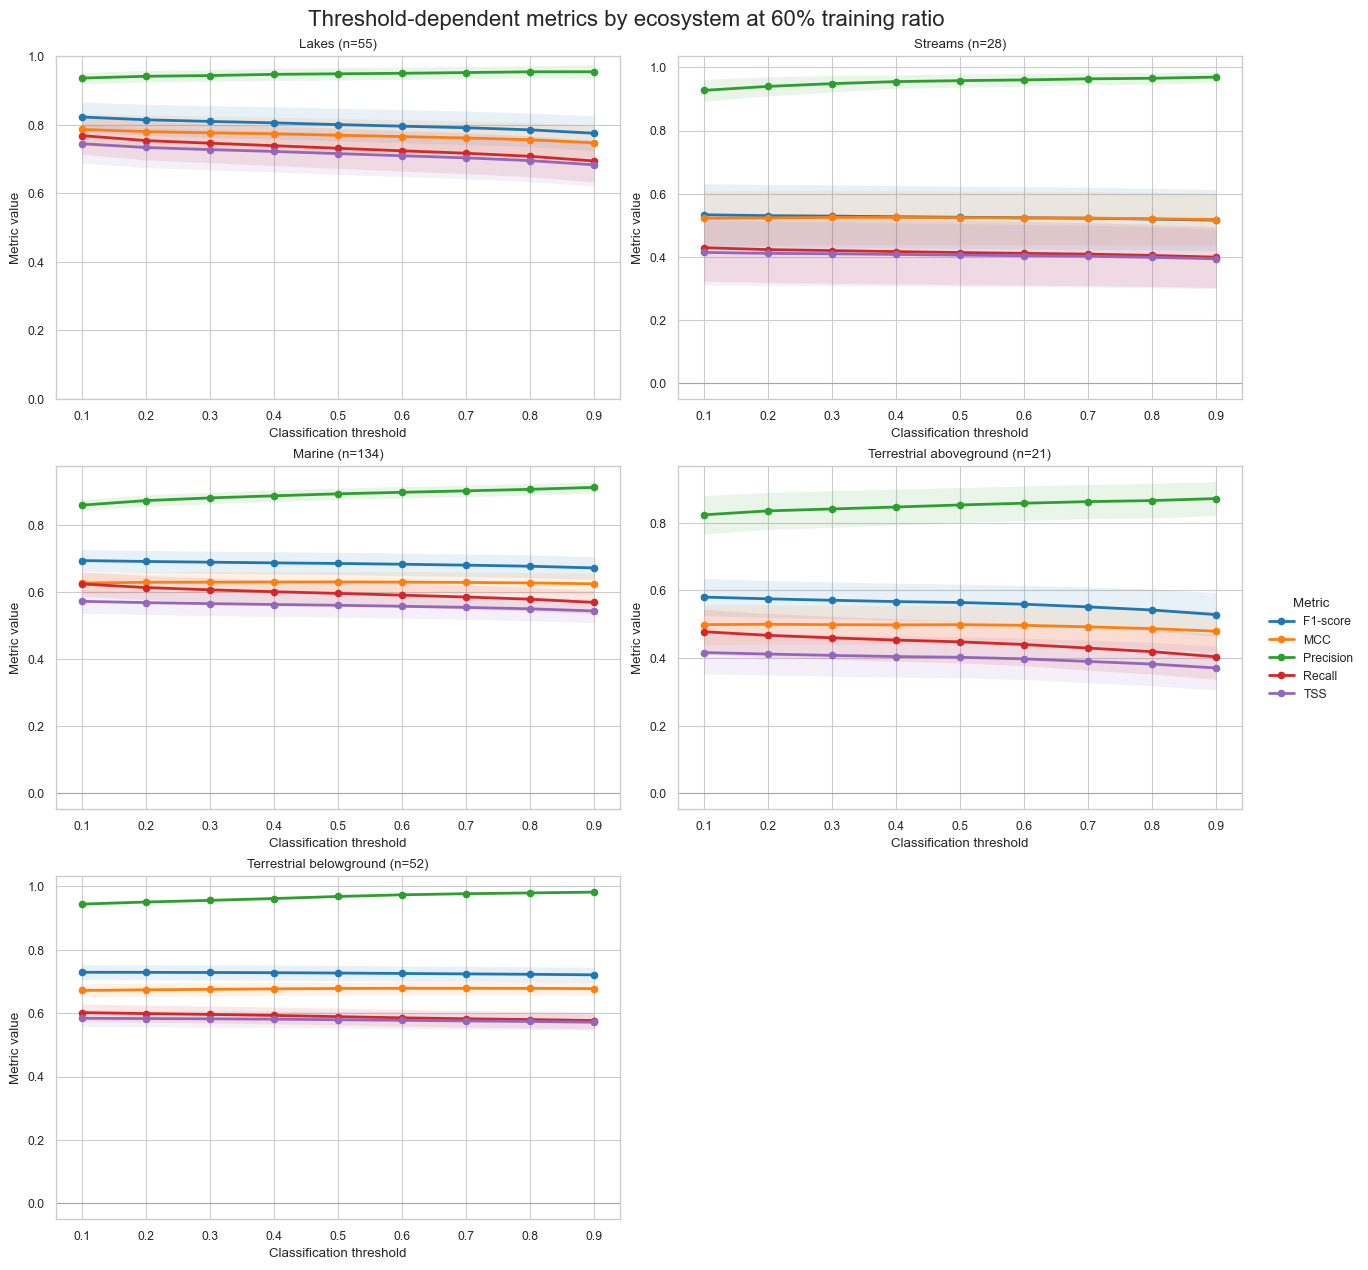

In [ ]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

usecols = [
    "Iteration",
    "Version",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *numeric_cols,
]

# -----------------------------
# Load CSV logs
# -----------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {LOG_DIR}")

frames = []
for csv_file in csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Keep only threshold-sweep rows
df = df[df["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep")].copy()

# Numeric cleanup
for col in ["TrainRatio", "Threshold", *numeric_cols]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Round axis values to avoid floating point label noise
df["TrainRatio"] = df["TrainRatio"].round(0).astype("Int64")
df["Threshold"] = df["Threshold"].round(2)

print("Rows:", len(df))
print("Food webs:", df["FoodWeb"].nunique())
print("Train ratios:", sorted(df["TrainRatio"].dropna().unique().tolist()))
print("Thresholds:", sorted(df["Threshold"].dropna().unique().tolist()))

# -----------------------------
# Aggregate
# -----------------------------
foodweb_level = (
    df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Figure 1 by ecosystem:
# metric curves vs threshold at TrainRatio = 60%
# -----------------------------
# Assumes previous cells already created:
# df, foodweb_level

target_train_ratio = 60

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_labels = {
    "F1Score": "F1-score",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

# -----------------------------
# Load ecosystem metadata
# -----------------------------
metadata_file = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)

ecosystem_meta = pd.read_csv(metadata_file, usecols=["Foodweb", "EcosystemType"])
ecosystem_meta = ecosystem_meta.rename(columns={"Foodweb": "FoodWeb"})

ecosystem_meta["EcosystemType"] = (
    ecosystem_meta["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# -----------------------------
# Rebuild foodweb_level if needed
# -----------------------------
missing_foodweb_level = (
    "foodweb_level" not in globals()
    or not set(numeric_cols).issubset(set(foodweb_level.columns))
)

if missing_foodweb_level:
    foodweb_level = (
        df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
        .mean()
        .reset_index()
    )

# Add ecosystem type
foodweb_level_ecosystem = foodweb_level.merge(
    ecosystem_meta,
    on="FoodWeb",
    how="left",
)

missing_ecosystem = foodweb_level_ecosystem["EcosystemType"].isna().sum()
if missing_ecosystem:
    print(f"Warning: {missing_ecosystem} rows have missing EcosystemType after merge.")

# Keep only target train ratio and the five expected ecosystems
fw_60_eco = foodweb_level_ecosystem[
    (foodweb_level_ecosystem["TrainRatio"] == target_train_ratio)
    & (foodweb_level_ecosystem["EcosystemType"].isin(ecosystem_order))
].copy()

if fw_60_eco.empty:
    raise ValueError(f"No data found for TrainRatio = {target_train_ratio}")

print("Food webs by ecosystem at target train ratio:")
display(
    fw_60_eco.groupby("EcosystemType", observed=True)["FoodWeb"]
    .nunique()
    .reindex(ecosystem_order)
    .rename(index=ecosystem_labels)
)

# -----------------------------
# Summarise across food webs within each ecosystem
# -----------------------------
summary_60_eco = (
    fw_60_eco
    .groupby(["EcosystemType", "Threshold"], observed=True)[numeric_cols]
    .agg(["mean", "median", "std", "count"])
)

summary_60_eco.columns = ["_".join(col).strip() for col in summary_60_eco.columns]
summary_60_eco = summary_60_eco.reset_index()

# 95% CI around food-web mean within ecosystem
for metric_col in numeric_cols:
    summary_60_eco[f"{metric_col}_se"] = (
        summary_60_eco[f"{metric_col}_std"]
        / np.sqrt(summary_60_eco[f"{metric_col}_count"])
    )
    summary_60_eco[f"{metric_col}_ci95"] = 1.96 * summary_60_eco[f"{metric_col}_se"]

thresholds = sorted(summary_60_eco["Threshold"].dropna().unique())

# Long format for plotting
plot_rows = []

for ecosystem in ecosystem_order:
    eco_sub = summary_60_eco[summary_60_eco["EcosystemType"] == ecosystem]

    for metric_col in numeric_cols:
        metric_label = metric_labels.get(metric_col, metric_col)

        for _, row in eco_sub.iterrows():
            plot_rows.append({
                "EcosystemType": ecosystem,
                "EcosystemLabel": ecosystem_labels.get(ecosystem, ecosystem),
                "Threshold": row["Threshold"],
                "Metric": metric_label,
                "Mean": row[f"{metric_col}_mean"],
                "CI95": row[f"{metric_col}_ci95"],
                "NFoodWebs": row[f"{metric_col}_count"],
            })

plot_df = pd.DataFrame(plot_rows)

# -----------------------------
# Plot: one panel per ecosystem
# -----------------------------
sns.set_theme(style="whitegrid", context="paper")

metric_order = [metric_labels[col] for col in numeric_cols]
palette = dict(zip(metric_order, sns.color_palette("tab10", n_colors=len(metric_order))))

n_ecosystems = len(ecosystem_order)
ncols = 2
nrows = math.ceil(n_ecosystems / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6.2 * ncols, 4.1 * nrows),
    sharex=False,
    sharey=False,
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

for ax, ecosystem in zip(axes, ecosystem_order):
    eco_label = ecosystem_labels.get(ecosystem, ecosystem)
    eco_plot = plot_df[plot_df["EcosystemType"] == ecosystem].copy()

    for metric_label in metric_order:
        sub = eco_plot[eco_plot["Metric"] == metric_label].sort_values("Threshold")

        x = sub["Threshold"].to_numpy(dtype=float)
        y = sub["Mean"].to_numpy(dtype=float)
        ci = sub["CI95"].to_numpy(dtype=float)

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            markersize=4.5,
            color=palette[metric_label],
            label=metric_label,
        )

        ax.fill_between(
            x,
            y - ci,
            y + ci,
            color=palette[metric_label],
            alpha=0.10,
            linewidth=0,
        )

    n_foodwebs = fw_60_eco.loc[
        fw_60_eco["EcosystemType"] == ecosystem,
        "FoodWeb",
    ].nunique()

    ax.set_title(f"{eco_label} (n={n_foodwebs})")
    ax.set_xlabel("Classification threshold")
    ax.set_ylabel("Metric value")
    ax.set_xticks(thresholds)
    ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)

for ax in axes[n_ecosystems:]:
    ax.axis("off")

# Keep the same y scale across ecosystem panels.
y_min = np.nanmin(plot_df["Mean"] - plot_df["CI95"])
if y_min < 0:
    axes[0].set_ylim(max(-1, y_min - 0.05), 1.0)
else:
    axes[0].set_ylim(0.0, 1.0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Metric",
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
)

fig.suptitle(
    f"Threshold-dependent metrics by ecosystem at {target_train_ratio}% training ratio",
    fontsize=16,
    y=1.02,
)

plt.show()

CSV files found: 290
Rows: 1174500
Food webs: 290
Train ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


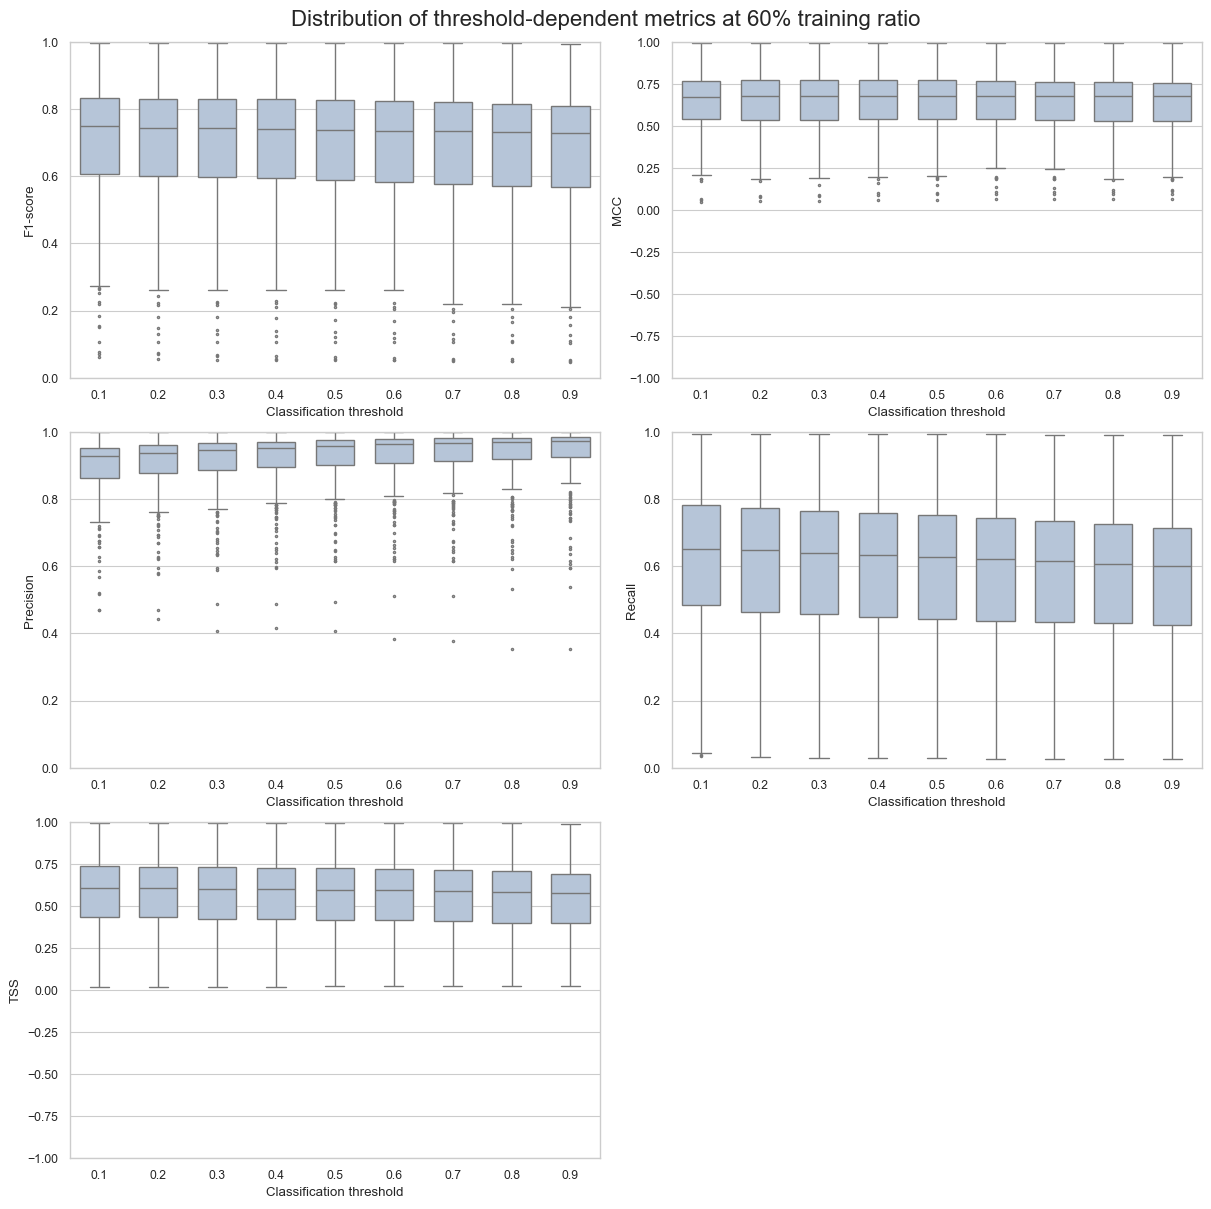

In [ ]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

usecols = [
    "Iteration",
    "Version",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *numeric_cols,
]

# -----------------------------
# Load CSV logs
# -----------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {LOG_DIR}")

frames = []
for csv_file in csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Keep only threshold-sweep rows
df = df[df["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep")].copy()

# Numeric cleanup
for col in ["TrainRatio", "Threshold", *numeric_cols]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Round axis values to avoid floating point label noise
df["TrainRatio"] = df["TrainRatio"].round(0).astype("Int64")
df["Threshold"] = df["Threshold"].round(2)

print("Rows:", len(df))
print("Food webs:", df["FoodWeb"].nunique())
print("Train ratios:", sorted(df["TrainRatio"].dropna().unique().tolist()))
print("Thresholds:", sorted(df["Threshold"].dropna().unique().tolist()))

# -----------------------------
# Aggregate
# -----------------------------
foodweb_level = (
    df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Figure 2: boxplots by threshold at TrainRatio = 60%
# -----------------------------

target_train_ratio = 60

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_labels = {
    "F1Score": "F1-score",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

# Rebuild foodweb_level if needed
missing_foodweb_level = (
    "foodweb_level" not in globals()
    or not set(numeric_cols).issubset(set(foodweb_level.columns))
)

if missing_foodweb_level:
    foodweb_level = (
        df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
        .mean()
        .reset_index()
    )

# Keep only target train ratio
fw_60 = foodweb_level[foodweb_level["TrainRatio"] == target_train_ratio].copy()

if fw_60.empty:
    raise ValueError(f"No data found for TrainRatio = {target_train_ratio}")

# Long format
plot_df = fw_60.melt(
    id_vars=["FoodWeb", "TrainRatio", "Threshold"],
    value_vars=numeric_cols,
    var_name="MetricColumn",
    value_name="MetricValue",
)

plot_df["Metric"] = plot_df["MetricColumn"].map(metric_labels)
plot_df["ThresholdLabel"] = plot_df["Threshold"].map(lambda x: f"{x:.1f}")

metric_order = [metric_labels[col] for col in numeric_cols]
threshold_order = [f"{x:.1f}" for x in sorted(fw_60["Threshold"].dropna().unique())]

plot_df["Metric"] = pd.Categorical(
    plot_df["Metric"],
    categories=metric_order,
    ordered=True,
)

plot_df["ThresholdLabel"] = pd.Categorical(
    plot_df["ThresholdLabel"],
    categories=threshold_order,
    ordered=True,
)

# -----------------------------
# Plot: 2 metrics per row
# -----------------------------
sns.set_theme(style="whitegrid", context="paper")

n_metrics = len(numeric_cols)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6.0 * ncols, 3.9 * nrows),
    sharex=False,
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

for ax, metric_col in zip(axes, numeric_cols):
    metric_label = metric_labels[metric_col]

    sub = plot_df[plot_df["Metric"] == metric_label].copy()

    sns.boxplot(
        data=sub,
        x="ThresholdLabel",
        y="MetricValue",
        order=threshold_order,
        ax=ax,
        color="lightsteelblue",
        width=0.65,
        fliersize=1.5,
        linewidth=1,
    )

    # sns.pointplot(
    #     data=sub,
    #     x="ThresholdLabel",
    #     y="MetricValue",
    #     order=threshold_order,
    #     ax=ax,
    #     color="black",
    #     estimator="mean",
    #     errorbar=None,
    #     markers="D",
    #     linestyles="-",
    #     markersize=3.5,
    #     linewidth=1.2,
    # )

    # ax.set_title(metric_label)
    ax.set_xlabel("Classification threshold")
    ax.set_ylabel(metric_label)

    if metric_col in ["TestMCC", "TestTSS"]:
        ax.set_ylim(-1.0, 1.0)
    else:
        ax.set_ylim(0.0, 1.0)

for ax in axes[n_metrics:]:
    ax.axis("off")

fig.suptitle(
    f"Distribution of threshold-dependent metrics at {target_train_ratio}% training ratio",
    fontsize=16,
    y=1.02,
)

plt.show()

CSV files found: 290
Rows: 1174500
Food webs: 290
Train ratios: [10, 20, 30, 40, 50, 60, 70, 80, 90]
Thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Food webs by ecosystem at target train ratio:


EcosystemType
Lakes                       55
Streams                     28
Marine                     134
Terrestrial aboveground     21
Terrestrial belowground     52
Name: FoodWeb, dtype: int64

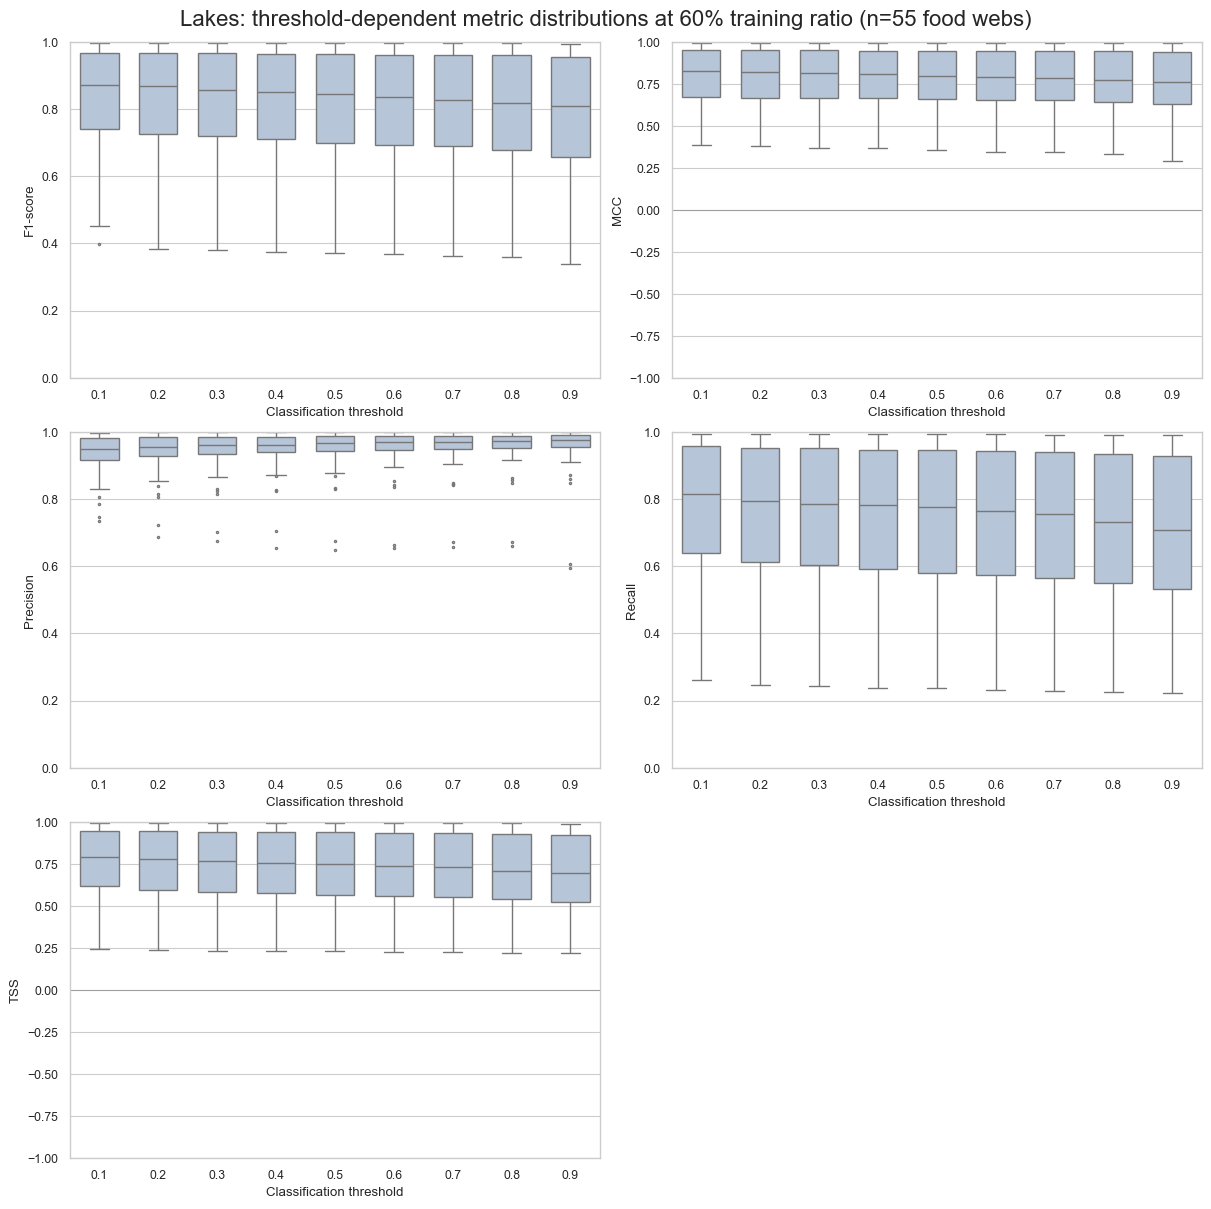

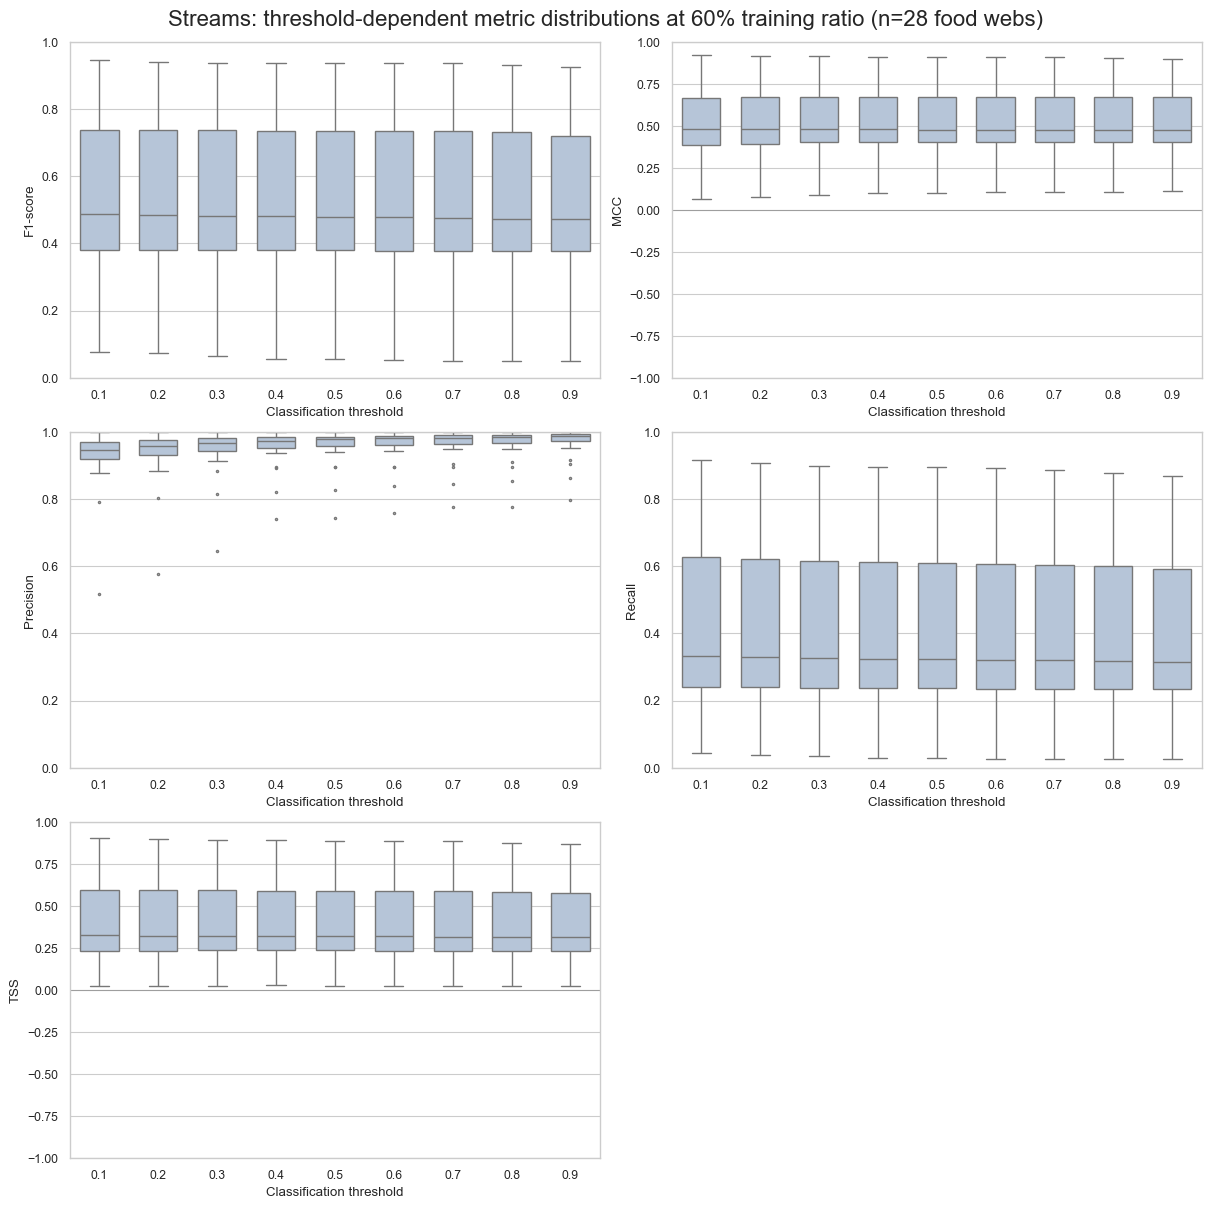

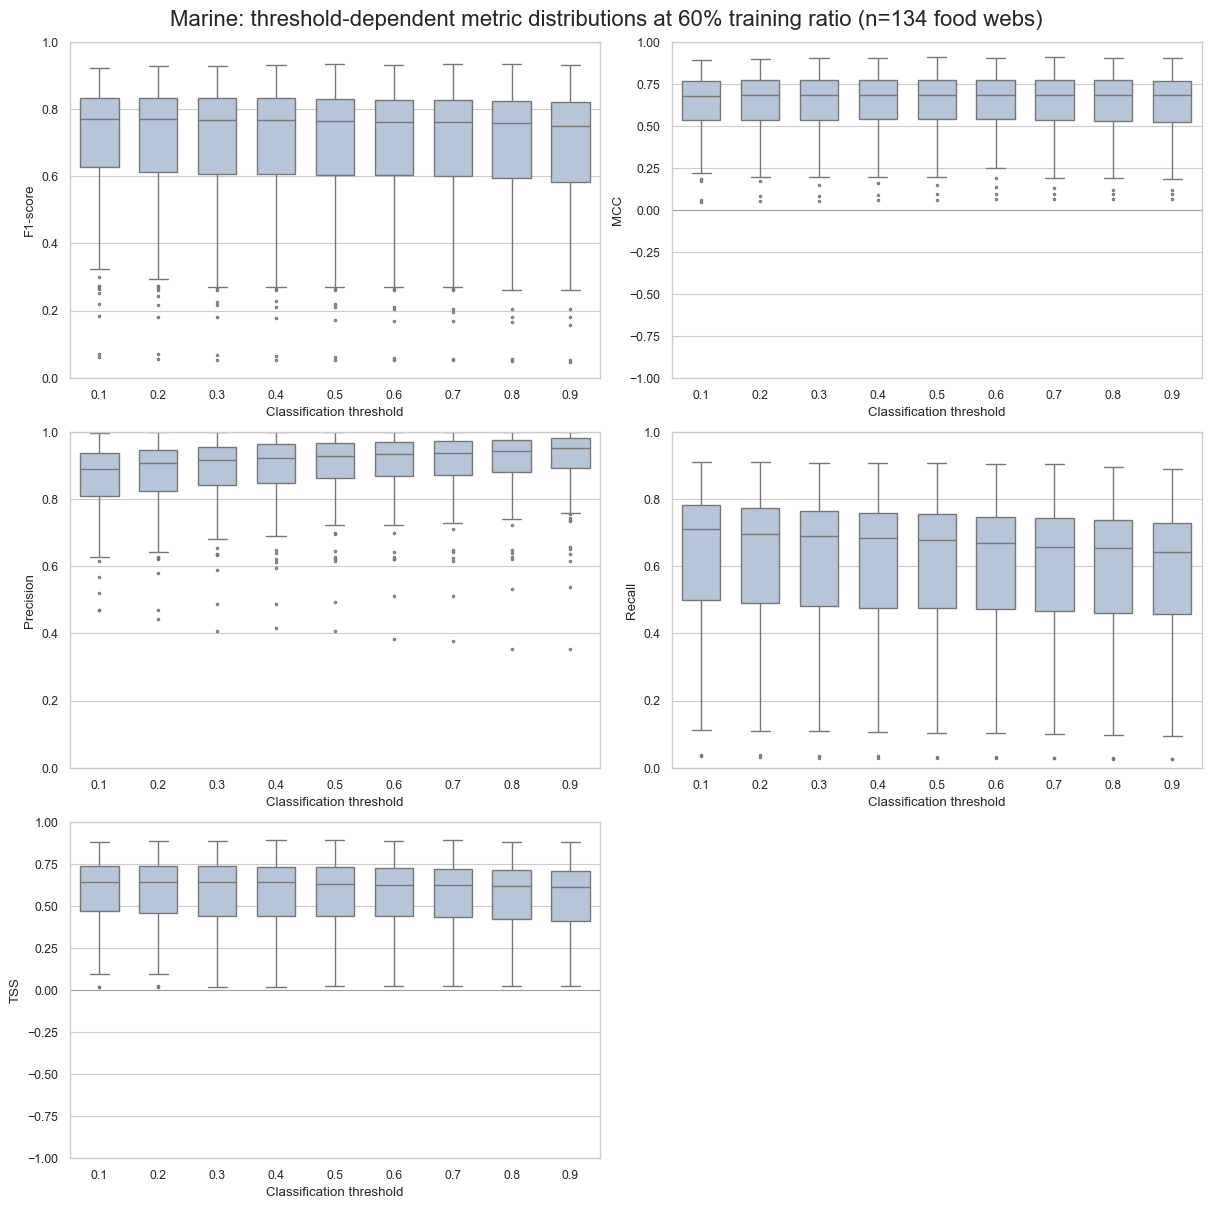

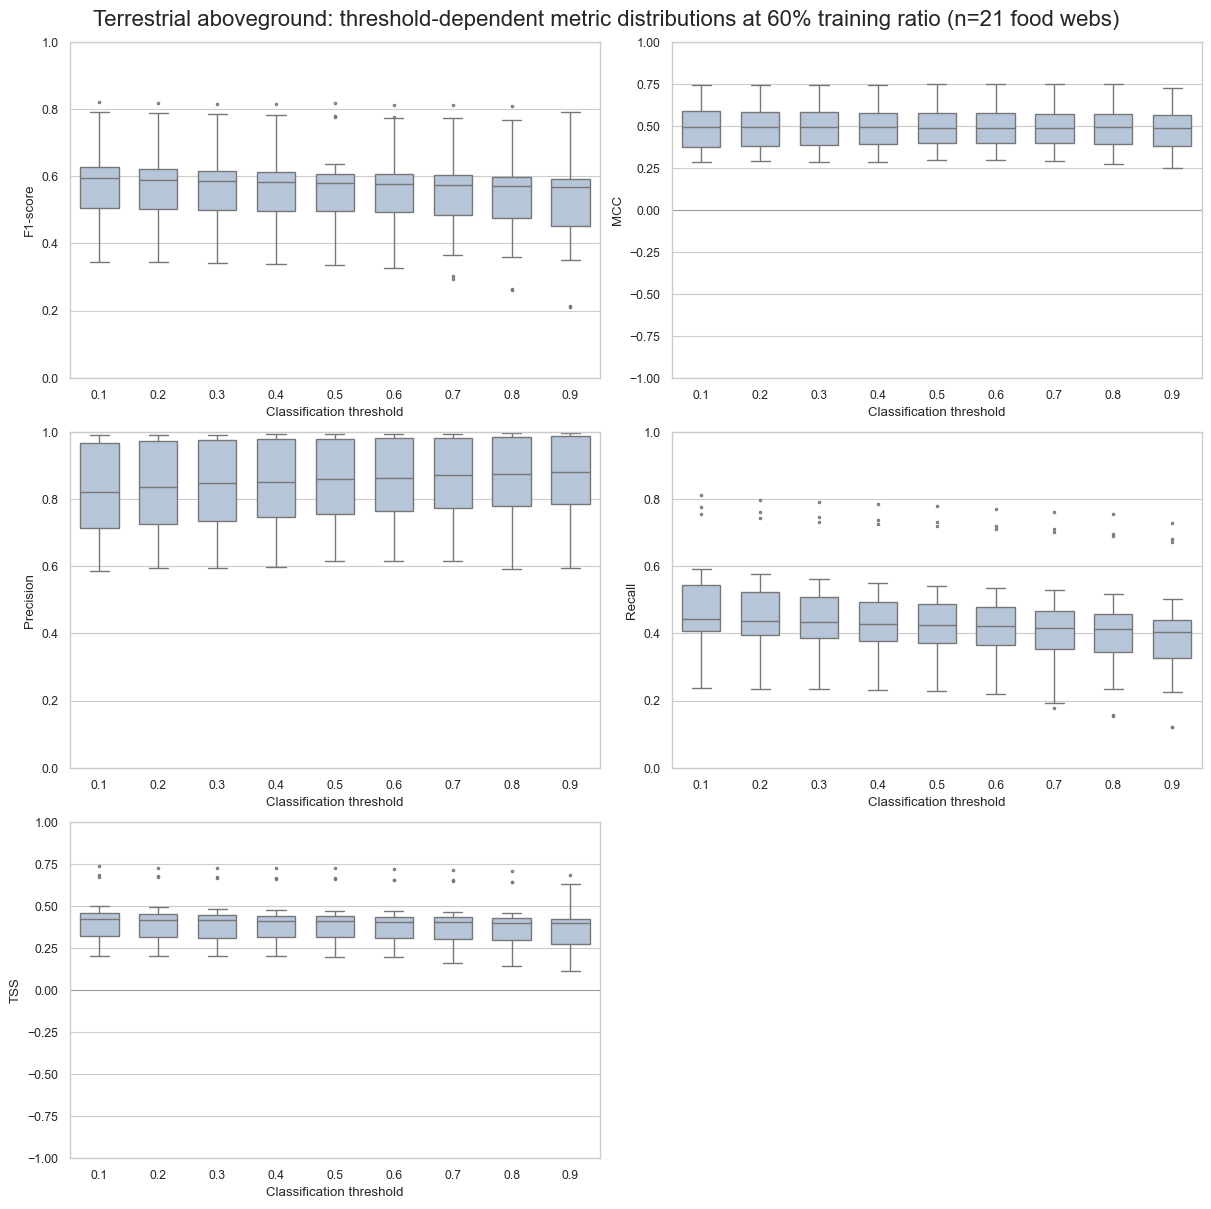

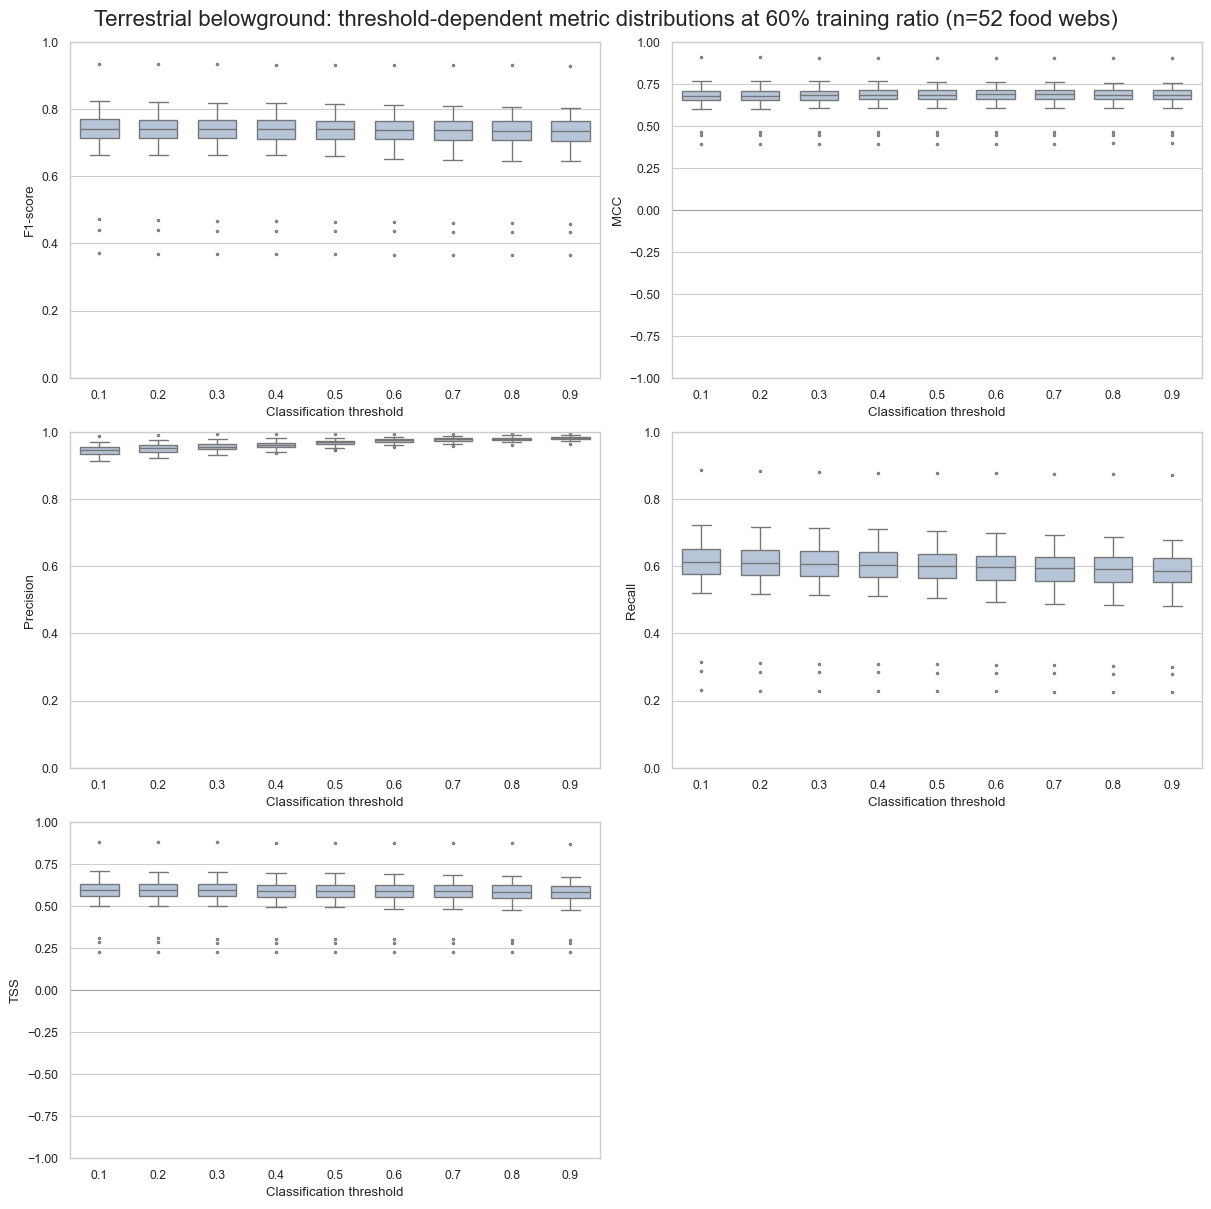

In [47]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

usecols = [
    "Iteration",
    "Version",
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *numeric_cols,
]

# -----------------------------
# Load CSV logs
# -----------------------------
csv_files = sorted(LOG_DIR.glob("*.csv"))
print(f"CSV files found: {len(csv_files)}")

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {LOG_DIR}")

frames = []
for csv_file in csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)

# Keep only threshold-sweep rows
df = df[df["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep")].copy()

# Numeric cleanup
for col in ["TrainRatio", "Threshold", *numeric_cols]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Round axis values to avoid floating point label noise
df["TrainRatio"] = df["TrainRatio"].round(0).astype("Int64")
df["Threshold"] = df["Threshold"].round(2)

print("Rows:", len(df))
print("Food webs:", df["FoodWeb"].nunique())
print("Train ratios:", sorted(df["TrainRatio"].dropna().unique().tolist()))
print("Thresholds:", sorted(df["Threshold"].dropna().unique().tolist()))

# -----------------------------
# Aggregate
# -----------------------------
foodweb_level = (
    df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
    .mean()
    .reset_index()
)

# -----------------------------
# Figure 2 by ecosystem:
# boxplots by threshold at TrainRatio = 60%
# -----------------------------
# Assumes previous cells already created:
# df, foodweb_level, REPO_ROOT

target_train_ratio = 60

numeric_cols = [
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

metric_labels = {
    "F1Score": "F1-score",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial aboveground",
    "terrestrial belowground": "Terrestrial belowground",
}

# -----------------------------
# Load ecosystem metadata
# -----------------------------
metadata_file = (
    REPO_ROOT
    / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)

ecosystem_meta = pd.read_csv(metadata_file, usecols=["Foodweb", "EcosystemType"])
ecosystem_meta = ecosystem_meta.rename(columns={"Foodweb": "FoodWeb"})

ecosystem_meta["EcosystemType"] = (
    ecosystem_meta["EcosystemType"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# -----------------------------
# Rebuild foodweb_level if needed
# -----------------------------
missing_foodweb_level = (
    "foodweb_level" not in globals()
    or not set(numeric_cols).issubset(set(foodweb_level.columns))
)

if missing_foodweb_level:
    foodweb_level = (
        df.groupby(["FoodWeb", "TrainRatio", "Threshold"], observed=True)[numeric_cols]
        .mean()
        .reset_index()
    )

# Add ecosystem type
foodweb_level_ecosystem = foodweb_level.merge(
    ecosystem_meta,
    on="FoodWeb",
    how="left",
)

missing_ecosystem = foodweb_level_ecosystem["EcosystemType"].isna().sum()
if missing_ecosystem:
    print(f"Warning: {missing_ecosystem} rows have missing EcosystemType after merge.")

# Keep only target train ratio and expected ecosystems
fw_60_eco = foodweb_level_ecosystem[
    (foodweb_level_ecosystem["TrainRatio"] == target_train_ratio)
    & (foodweb_level_ecosystem["EcosystemType"].isin(ecosystem_order))
].copy()

if fw_60_eco.empty:
    raise ValueError(f"No data found for TrainRatio = {target_train_ratio}")

print("Food webs by ecosystem at target train ratio:")
display(
    fw_60_eco.groupby("EcosystemType", observed=True)["FoodWeb"]
    .nunique()
    .reindex(ecosystem_order)
    .rename(index=ecosystem_labels)
)

# -----------------------------
# Long format
# -----------------------------
plot_df = fw_60_eco.melt(
    id_vars=["FoodWeb", "TrainRatio", "Threshold", "EcosystemType"],
    value_vars=numeric_cols,
    var_name="MetricColumn",
    value_name="MetricValue",
)

plot_df["Metric"] = plot_df["MetricColumn"].map(metric_labels)
plot_df["ThresholdLabel"] = plot_df["Threshold"].map(lambda x: f"{x:.1f}")

metric_order = [metric_labels[col] for col in numeric_cols]
threshold_order = [f"{x:.1f}" for x in sorted(fw_60_eco["Threshold"].dropna().unique())]

plot_df["Metric"] = pd.Categorical(
    plot_df["Metric"],
    categories=metric_order,
    ordered=True,
)

plot_df["ThresholdLabel"] = pd.Categorical(
    plot_df["ThresholdLabel"],
    categories=threshold_order,
    ordered=True,
)

# -----------------------------
# Plot: one figure per ecosystem, 2 metrics per row
# -----------------------------
sns.set_theme(style="whitegrid", context="paper")

n_metrics = len(numeric_cols)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

for ecosystem in ecosystem_order:
    ecosystem_label = ecosystem_labels[ecosystem]
    eco_df = plot_df[plot_df["EcosystemType"] == ecosystem].copy()

    if eco_df.empty:
        print(f"Skipping {ecosystem_label}: no data.")
        continue

    n_foodwebs = eco_df["FoodWeb"].nunique()

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6.0 * ncols, 3.9 * nrows),
        sharex=False,
        constrained_layout=True,
    )

    axes = np.array(axes).reshape(-1)

    for ax, metric_col in zip(axes, numeric_cols):
        metric_label = metric_labels[metric_col]
        sub = eco_df[eco_df["Metric"] == metric_label].copy()

        sns.boxplot(
            data=sub,
            x="ThresholdLabel",
            y="MetricValue",
            order=threshold_order,
            ax=ax,
            color="lightsteelblue",
            width=0.65,
            fliersize=1.5,
            linewidth=1,
        )

        # ax.set_title(metric_label)
        ax.set_xlabel("Classification threshold")
        ax.set_ylabel(metric_label)

        if metric_col in ["TestMCC", "TestTSS"]:
            ax.set_ylim(-1.0, 1.0)
            ax.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
        else:
            ax.set_ylim(0.0, 1.0)

    for ax in axes[n_metrics:]:
        ax.axis("off")

    fig.suptitle(
        f"{ecosystem_label}: threshold-dependent metric distributions "
        f"at {target_train_ratio}% training ratio (n={n_foodwebs} food webs)",
        fontsize=16,
        y=1.02,
    )

    plt.show()

[INFO] Training log CSV files found: 290

[INFO] TrainRatio = 40; Threshold = 0.5
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/statistical_tests/athen/outlier_filtered_threshold_0p5_no_min_retained/train_ratio_40/athen_web_level_metrics_train40_outlier_filtered.csv
[INFO] Training log dir: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/prediction_scores_logs
[INFO] Loaded outlier-filtered web-level rows: 1,160
[INFO] Training graph web-level rows: 1,160
[INFO] Plotting rows after empirical/train/pseudo expansion: 3,480
[INFO] Pseudo values use Tukey IQR outlier filtering with no minimum retained-run filter.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,250,42,50.0
1,MeanGenerality,290,371,39,49.0
2,MeanTrophicHeight,290,1175,18,43.0
3,MeanVulnerability,290,291,41,49.0


,Metric,Web type,FoodWebs,Rows
0,Connectance,Empirical,290,290
1,Connectance,Training data (40%),290,290
2,Connectance,Pseudo,290,290
3,MeanGenerality,Empirical,290,290
4,MeanGenerality,Training data (40%),290,290
5,MeanGenerality,Pseudo,290,290
6,MeanTrophicHeight,Empirical,290,290
7,MeanTrophicHeight,Training data (40%),290,290
8,MeanTrophicHeight,Pseudo,290,290
9,MeanVulnerability,Empirical,290,290


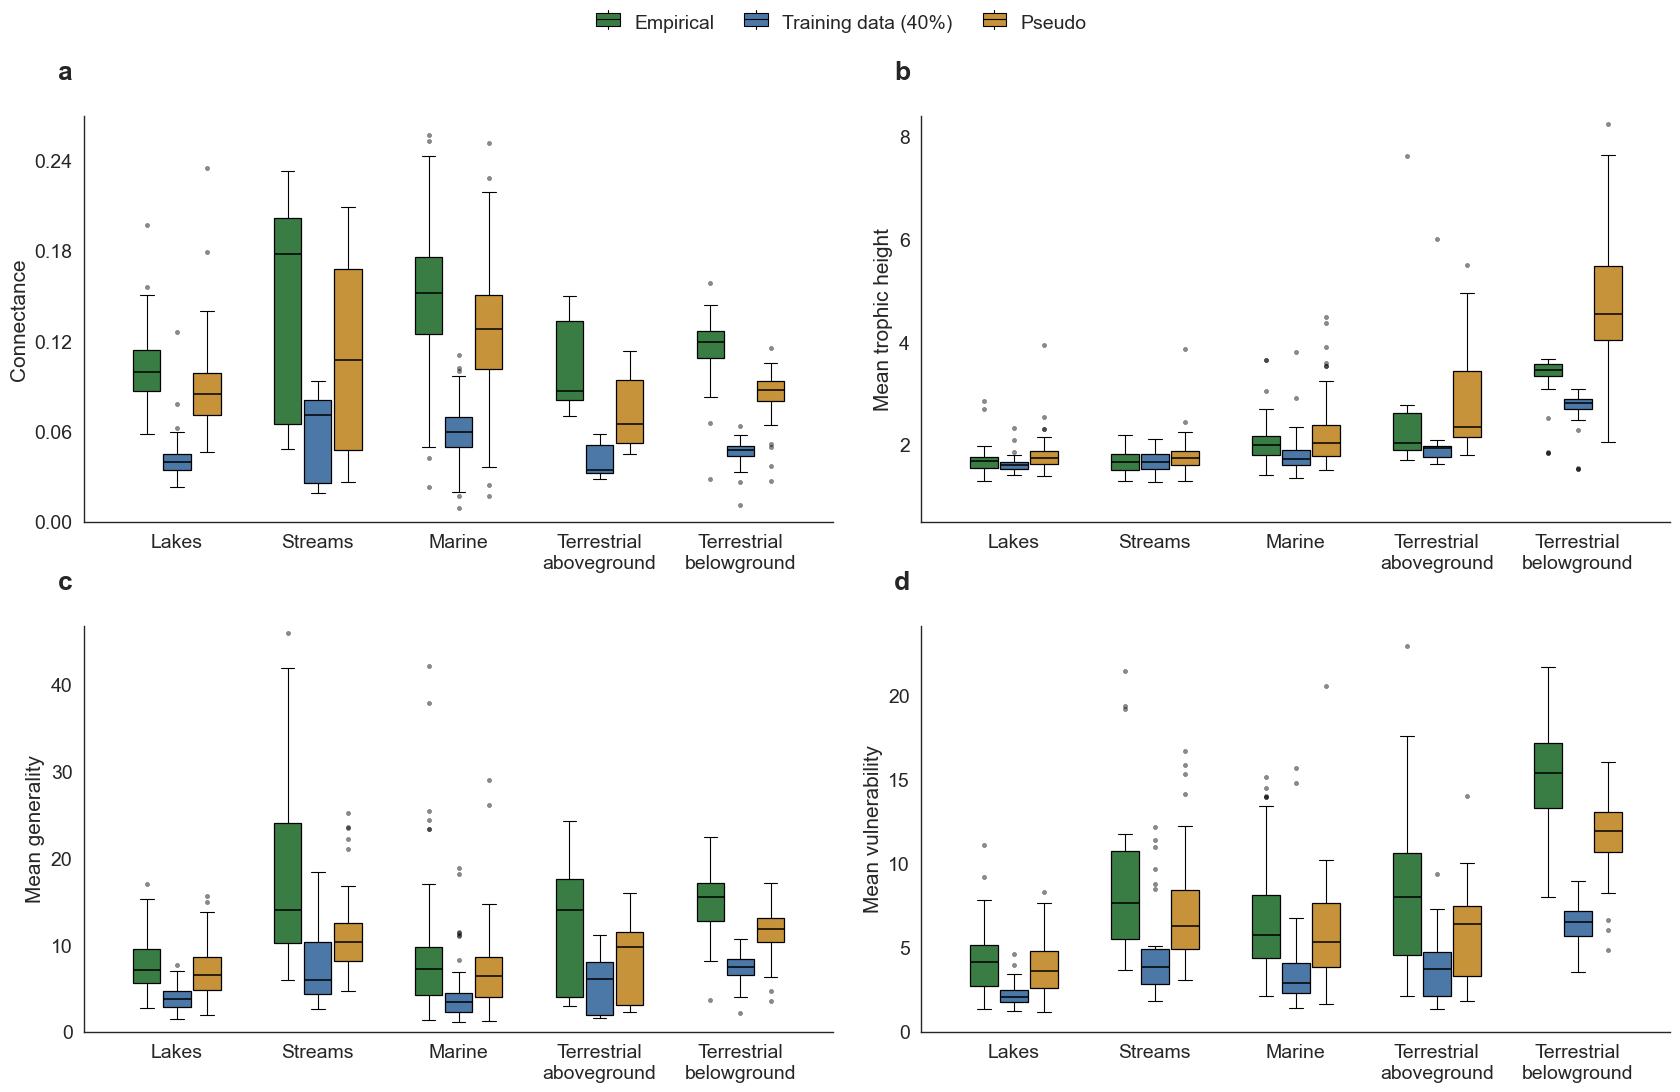


[INFO] TrainRatio = 50; Threshold = 0.5
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/statistical_tests/athen/outlier_filtered_threshold_0p5_no_min_retained/train_ratio_50/athen_web_level_metrics_train50_outlier_filtered.csv
[INFO] Training log dir: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/prediction_scores_logs
[INFO] Loaded outlier-filtered web-level rows: 1,160
[INFO] Training graph web-level rows: 1,160
[INFO] Plotting rows after empirical/train/pseudo expansion: 3,480
[INFO] Pseudo values use Tukey IQR outlier filtering with no minimum retained-run filter.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,267,40,50.0
1,MeanGenerality,290,291,40,50.0
2,MeanTrophicHeight,290,1111,17,44.0
3,MeanVulnerability,290,296,40,49.5


,Metric,Web type,FoodWebs,Rows
0,Connectance,Empirical,290,290
1,Connectance,Training data (50%),290,290
2,Connectance,Pseudo,290,290
3,MeanGenerality,Empirical,290,290
4,MeanGenerality,Training data (50%),290,290
5,MeanGenerality,Pseudo,290,290
6,MeanTrophicHeight,Empirical,290,290
7,MeanTrophicHeight,Training data (50%),290,290
8,MeanTrophicHeight,Pseudo,290,290
9,MeanVulnerability,Empirical,290,290


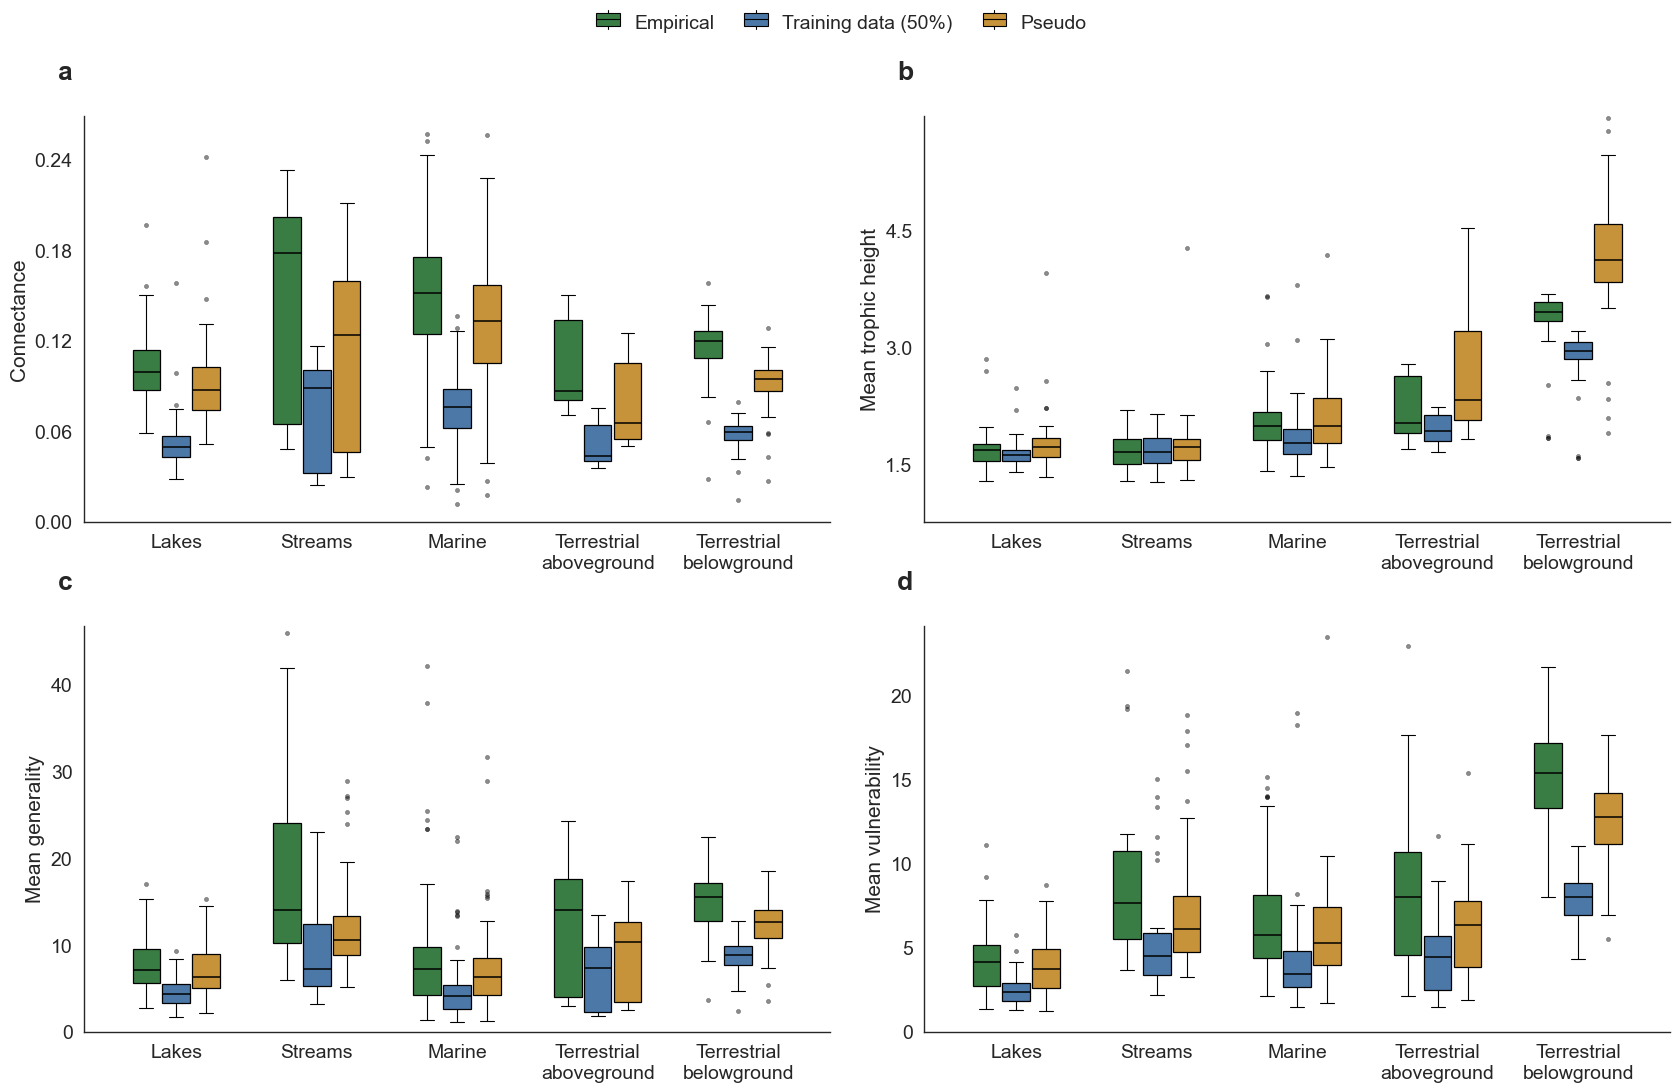


[INFO] TrainRatio = 60; Threshold = 0.5
[INFO] Source file: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/statistical_tests/athen/outlier_filtered_threshold_0p5_no_min_retained/train_ratio_60/athen_web_level_metrics_train60_outlier_filtered.csv
[INFO] Training log dir: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/prediction_scores_logs
[INFO] Loaded outlier-filtered web-level rows: 1,160
[INFO] Training graph web-level rows: 1,160
[INFO] Plotting rows after empirical/train/pseudo expansion: 3,480
[INFO] Pseudo values use Tukey IQR outlier filtering with no minimum retained-run filter.


,Metric,FoodWebs,TotalPseudoRunOutliersRemoved,MinRetainedRuns,MedianRetainedRuns
0,Connectance,290,266,37,50.0
1,MeanGenerality,290,355,40,50.0
2,MeanTrophicHeight,290,1088,25,43.0
3,MeanVulnerability,290,316,37,50.0


,Metric,Web type,FoodWebs,Rows
0,Connectance,Empirical,290,290
1,Connectance,Training data (60%),290,290
2,Connectance,Pseudo,290,290
3,MeanGenerality,Empirical,290,290
4,MeanGenerality,Training data (60%),290,290
5,MeanGenerality,Pseudo,290,290
6,MeanTrophicHeight,Empirical,290,290
7,MeanTrophicHeight,Training data (60%),290,290
8,MeanTrophicHeight,Pseudo,290,290
9,MeanVulnerability,Empirical,290,290


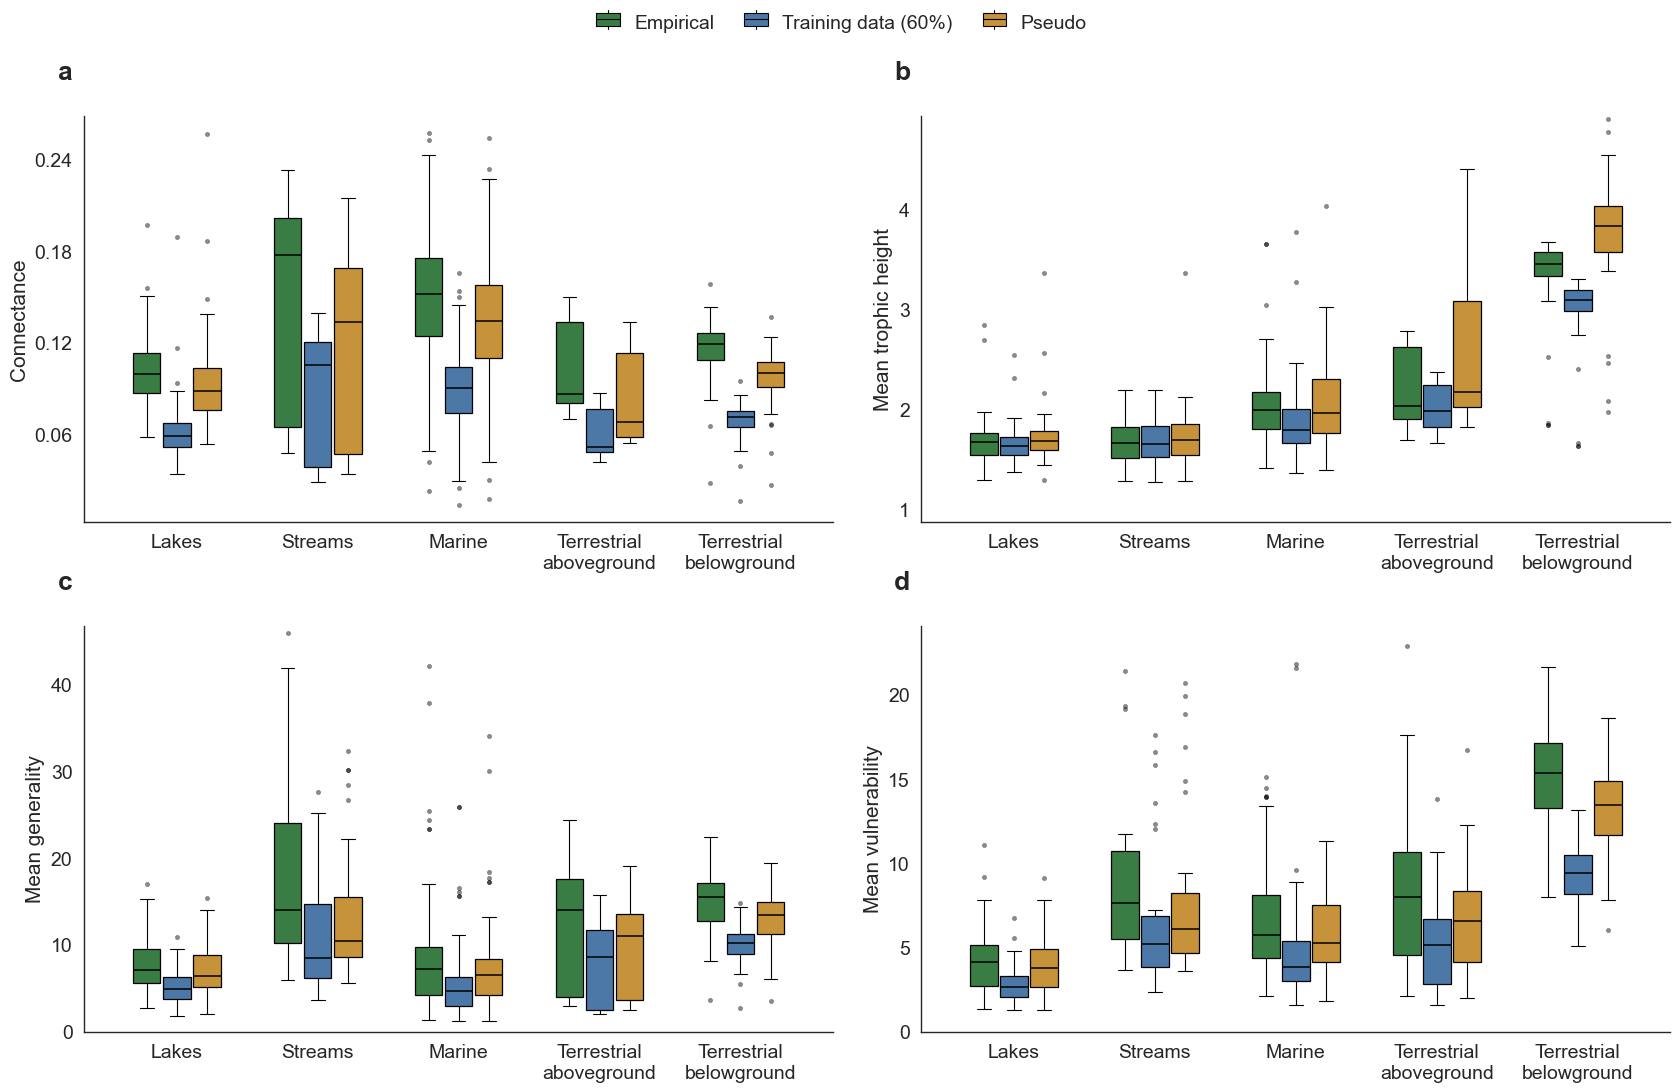

In [ ]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MaxNLocator

sns.set_theme(context="paper", style="white", font_scale=1.15)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()
TRAIN_RATIOS = [40, 50, 60]
THRESHOLD = 0.5

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

OUTLIER_BASE_DIR = (
    RESULT_DIR
    / "statistical_tests/athen/outlier_filtered_threshold_0p5_no_min_retained"
)

WLNM_TRAIN_LOG_DIR = RESULT_DIR / "prediction_scores_logs"

# ============================================================
# CONFIG
# ============================================================
BOX_WIDTH = 0.24
TYPE_OFFSET = 0.26
GROUP_SPACING = 1.22
SHOW_WEB_LEVEL_FLIERS = True

base_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystem_labels = {
    "lakes": "Lakes",
    "streams": "Streams",
    "marine": "Marine",
    "terrestrial aboveground": "Terrestrial\naboveground",
    "terrestrial belowground": "Terrestrial\nbelowground",
}

metric_order = [
    "Connectance",
    "MeanTrophicHeight",
    "MeanGenerality",
    "MeanVulnerability",
]

metric_labels = {
    "Connectance": "Connectance",
    "MeanTrophicHeight": "Mean trophic height",
    "MeanGenerality": "Mean generality",
    "MeanVulnerability": "Mean vulnerability",
}

# Use NetworkX trophic level for train graph to match the outlier-filtered pseudo/empirical source.
train_metric_cols = {
    "Connectance": "TrainConnectance",
    "MeanTrophicHeight": "TrainNetworkXMeanTrophicLevel",
    "MeanGenerality": "TrainMeanGenerality",
    "MeanVulnerability": "TrainMeanVulnerability",
}

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

# ============================================================
# HELPERS
# ============================================================
def format_ecosystem_label(eco: str) -> str:
    eco_clean = str(eco).strip().lower()
    return ecosystem_labels.get(eco_clean, str(eco).strip().capitalize())


def draw_box(ax, values, position, facecolor, showfliers=False):
    ax.boxplot(
        values,
        positions=[position],
        widths=BOX_WIDTH,
        patch_artist=True,
        manage_ticks=False,
        showfliers=showfliers,
        boxprops={"facecolor": facecolor, "edgecolor": "black", "linewidth": 0.9},
        medianprops={"color": "black", "linewidth": 1.1},
        whiskerprops={"color": "black", "linewidth": 0.8},
        capprops={"color": "black", "linewidth": 0.8},
        flierprops={
            "marker": "o",
            "markersize": 3.0,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.4,
            "linestyle": "none",
            "alpha": 0.45,
        },
    )


def get_boxplot_visible_ylim(grouped_values, lower_bound=0.0, pad_fraction=0.12):
    visible_lows = []
    visible_highs = []

    for values in grouped_values:
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]

        if values.size == 0:
            continue

        q1, q3 = np.nanpercentile(values, [25, 75])
        iqr = q3 - q1

        if np.isclose(iqr, 0):
            lower_whisker = np.nanmin(values)
            upper_whisker = np.nanmax(values)
        else:
            lower_fence = q1 - 1.5 * iqr
            upper_fence = q3 + 1.5 * iqr
            non_fliers = values[(values >= lower_fence) & (values <= upper_fence)]

            if non_fliers.size == 0:
                non_fliers = values

            lower_whisker = np.nanmin(non_fliers)
            upper_whisker = np.nanmax(non_fliers)

        visible_lows.extend([lower_whisker, q1])
        visible_highs.extend([upper_whisker, q3])

    if not visible_lows or not visible_highs:
        return None

    local_min = np.nanmin(visible_lows)
    local_max = np.nanmax(visible_highs)
    data_range = local_max - local_min if local_max > local_min else 0.05

    local_min = max(lower_bound, local_min - pad_fraction * data_range)
    local_max = local_max + pad_fraction * data_range

    if np.isclose(local_min, local_max):
        local_min = max(lower_bound, local_min - 0.02)
        local_max = local_max + 0.02

    return local_min, local_max


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.8)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# LOAD TRAINING-GRAPH METRICS ONCE
# ============================================================
train_csv_files = sorted(WLNM_TRAIN_LOG_DIR.glob("*.csv"))
print(f"[INFO] Training log CSV files found: {len(train_csv_files)}")

if not train_csv_files:
    raise FileNotFoundError(f"No training log CSV files found in: {WLNM_TRAIN_LOG_DIR}")

train_usecols = [
    "TrainRatio",
    "ExperimentID",
    "Seed",
    "ThresholdMode",
    "Threshold",
    *train_metric_cols.values(),
]

train_frames = []
for csv_file in train_csv_files:
    df_i = pd.read_csv(csv_file, usecols=lambda c: c in train_usecols)
    df_i["FoodWeb"] = csv_file.name.replace("_results_random_wlnm_dir_neg.csv", "")
    train_frames.append(df_i)

train_logs_all = pd.concat(train_frames, ignore_index=True)

train_logs_all["TrainRatio"] = pd.to_numeric(train_logs_all["TrainRatio"], errors="coerce")
train_logs_all["Threshold"] = pd.to_numeric(train_logs_all["Threshold"], errors="coerce")

for col in train_metric_cols.values():
    train_logs_all[col] = pd.to_numeric(train_logs_all[col], errors="coerce")


# ============================================================
# PLOT FUNCTION
# ============================================================
def plot_fig5_for_train_ratio(train_ratio):
    athen_outlier_dir = OUTLIER_BASE_DIR / f"train_ratio_{train_ratio}"
    athen_web_level_filtered = (
        athen_outlier_dir
        / f"athen_web_level_metrics_train{train_ratio}_outlier_filtered.csv"
    )

    if not athen_web_level_filtered.exists():
        raise FileNotFoundError(f"Missing file: {athen_web_level_filtered}")

    training_label = f"Training data ({train_ratio}%)"

    web_type_order = [
        "Empirical",
        training_label,
        "Pseudo",
    ]

    type_offsets = {
        "Empirical": -TYPE_OFFSET,
        training_label: 0.0,
        "Pseudo": TYPE_OFFSET,
    }

    type_palette = {
        "Empirical": "#3A7D44",
        training_label: "#4C78A8",
        "Pseudo": "#C6923A",
    }

    # ========================================================
    # LOAD OUTLIER-FILTERED WEB-LEVEL DATA
    # ========================================================
    athen = pd.read_csv(athen_web_level_filtered)

    athen["TrainRatio"] = pd.to_numeric(athen["TrainRatio"], errors="coerce")
    athen["EmpiricalValue"] = pd.to_numeric(athen["EmpiricalValue"], errors="coerce")
    athen["MeanPseudoAfterFiltering"] = pd.to_numeric(
        athen["MeanPseudoAfterFiltering"],
        errors="coerce",
    )
    athen["IncludedAfterFiltering"] = (
        pd.to_numeric(athen["IncludedAfterFiltering"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    athen["OutlierRunsRemoved"] = pd.to_numeric(
        athen["OutlierRunsRemoved"],
        errors="coerce",
    ).fillna(0).astype(int)
    athen["ValidRunsAfterFiltering"] = pd.to_numeric(
        athen["ValidRunsAfterFiltering"],
        errors="coerce",
    ).fillna(0).astype(int)

    plot_source = (
        athen[
            (athen["TrainRatio"] == train_ratio)
            & (athen["Metric"].isin(metric_order))
            & (athen["IncludedAfterFiltering"] == 1)
        ]
        .copy()
    )

    plot_source["ecosystem"] = (
        plot_source["EcosystemType"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # ========================================================
    # BUILD EMPIRICAL AND PSEUDO WEB-LEVEL DATA
    # ========================================================
    empirical_df = plot_source[
        ["FoodWeb", "ecosystem", "Metric", "EmpiricalValue"]
    ].rename(columns={"EmpiricalValue": "value"})
    empirical_df["Web type"] = "Empirical"

    pseudo_df = plot_source[
        ["FoodWeb", "ecosystem", "Metric", "MeanPseudoAfterFiltering"]
    ].rename(columns={"MeanPseudoAfterFiltering": "value"})
    pseudo_df["Web type"] = "Pseudo"

    # ========================================================
    # BUILD TRAINING-GRAPH WEB-LEVEL DATA
    # ========================================================
    train_logs = train_logs_all[
        (train_logs_all["TrainRatio"].round(0) == train_ratio)
        & (train_logs_all["ThresholdMode"].astype(str).str.lower().eq("threshold_sweep"))
        & (np.isclose(train_logs_all["Threshold"], THRESHOLD))
    ].copy()

    train_logs = train_logs.drop_duplicates(
        subset=["FoodWeb", "TrainRatio", "ExperimentID", "Seed"]
    )

    train_long_frames = []
    for metric, train_col in train_metric_cols.items():
        tmp = train_logs[["FoodWeb", train_col]].rename(columns={train_col: "value"})
        tmp["Metric"] = metric
        train_long_frames.append(tmp)

    train_long = pd.concat(train_long_frames, ignore_index=True)
    train_long["value"] = pd.to_numeric(train_long["value"], errors="coerce")
    train_long = train_long.dropna(subset=["value"])

    # One training value per food web and metric, averaged over repeated runs.
    train_web_level = (
        train_long
        .groupby(["FoodWeb", "Metric"], as_index=False, observed=True)
        .agg(value=("value", "mean"))
    )

    included_keys = plot_source[["FoodWeb", "ecosystem", "Metric"]].drop_duplicates()

    train_df = train_web_level.merge(
        included_keys,
        on=["FoodWeb", "Metric"],
        how="inner",
    )
    train_df["Web type"] = training_label

    # ========================================================
    # FINAL PLOTTING DATA
    # ========================================================
    plot_df = pd.concat(
        [empirical_df, train_df, pseudo_df],
        ignore_index=True,
    )

    plot_df["value"] = pd.to_numeric(plot_df["value"], errors="coerce")
    plot_df = plot_df.dropna(subset=["value", "ecosystem", "Metric", "Web type"])

    plot_df["Web type"] = pd.Categorical(
        plot_df["Web type"],
        categories=web_type_order,
        ordered=True,
    )

    print(f"\n[INFO] TrainRatio = {train_ratio}; Threshold = {THRESHOLD}")
    print(f"[INFO] Source file: {athen_web_level_filtered}")
    print(f"[INFO] Training log dir: {WLNM_TRAIN_LOG_DIR}")
    print(f"[INFO] Loaded outlier-filtered web-level rows: {len(plot_source):,}")
    print(f"[INFO] Training graph web-level rows: {len(train_df):,}")
    print(f"[INFO] Plotting rows after empirical/train/pseudo expansion: {len(plot_df):,}")
    print("[INFO] Pseudo values use Tukey IQR outlier filtering with no minimum retained-run filter.")

    removed_summary = (
        plot_source
        .groupby("Metric", as_index=False)
        .agg(
            FoodWebs=("FoodWeb", "nunique"),
            TotalPseudoRunOutliersRemoved=("OutlierRunsRemoved", "sum"),
            MinRetainedRuns=("ValidRunsAfterFiltering", "min"),
            MedianRetainedRuns=("ValidRunsAfterFiltering", "median"),
        )
    )

    display(removed_summary)

    web_type_counts = (
        plot_df
        .groupby(["Metric", "Web type"], observed=True)
        .agg(FoodWebs=("FoodWeb", "nunique"), Rows=("value", "size"))
        .reset_index()
    )

    display(web_type_counts)

    # ========================================================
    # PLOT
    # ========================================================
    n_panels = len(metric_order)
    n_cols = 2
    n_rows = math.ceil(n_panels / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 10.6), sharey=False)
    axes = np.array(axes).reshape(-1)

    legend_handles = [
        {"facecolor": type_palette[web_type], "edgecolor": "black", "linewidth": 0.8}
        for web_type in web_type_order
    ]
    legend_labels = web_type_order

    for idx, (ax, metric) in enumerate(zip(axes, metric_order)):
        panel_df = plot_df[plot_df["Metric"] == metric].copy()

        if panel_df.empty:
            ax.set_visible(False)
            continue

        present_ecosystems = [
            eco for eco in base_ecosystem_order
            if eco in panel_df["ecosystem"].unique()
        ]
        extra_ecosystems = [
            eco for eco in panel_df["ecosystem"].unique()
            if eco not in base_ecosystem_order
        ]
        eco_order = present_ecosystems + extra_ecosystems

        base_positions = np.arange(len(eco_order)) * GROUP_SPACING
        boxplot_groups = []

        for eco, base_x in zip(eco_order, base_positions):
            eco_df = panel_df[panel_df["ecosystem"] == eco]

            for web_type in web_type_order:
                values = (
                    eco_df[eco_df["Web type"] == web_type]["value"]
                    .dropna()
                    .values
                )

                if len(values):
                    draw_box(
                        ax=ax,
                        values=values,
                        position=base_x + type_offsets[web_type],
                        facecolor=type_palette[web_type],
                        showfliers=SHOW_WEB_LEVEL_FLIERS,
                    )
                    boxplot_groups.append(values)

        ax.set_title("")
        ax.set_ylabel(metric_labels[metric], fontsize=15)
        ax.set_xlabel("")
        ax.tick_params(axis="both", labelsize=14)

        ylim = get_boxplot_visible_ylim(
            boxplot_groups,
            lower_bound=0.0,
            pad_fraction=0.12,
        )

        if ylim is not None:
            ax.set_ylim(*ylim)
            ax.yaxis.set_major_locator(MaxNLocator(5))

        ax.set_xlim(base_positions[0] - 0.80, base_positions[-1] + 0.80)

        ax.set_xticks(base_positions)
        ax.set_xticklabels(
            [format_ecosystem_label(eco) for eco in eco_order],
            rotation=0,
            fontsize=14,
        )

        ax.grid(False, axis="x")
        ax.grid(False, axis="y")
        sns.despine(ax=ax)

        ax.annotate(
            panel_letters[idx],
            xy=(0, 1.05),
            xycoords="axes fraction",
            xytext=(-8, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=19,
            fontweight="bold",
            annotation_clip=False,
        )

    for j in range(len(metric_order), len(axes)):
        axes[j].set_visible(False)

    # ========================================================
    # GLOBAL LEGEND
    # ========================================================
    fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        handler_map={dict: HandlerMiniBoxplot()},
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=3,
        frameon=False,
        fontsize=14,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        columnspacing=1.4,
        borderpad=0.2,
        labelspacing=0.45,
    )

    fig.tight_layout(pad=1.3, w_pad=2.0, h_pad=0)

    plt.show()


# ============================================================
# PRINT FIGURES FOR 40%, 50%, AND 60%
# ============================================================
for train_ratio in TRAIN_RATIOS:
    plot_fig5_for_train_ratio(train_ratio)

`check_connectivity` y `adaptive_connectivity` se usan en `DivideNet_dir_neg` para controlar cómo se mueven links positivos desde la red completa hacia `test`.

**`check_connectivity`**
Si está en `true`, antes de mover un link positivo `u -> v` al conjunto `test`, el código lo elimina temporalmente de `train` y revisa si todavía existe una ruta alternativa de `u` a `v` dentro del grafo de entrenamiento.

En términos simples:

```text
Si quito u -> v del train,
¿todavía puedo llegar de u a v por otro camino dirigido?
```

- Si sí existe ruta alternativa: el link puede ir a `test`.
- Si no existe ruta alternativa: el link se queda en `train`.

Su objetivo es evitar que el train graph pierda conectividad funcional para ciertos pares positivos.

**`adaptive_connectivity`**
Es una protección para redes pequeñas. En `DivideNet_dir_neg`, si:

```matlab
adaptive_connectivity == true
n < 30
use_backbone == false
```

entonces el código fuerza:

```matlab
check_connectivity = false
```

Es decir, desactiva el chequeo de conectividad en food webs pequeñas para evitar que el split se vuelva demasiado restrictivo y deje muy pocos links positivos en `test`.

**Cuándo se activan**
En `WLNM_dir_neg`, aplican solo en modo estándar:

```text
use_backbone = false
```

No aplican en el modo backbone, porque backbone usa otra lógica de split.

**Cómo afectan la ejecución**
Afectan directamente el split de links positivos:

- Con `check_connectivity = false`: los links positivos se asignan a `train/test` de forma más libre según el `trainRatio`.
- Con `check_connectivity = true`: algunos links que deberían ir a `test` pueden quedarse en `train` si quitarlos rompe la ruta dirigida `u -> v`.
- Con `adaptive_connectivity = true`: ese chequeo se desactiva automáticamente para redes pequeñas `n < 30`.

**Efecto indirecto sobre negativos**
No cambian directamente el pool total de negativos, porque el negative sampling se calcula contra la red empírica completa `train + test`. Pero sí pueden cambiar:

- `Train Positive`
- `Test Positive`
- por lo tanto `Train Negative`
- y `Test Negative`

porque el número de negativos requeridos depende del número de positivos en train/test.

**Resumen corto**
```text
check_connectivity=true:
    split más conservador; evita mover a test links que rompen rutas dirigidas en train.

adaptive_connectivity=true:
    desactiva check_connectivity automáticamente en food webs pequeñas, n < 30.

check_connectivity=true + adaptive_connectivity=false:
    aplica el chequeo de conectividad a todas las food webs, incluidas las pequeñas.
```

---

Lo implementamos en `WLNM_dir_neg` como una **preferencia configurable**, no como filtro duro.

**Interpretación ecológica**
La red está dirigida como flujo de energía:

```text
i -> j
resource -> consumer
```

Entonces, para un candidato negativo `i -> j`:

```text
mass(i) = masa del recurso candidato
mass(j) = masa del consumidor candidato
```

La regla preferida es:

```text
mass(j) / mass(i) < 1
```

Equivalente a:

```text
mass(j) < mass(i)
```

Es decir: priorizamos como negativos aquellos enlaces candidatos donde el consumidor propuesto es más pequeño que el recurso propuesto. Para muchas interacciones depredador-presa, esto es menos plausible, por lo que es razonable tratarlos como buenos candidatos negativos.

**Por qué no es un filtro duro**
No lo usamos como condición obligatoria porque hay excepciones ecológicas reales:

- parasitismo,
- carroñeo,
- consumo grupal,
- etapas de vida,
- interacciones con recursos grandes pero vulnerables.

Por eso la masa no elimina candidatos irreversiblemente. Solo cambia el orden de prioridad del muestreo negativo.

**Parámetros configurables**
En `Main.m` quedaron estos parámetros:

```matlab
negativeMassPreferenceEnabled = true
negativeMassPreferenceThreshold = 1.0
```

Y también se pueden controlar desde Apocrita con:

```bash
export WLNM_NEGATIVE_MASS_PREFERENCE_ENABLED=true
export WLNM_NEGATIVE_MASS_PREFERENCE_THRESHOLD=1.0
```

La fórmula general implementada es:

```text
mass(j) < threshold * mass(i)
```

Con `threshold = 1.0`, queda exactamente:

```text
mass(j) / mass(i) < 1
```

**Orden de prioridad implementado**
Para cada candidato negativo `i -> j`, calculamos dos condiciones:

```text
Role(i,j) = cumple las 5 ecological role constraints
Mass(i,j) = mass(j) < threshold * mass(i)
```

Luego los negativos se seleccionan en este orden:

```text
1. Role + Mass
2. Role + No mass
3. No role + Mass
4. No role + No mass (top-up with random sampling)
```

En fórmula:

```text
Priority 1: Role(i,j) = true  and Mass(i,j) = true
Priority 2: Role(i,j) = true  and Mass(i,j) = false
Priority 3: Role(i,j) = false and Mass(i,j) = true
Priority 4: Role(i,j) = false and Mass(i,j) = false
```

**Qué significa esto**
La lógica sigue siendo `role-first`:

1. Primero intenta usar candidatos que cumplen las constraints de rol.
2. Dentro de esos, prefiere los que también cumplen masa.
3. Si el pool con rol no alcanza, usa candidatos que no cumplen rol pero sí cumplen masa.
4. Solo si todavía faltan negativos, usa candidatos sin rol ni masa como random top-up.

**Justificación metodológica**
Esta implementación preserva la lógica ecológica original y añade masa como evidencia adicional. La ventaja es que reduce el uso de negativos puramente aleatorios sin eliminar excepciones biológicas válidas.

Resultado observado:

```text
207 food webs: suficientes con role constraints
81 food webs: role constraints insuficientes, completadas por preferencia de masa
2 food webs: todavía requieren random top-up
```

Entonces podemos reportar:

> Body mass was incorporated as a configurable preferred negative-sampling rule. Candidate non-links were prioritised when the putative consumer was smaller than the putative resource, using mass(j) / mass(i) < 1. This preference was applied after the existing ecological role constraints and before random top-up, reducing the number of food webs requiring purely random top-up from 83 to 2.

In [ ]:
from pathlib import Path
import re

import pandas as pd

REPO_ROOT = Path("/Users/acw792/Developer/qmul-phd-framework")

RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "terminal_logs"

negpool_pattern = re.compile(
    r"\[NegPool\].*?"
    r"role_pool=(?P<role_pool>\d+)\s+"
    r"full_pool=(?P<full_pool>\d+)\s+"
    r"need_total=(?P<need_total>\d+)"
)

mass_pattern = re.compile(
    r"\[NegMassPref\].*?"
    r"role_mass=(?P<role_mass>\d+)\s+"
    r"role_other=(?P<role_other>\d+)\s+"
    r"nonrole_mass=(?P<nonrole_mass>\d+)\s+"
    r"nonrole_other=(?P<nonrole_other>\d+)"
)

rows = []

for log_file in sorted(LOG_DIR.glob("*_terminal_log.txt")):
    foodweb = (
        log_file.name
        .replace("_wlnm_dir_neg_terminal_log.txt", "")
        .removesuffix("_tax_mass")
    )

    negpool_matches = []
    mass_matches = []

    for line in log_file.read_text(errors="ignore").splitlines():
        negpool_match = negpool_pattern.search(line)
        if negpool_match:
            negpool_matches.append(tuple(int(v) for v in negpool_match.groupdict().values()))

        mass_match = mass_pattern.search(line)
        if mass_match:
            mass_matches.append(tuple(int(v) for v in mass_match.groupdict().values()))

    if not negpool_matches or not mass_matches:
        rows.append({
            "FoodWeb": foodweb,
            "Scenario": "Missing log information",
            "Required negative links": pd.NA,
            "Total available negative pool": pd.NA,
            "Role+Mass": pd.NA,
            "Role+No mass": pd.NA,
            "No role+Mass": pd.NA,
            "No role+No mass": pd.NA,
        })
        continue

    # These values are repeated across runs; use the unique pool composition.
    role_pool, full_pool, need_total = sorted(set(negpool_matches))[0]
    role_mass, role_other, nonrole_mass, nonrole_other = sorted(set(mass_matches))[0]

    if nonrole_other > 0:
        scenario = "Needs random top-up"
    elif nonrole_mass > 0:
        scenario = "Completed by mass preference"
    else:
        scenario = "Role constraints sufficient"

    rows.append({
        "FoodWeb": foodweb,
        "Scenario": scenario,
        "Required negative links": need_total,
        "Total available negative pool": full_pool,
        "Role+Mass": role_mass,
        "Role+No mass": role_other,
        "No role+Mass": nonrole_mass,
        "No role+No mass": nonrole_other,
    })

negative_sampling_df = pd.DataFrame(rows)

scenario_order = [
    "Role constraints sufficient",
    "Completed by mass preference",
    "Needs random top-up",
    "Missing log information",
]

negative_sampling_df["Scenario"] = pd.Categorical(
    negative_sampling_df["Scenario"],
    categories=scenario_order,
    ordered=True,
)

negative_sampling_df = (
    negative_sampling_df
    .sort_values(["Scenario", "FoodWeb"])
    .reset_index(drop=True)
)

summary_df = (
    negative_sampling_df
    .groupby("Scenario", observed=True, as_index=False)
    .agg(FoodWebs=("FoodWeb", "nunique"))
)

summary_df["Percent"] = (
    100 * summary_df["FoodWebs"] / negative_sampling_df["FoodWeb"].nunique()
).round(2)

random_topup_df = (
    negative_sampling_df[
        negative_sampling_df["Scenario"].eq("Needs random top-up")
    ]
    .sort_values("No role+No mass", ascending=False)
    .reset_index(drop=True)
)

print(f"Food webs analysed: {negative_sampling_df['FoodWeb'].nunique()}")

display(summary_df)
display(random_topup_df)
display(negative_sampling_df.head(20))

Food webs analysed: 290


,Scenario,FoodWebs,Percent
0,Role constraints sufficient,207,71.38
1,Completed by mass preference,81,27.93
2,Needs random top-up,2,0.69


,FoodWeb,Scenario,Required negative links,Total available negative pool,Role+Mass,Role+No mass,No role+Mass,No role+No mass
0,Skipwith Pond,Needs random top-up,708,768,9,56,444,199
1,PC1P2,Needs random top-up,212,314,95,25,87,5


,FoodWeb,Scenario,Required negative links,Total available negative pool,Role+Mass,Role+No mass,No role+Mass,No role+No mass
0,AP1,Role constraints sufficient,30,141,30,0,0,0
1,AP2,Role constraints sufficient,74,269,74,0,0,0
2,AP4,Role constraints sufficient,42,111,32,10,0,0
3,Afon Hafren 2005,Role constraints sufficient,206,359,124,82,0,0
4,Alert,Role constraints sufficient,72,204,27,45,0,0
5,Alford lake,Role constraints sufficient,434,2863,434,0,0,0
6,Allt a Mharcaidh,Role constraints sufficient,514,1075,342,172,0,0
7,BP1,Role constraints sufficient,178,667,178,0,0,0
8,BP2,Role constraints sufficient,66,273,66,0,0,0
9,BP3,Role constraints sufficient,92,416,92,0,0,0


[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in run-level results before node filter: 290
[INFO] Applied TrainRatio filter: TrainRatio == 90
[INFO] Applied Threshold filter: Threshold == 0.5
[INFO] Run-level rows after filtering: 20,160
Version
dir_neg     14500
original     5660
dtype: int64
[INFO] Web-level rows after averaging runs: 573


,FoodWebs,MinRuns,MedianRuns,MaxRuns
Version,,,,
dir_neg,290,50,50.0,50
original,283,20,20.0,20



=== Web-level predictive metric summary ===


,Version,Metric,Mean,Median,SD,Variance
0,Original,ROC-AUC,0.7686,0.8244,0.1812,0.0328
1,Original,PR-AUC,0.5328,0.5946,0.2201,0.0484
2,Original,F1,0.5700,0.6471,0.2576,0.0664
3,Original,MCC,0.4415,0.5218,0.2910,0.0847
4,Original,Precision,0.6046,0.7000,0.2594,0.0673
5,Original,Recall,0.5642,0.6250,0.2650,0.0702
6,Original,TSS,0.4359,0.5000,0.2796,0.0782
7,Directed-negative,ROC-AUC,0.8951,0.9166,0.1032,0.0107
8,Directed-negative,PR-AUC,0.4696,0.4426,0.1679,0.0282
9,Directed-negative,F1,0.6856,0.7530,0.2268,0.0514


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/statistical_tests/athen/figures/predictive_metrics_original_vs_dir_neg_train90_threshold0p5_web_level.png


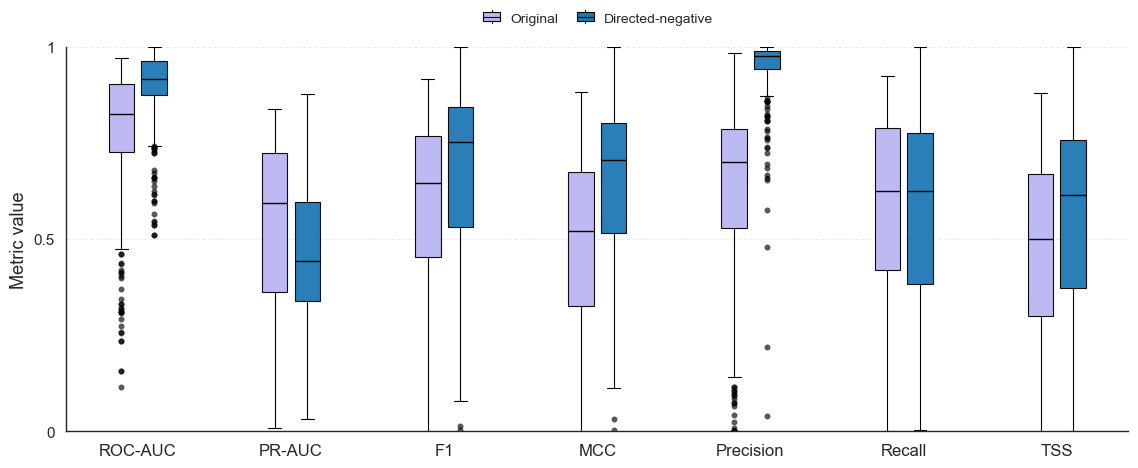

In [41]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_theme(context="paper", style="white", font_scale=1.1)

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
TRAIN_RATIO_TARGET = 90
THRESHOLD_TARGET = 0.5
NODES_THRESHOLD = 0

RESULTS_DIR_ORIGINAL = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties_Apocrita"
    / "prediction_scores_logs"
)

RESULTS_DIR_DIR_NEG = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
    / "prediction_scores_logs"
)

FOODWEB_CSV = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = (
    REPO_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
    / "statistical_tests/athen/figures"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / (
    f"predictive_metrics_original_vs_dir_neg_"
    f"train{TRAIN_RATIO_TARGET}_threshold0p5_web_level.png"
)

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]

K_TARGET = None
K_COL = "K"
TRAIN_RATIO_COL = "TrainRatio"
THRESHOLD_COL = "Threshold"
THRESHOLD_MODE_COL = "ThresholdMode"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIR_NEG = "*_tax_mass_results_random_wlnm_dir_neg.csv"

SHOW_WEB_LEVEL_FLIERS = True

# ============================================================
# Helpers
# ============================================================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(
        df,
        METRICS + [K_COL, TRAIN_RATIO_COL, THRESHOLD_COL],
    )

    if TRAIN_RATIO_COL not in df.columns:
        print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
        return None

    df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

    if df.empty:
        return None

    # Keep only classification threshold = 0.5 when Threshold exists.
    # Older fixed-threshold outputs may not have Threshold; those are treated as fixed 0.5.
    if THRESHOLD_COL in df.columns:
        df[THRESHOLD_COL] = pd.to_numeric(df[THRESHOLD_COL], errors="coerce").round(1)
        df = df[df[THRESHOLD_COL] == THRESHOLD_TARGET].copy()

        if df.empty:
            return None

        # Avoid double-counting default + threshold_sweep rows if both exist.
        if THRESHOLD_MODE_COL in df.columns:
            threshold_modes = df[THRESHOLD_MODE_COL].astype(str).str.lower()

            if threshold_modes.eq("threshold_sweep").any():
                df = df[threshold_modes.eq("threshold_sweep")].copy()

            if df.empty:
                return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    records = []
    foodweb = parse_foodweb_from_name(csv_path.name)

    for run_idx, row in df.reset_index(drop=True).iterrows():
        out = {
            "Foodweb": foodweb,
            "Version": version,
            "Run": run_idx + 1,
            "n_runs_in_file_after_filter": int(len(df)),
            "file": csv_path.name,
            "folder": str(csv_path.parent),
            "ThresholdUsed": THRESHOLD_TARGET,
        }

        valid_any = False

        for metric in METRICS:
            if metric in df.columns:
                val = row[metric]
                out[metric] = float(val) if pd.notna(val) else np.nan
                if pd.notna(val):
                    valid_any = True
            else:
                out[metric] = np.nan

        if valid_any:
            records.append(out)

    return records if records else None


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        recs = load_one_csv(p, version=version)
        if recs is not None:
            rows.extend(recs)

    return rows


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# ============================================================
# Load run-level CSVs
# ============================================================
rows = []
rows += load_folder(
    RESULTS_DIR_ORIGINAL,
    GLOB_PATTERN_ORIGINAL,
    version="original",
)
rows += load_folder(
    RESULTS_DIR_DIR_NEG,
    GLOB_PATTERN_DIR_NEG,
    version="dir_neg",
)

run_df = pd.DataFrame(rows)

if run_df.empty:
    raise RuntimeError("No valid rows after loading folders. Check paths or CSV columns.")

# ============================================================
# Apply node filter
# ============================================================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
run_df["FW_KEY"] = run_df["Foodweb"].apply(normalize_fw_label)

allowed_fw_keys = set(
    meta.loc[meta[nodes_col] >= NODES_THRESHOLD, "FW_KEY"].unique()
)

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in run-level results before node filter: {run_df['FW_KEY'].nunique()}")

run_df = run_df[run_df["FW_KEY"].isin(allowed_fw_keys)].copy()

if run_df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")
print(f"[INFO] Applied Threshold filter: Threshold == {THRESHOLD_TARGET}")
print(f"[INFO] Run-level rows after filtering: {len(run_df):,}")
print(run_df.groupby("Version").size())

# ============================================================
# Web-level aggregation
# ============================================================
# One row per Foodweb x Version, after averaging repeated runs.
agg_dict = {metric: "mean" for metric in METRICS}
agg_dict["Run"] = "count"

web_df = (
    run_df
    .groupby(["Foodweb", "FW_KEY", "Version"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Run": "ValidRuns"})
)

print(f"[INFO] Web-level rows after averaging runs: {len(web_df):,}")
display(
    web_df.groupby("Version").agg(
        FoodWebs=("Foodweb", "nunique"),
        MinRuns=("ValidRuns", "min"),
        MedianRuns=("ValidRuns", "median"),
        MaxRuns=("ValidRuns", "max"),
    )
)

# ============================================================
# Summary table
# ============================================================
order = ["original", "dir_neg"]

label_map = {
    "original": "Original",
    "dir_neg": "Directed-negative",
}

palette = {
    "original": "#bab6f2",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

summary_rows = []

for version in order:
    for metric_col, metric_label in plot_metrics:
        vals = web_df.loc[web_df["Version"] == version, metric_col].dropna()

        summary_rows.append({
            "Version": label_map.get(version, version),
            "Metric": metric_label,
            # "N food webs": int(vals.shape[0]),
            "Mean": vals.mean(),
            "Median": vals.median(),
            "SD": vals.std(ddof=1),
            "Variance": vals.var(ddof=1),
        })

summary_table = pd.DataFrame(summary_rows)
for col in ["Mean", "Median", "SD", "Variance"]:
    summary_table[col] = summary_table[col].round(4)

print("\n=== Web-level predictive metric summary ===")
display(summary_table)

# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

offsets = np.array([-0.16, 0.16])
box_width = 0.25

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            web_df.loc[web_df["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=4,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.65,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels(
    [label for _, label in plot_metrics],
    rotation=0,
    ha="center",
    fontsize=12,
)

ax.set_ylabel("Metric value", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=len(order),
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
    columnspacing=1.2,
)

sns.despine(ax=ax)
plt.tight_layout()

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Using LOG_DIR: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_20x290_cvK3-5-10_thresh10-90_masspref_trainmetrics_Apocrita/prediction_scores_logs
[INFO] Found 870 CSV files matching pattern: *tax_mass_results_random_wlnm_dir_neg_kfold*.csv

[INFO] Run-level data shape:
(104400, 14)

[INFO] Applied Threshold filter: Threshold == 0.5

[INFO] Foodweb count per CvK before web-level averaging:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64

[INFO] Raw row count per CvK before web-level averaging:
CvK
3     17400
5     29000
10    58000
dtype: int64

[INFO] Web-level data shape after averaging repeated experiment/fold rows:
(870, 14)

[INFO] Web-level count and rows averaged per CvK:


,CvK,FoodWebs,TrainRatio,Threshold,MinRowsAveraged,MedianRowsAveraged,MaxRowsAveraged
0,3,290,66.666667,0.5,60,60.0,60
1,5,290,80.000000,0.5,100,100.0,100
2,10,290,90.000000,0.5,200,200.0,200



=== Web-level k-fold predictive metric summary at threshold 0.5 ===


,CvK,Label,Metric,N food webs,Mean,Median,SD,Variance
0,3,3-fold (66.7% train),ROC-AUC,290,0.8611,0.8858,0.1082,0.0117
1,3,3-fold (66.7% train),PR-AUC,290,0.5061,0.5071,0.1574,0.0248
2,3,3-fold (66.7% train),F1,290,0.6779,0.7325,0.1995,0.0398
3,3,3-fold (66.7% train),MCC,290,0.6302,0.6725,0.1905,0.0363
4,3,3-fold (66.7% train),Precision,290,0.9119,0.9515,0.0985,0.0097
5,3,3-fold (66.7% train),Recall,290,0.5808,0.6240,0.2217,0.0491
6,3,3-fold (66.7% train),TSS,290,0.5515,0.5853,0.2226,0.0495
7,5,5-fold (80% train),ROC-AUC,290,0.8764,0.8993,0.1038,0.0108
8,5,5-fold (80% train),PR-AUC,290,0.5082,0.4982,0.1634,0.0267
9,5,5-fold (80% train),F1,290,0.6805,0.7401,0.2086,0.0435


[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_kfold_20x290_cvK3-5-10_thresh10-90_masspref_trainmetrics_Apocrita/statistical_tests/athen/figures/predictive_metrics_wlnm_dir_neg_kfold_threshold0p5_web_level.png


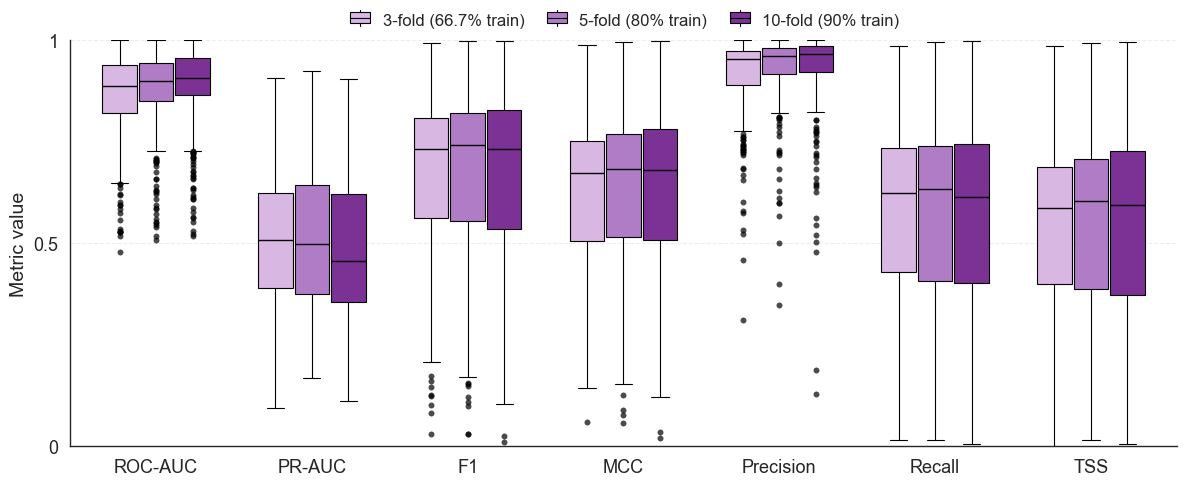

In [42]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_kfold_20x290_cvK3-5-10_thresh10-90_masspref_trainmetrics_Apocrita"
)

LOG_DIR = RESULT_DIR / "prediction_scores_logs"

OUT_DIR = RESULT_DIR / "statistical_tests/athen/figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_TARGET = 0.5
THRESHOLD_COL = "Threshold"
THRESHOLD_MODE_COL = "ThresholdMode"

OUT_PATH = OUT_DIR / "predictive_metrics_wlnm_dir_neg_kfold_threshold0p5_web_level.png"

PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold*.csv"

K_TARGET = 10
K_COL = "K"

cvk_order = [3, 5, 10]

SHOW_WEB_LEVEL_FLIERS = True

METRIC_SOURCES = {
    "ROC_AUC": ["ROC_AUC"],
    "PR_AUC": ["PR_AUC"],
    "F1Score": ["F1Score", "TestF1Score", "PseudoF1Score"],
    "TestMCC": ["TestMCC", "PseudoMCC"],
    "Precision": ["Precision", "TestPrecision", "PseudoPrecision"],
    "Recall": ["Recall", "TestRecall", "PseudoRecall"],
    "TestTSS": ["TestTSS", "PseudoTSS"],
}

METRICS = list(METRIC_SOURCES.keys())

plot_metrics = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

# ============================================================
# Helpers
# ============================================================
def cvk_label(k: int) -> str:
    train_ratio_map = {
        3: "66.7%",
        5: "80%",
        10: "90%",
    }
    if k in train_ratio_map:
        return f"{k}-fold ({train_ratio_map[k]} train)"
    return f"{k}-fold"


def foodweb_name_from_path(p: str) -> str:
    name = Path(p).name
    return re.sub(
        r"_tax_mass_results_random_wlnm_dir_neg_kfold(?:_cvK\d+)?\.csv$",
        "",
        name,
    )


def find_metric_columns(df: pd.DataFrame):
    selected = {}
    missing = []

    for metric, candidates in METRIC_SOURCES.items():
        source_col = next((col for col in candidates if col in df.columns), None)

        if source_col is None:
            missing.append(f"{metric} ({' / '.join(candidates)})")
        else:
            selected[metric] = source_col

    return selected, missing


def collect_run_level_metrics(log_dir: Path, pattern: str) -> pd.DataFrame:
    expected_cols = [
        "CvK",
        "CvK_label",
        "Foodweb",
        "RunRow",
        "TrainRatio",
        "K",
        "Threshold",
        *METRICS,
    ]

    rows = []
    csv_files = sorted(glob.glob(str(Path(log_dir) / pattern)))

    print(f"[INFO] Using LOG_DIR: {log_dir}")
    print(f"[INFO] Found {len(csv_files)} CSV files matching pattern: {pattern}")

    if not csv_files:
        return pd.DataFrame(columns=expected_cols)

    for csv_path in csv_files:
        csv_name = Path(csv_path).name

        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {csv_name} read error: {e}")
            continue

        if "CvK" not in df.columns:
            print(f"[SKIP] {csv_name} missing column: CvK")
            continue

        if THRESHOLD_COL not in df.columns:
            print(f"[SKIP] {csv_name} missing column: {THRESHOLD_COL}")
            continue

        metric_sources, missing_metrics = find_metric_columns(df)
        if missing_metrics:
            print(f"[SKIP] {csv_name} missing metrics: {missing_metrics}")
            continue

        df = df.copy()

        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce")
        df["TrainRatio"] = pd.to_numeric(df.get("TrainRatio"), errors="coerce")
        df[THRESHOLD_COL] = pd.to_numeric(df[THRESHOLD_COL], errors="coerce").round(1)

        # Keep only classification threshold = 0.5.
        df = df[df[THRESHOLD_COL] == THRESHOLD_TARGET].copy()

        if df.empty:
            continue

        # Avoid double-counting if default and threshold_sweep rows both exist.
        if THRESHOLD_MODE_COL in df.columns:
            threshold_modes = df[THRESHOLD_MODE_COL].astype(str).str.lower()

            if threshold_modes.eq("threshold_sweep").any():
                df = df[threshold_modes.eq("threshold_sweep")].copy()

            if df.empty:
                continue

        if K_COL in df.columns:
            df[K_COL] = pd.to_numeric(df[K_COL], errors="coerce")
            if K_TARGET is not None:
                df = df[df[K_COL] == K_TARGET].copy()
        else:
            df[K_COL] = np.nan

        df = df[df["CvK"].isin(cvk_order)].copy()

        if df.empty:
            continue

        for metric, source_col in metric_sources.items():
            df[metric] = pd.to_numeric(df[source_col], errors="coerce")

        df["CvK"] = df["CvK"].astype("Int64")
        df["Foodweb"] = foodweb_name_from_path(csv_path)
        df["RunRow"] = df.groupby("CvK").cumcount() + 1

        rows.append(
            df[
                [
                    "CvK",
                    "Foodweb",
                    "RunRow",
                    "TrainRatio",
                    K_COL,
                    THRESHOLD_COL,
                    *METRICS,
                ]
            ].copy()
        )

    if not rows:
        return pd.DataFrame(columns=expected_cols)

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out[expected_cols]


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height
        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_kfold_web_level_metrics(df_web: pd.DataFrame) -> None:
    if df_web.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if (df_web["CvK"] == k).any()]

    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    cvk_palette = {
        3: "#D8B7E3",
        5: "#B07CC6",
        10: "#7B3294",
    }

    label_map = {
        k: cvk_label(k)
        for k in present_cvks
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.linspace(-0.34, 0.34, len(present_cvks))
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = df_web.loc[df_web["CvK"] == cvk, metric].dropna().values

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])

        if not data_for_cvk:
            continue

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=SHOW_WEB_LEVEL_FLIERS,
            boxprops=dict(edgecolor="black", linewidth=0.8),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box in bp["boxes"]:
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels(
        [label for _, label in plot_metrics],
        ha="center",
        fontsize=13,
    )

    ax.set_ylabel("Metric value", fontsize=14)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower center",
        bbox_to_anchor=(0.5, 1),
        ncol=len(present_cvks),
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
        columnspacing=1.2,
    )

    plt.tight_layout()

    fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
    print(f"[INFO] Saved figure: {OUT_PATH}")

    plt.show()


# ============================================================
# Run
# ============================================================
df_run = collect_run_level_metrics(LOG_DIR, PATTERN)

print("\n[INFO] Run-level data shape:")
print(df_run.shape)

if df_run.empty:
    print("\nNo data collected. Check LOG_DIR, PATTERN, K_TARGET, CvK values, Threshold, and skipped-file messages above.")
else:
    print(f"\n[INFO] Applied Threshold filter: Threshold == {THRESHOLD_TARGET}")

    print("\n[INFO] Foodweb count per CvK before web-level averaging:")
    print(df_run.groupby("CvK")["Foodweb"].nunique())

    print("\n[INFO] Raw row count per CvK before web-level averaging:")
    print(df_run.groupby("CvK").size())

    # ========================================================
    # Average all repeated experiment/fold rows within Foodweb x CvK.
    # Each food web contributes one observation per CvK.
    # ========================================================
    agg_dict = {metric: "mean" for metric in METRICS}
    agg_dict.update({
        "RunRow": "count",
        "TrainRatio": "median",
        "K": "median",
        "Threshold": "median",
    })

    df_web = (
        df_run
        .groupby(["Foodweb", "CvK", "CvK_label"], as_index=False)
        .agg(agg_dict)
        .rename(columns={"RunRow": "RowsAveraged"})
    )

    print("\n[INFO] Web-level data shape after averaging repeated experiment/fold rows:")
    print(df_web.shape)

    print("\n[INFO] Web-level count and rows averaged per CvK:")
    display(
        df_web
        .groupby("CvK")
        .agg(
            FoodWebs=("Foodweb", "nunique"),
            TrainRatio=("TrainRatio", "median"),
            Threshold=("Threshold", "median"),
            MinRowsAveraged=("RowsAveraged", "min"),
            MedianRowsAveraged=("RowsAveraged", "median"),
            MaxRowsAveraged=("RowsAveraged", "max"),
        )
        .reset_index()
    )

    summary_rows = []
    for cvk in cvk_order:
        for metric, metric_label in plot_metrics:
            vals = df_web.loc[df_web["CvK"] == cvk, metric].dropna()
            if vals.empty:
                continue

            summary_rows.append({
                "CvK": cvk,
                "Label": cvk_label(cvk),
                "Metric": metric_label,
                "N food webs": int(vals.shape[0]),
                "Mean": vals.mean(),
                "Median": vals.median(),
                "SD": vals.std(ddof=1),
                "Variance": vals.var(ddof=1),
            })

    summary_table = pd.DataFrame(summary_rows)
    for col in ["Mean", "Median", "SD", "Variance"]:
        summary_table[col] = summary_table[col].round(4)

    print("\n=== Web-level k-fold predictive metric summary at threshold 0.5 ===")
    display(summary_table)

    plot_kfold_web_level_metrics(df_web)

/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_45789/2905410282.py:137: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_i["FOODWEB"] = derive_foodweb_from_filename(path)


[INFO] Loaded rows before filtering: 1,174,500
[INFO] Foodwebs before filtering: 290
[INFO] Applied Threshold filter: Threshold == 0.5
[INFO] Rows after threshold filter: 130,500
[INFO] Foodwebs after threshold filter: 290
[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before node filter: 290
[INFO] Foodwebs in results after node filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Train ratios in plot: [10, 20, 30, 40, 50, 60, 70, 80, 90]
[INFO] Foodwebs used in final plot: 290


,Metric,MinWebs,MedianWebs,MaxWebs
0,F1Score,290,290.0,290
1,PR_AUC,290,290.0,290
2,Precision,290,290.0,290
3,ROC_AUC,290,290.0,290
4,Recall,290,290.0,290
5,TestMCC,290,290.0,290
6,TestTSS,290,290.0,290


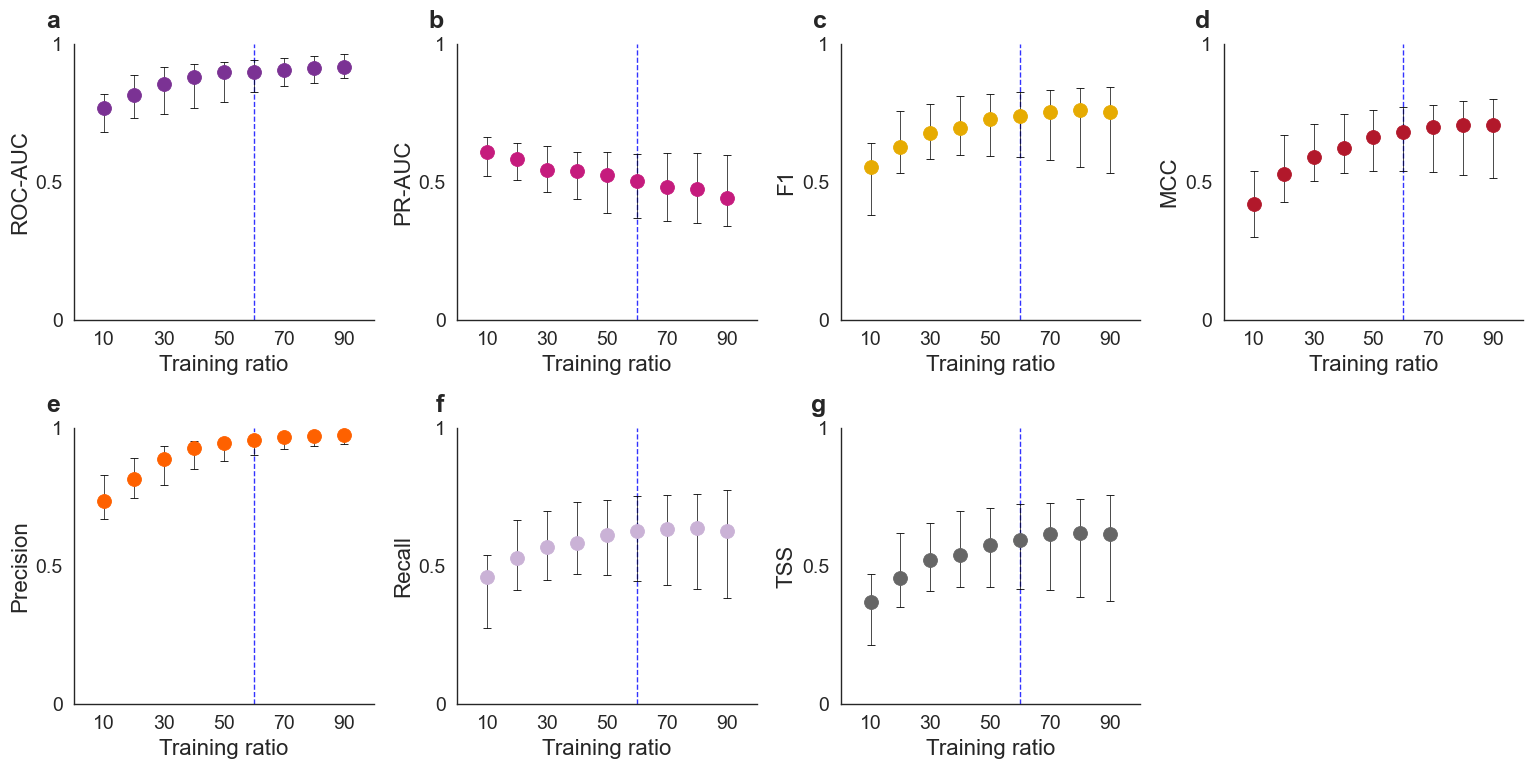

In [43]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_context("paper", font_scale=1.35)
sns.set_style("white")

# =========================
# Locate repo root
# =========================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# =========================
# Configuration
# =========================
RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

RESULTS_DIR = RESULT_DIR / "prediction_scores_logs"

FOODWEB_CSV = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

SINGLE_FILE = None

THRESHOLD_TARGET = 0.5
THRESHOLD_COL = "THRESHOLD"
THRESHOLD_MODE_COL = "THRESHOLDMODE"

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = False
Y_MIN = 0.0

INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",
    "PR-AUC": "#C51B7D",
    "F1": "#E6AB02",
    "MCC": "#B2182B",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "TSS": "#666666",
    "TPR": "#1B9E77",
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_tax_mass_results_random_wlnm_dir_neg",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(str(results_dir), "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []

    for path in paths:
        try:
            df_i = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df_i.columns = [c.strip() for c in df_i.columns]
        df_i = df_i.rename(columns={c: c.upper() for c in df_i.columns})

        if "FOODWEB" not in df_i.columns:
            df_i["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df_i)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    visible_ticks = [10, 30, 50, 70, 90]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels([str(t) for t in visible_ticks])


# =========================
# Load data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

print(f"[INFO] Loaded rows before filtering: {len(df):,}")
print(f"[INFO] Foodwebs before filtering: {df['FOODWEB'].nunique()}")

# =========================
# Filter threshold = 0.5
# =========================
if THRESHOLD_COL not in df.columns:
    raise ValueError(
        f"Column {THRESHOLD_COL} not found. "
        "These do not look like the latest threshold-sweep results."
    )

df[THRESHOLD_COL] = pd.to_numeric(df[THRESHOLD_COL], errors="coerce").round(1)
df = df[df[THRESHOLD_COL] == THRESHOLD_TARGET].copy()

if df.empty:
    raise ValueError(f"No rows found for Threshold == {THRESHOLD_TARGET}")

# Avoid double-counting if both default and threshold_sweep rows exist.
if THRESHOLD_MODE_COL in df.columns:
    threshold_modes = df[THRESHOLD_MODE_COL].astype(str).str.lower()

    if threshold_modes.eq("threshold_sweep").any():
        df = df[threshold_modes.eq("threshold_sweep")].copy()

    if df.empty:
        raise ValueError(f"No threshold_sweep rows found for Threshold == {THRESHOLD_TARGET}")

print(f"[INFO] Applied Threshold filter: Threshold == {THRESHOLD_TARGET}")
print(f"[INFO] Rows after threshold filter: {len(df):,}")
print(f"[INFO] Foodwebs after threshold filter: {df['FOODWEB'].nunique()}")

# =========================
# Load metadata and filter food webs
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None,
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[
    meta[nodes_col] >= NODES_THRESHOLD,
    ["FW_KEY", ecosystem_col],
].copy()

meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before node filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after node filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)

df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].round().astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]

if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long = df_long.dropna(subset=["Value"])

# Mean per food web, train ratio, and metric.
# Each food web contributes one mean value per train ratio and metric.
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Train ratios in plot: {train_ratios}")
print(f"[INFO] Foodwebs used in final plot: {n_webs}")

display(
    summary
    .groupby("Metric")
    .agg(
        MinWebs=("n_webs", "min"),
        MedianWebs=("n_webs", "median"),
        MaxWebs=("n_webs", "max"),
    )
    .reset_index()
)

metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}

# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False,
)

if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[summary["Metric"] == metric].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()

    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    ax.set_title("")
    ax.set_xlabel("Training ratio", fontsize=16)
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=16)

    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

[INFO] Using results_dir: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/prediction_scores_logs
[INFO] CSV files found: 290


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_45789/195672760.py:161: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_i["Foodweb"] = clean_foodweb_name_from_file(file)
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_45789/195672760.py:162: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_i["FW_KEY"] = df_i["Foodweb"].apply(normalize_fw_label)
/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_45789/195672760.py:161: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result o

[INFO] Run-level rows before filtering: 1,174,500
[INFO] Food webs before filtering: 290
[INFO] Applied Threshold filter: kept only Threshold = 0.5.
[INFO] Run-level rows after Threshold filter: 130,500
[INFO] Applied TrainRatio filter: kept only TrainRatio = 90.
[INFO] Run-level rows after TrainRatio filter: 14,500
[INFO] Filtered food webs by size: kept 290 / 290 (>= 0 nodes).

[INFO] Run-level observations after filtering:
Total rows in df_merged: 14,500
Rows per ecosystem:
EcosystemType
lakes                      2750
marine                     6700
streams                    1400
terrestrial aboveground    1050
terrestrial belowground    2600
dtype: int64

[INFO] Web-level observations after averaging repeated runs:
Total web-level rows: 290


,EcosystemType,FoodWebs,TrainRatio,Threshold,MinRunsAveraged,MedianRunsAveraged,MaxRunsAveraged
0,lakes,55,90.0,0.5,50,50.0,50
1,marine,134,90.0,0.5,50,50.0,50
2,streams,28,90.0,0.5,50,50.0,50
3,terrestrial aboveground,21,90.0,0.5,50,50.0,50
4,terrestrial belowground,52,90.0,0.5,50,50.0,50



=== Web-level precision median and variance by ecosystem ===


,EcosystemType,n_foodwebs,Precision_Median,Precision_Variance
0,lakes,55,0.9900,0.003614
1,marine,134,0.9577,0.007624
2,streams,28,0.9839,0.051326
3,terrestrial aboveground,21,0.9364,0.005624
4,terrestrial belowground,52,0.9899,0.000024



=== Ecosystems with lowest/highest median precision and variance ===
Lowest median precision:  terrestrial aboveground (median = 0.9364, variance = 0.005624, n_foodwebs = 21)
Highest median precision: lakes (median = 0.99, variance = 0.003614, n_foodwebs = 55)
Lowest variance:          terrestrial belowground (variance = 2.4e-05, median = 0.9899, n_foodwebs = 52)
Highest variance:         streams (variance = 0.051326, median = 0.9839, n_foodwebs = 28)
[INFO] Saved figure: /Users/acw792/Developer/qmul-phd-framework/src/matlab/data/result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita/statistical_tests/athen/figures/predictive_metrics_wlnm_dir_neg_train90_threshold0p5_by_ecosystem_web_level.png


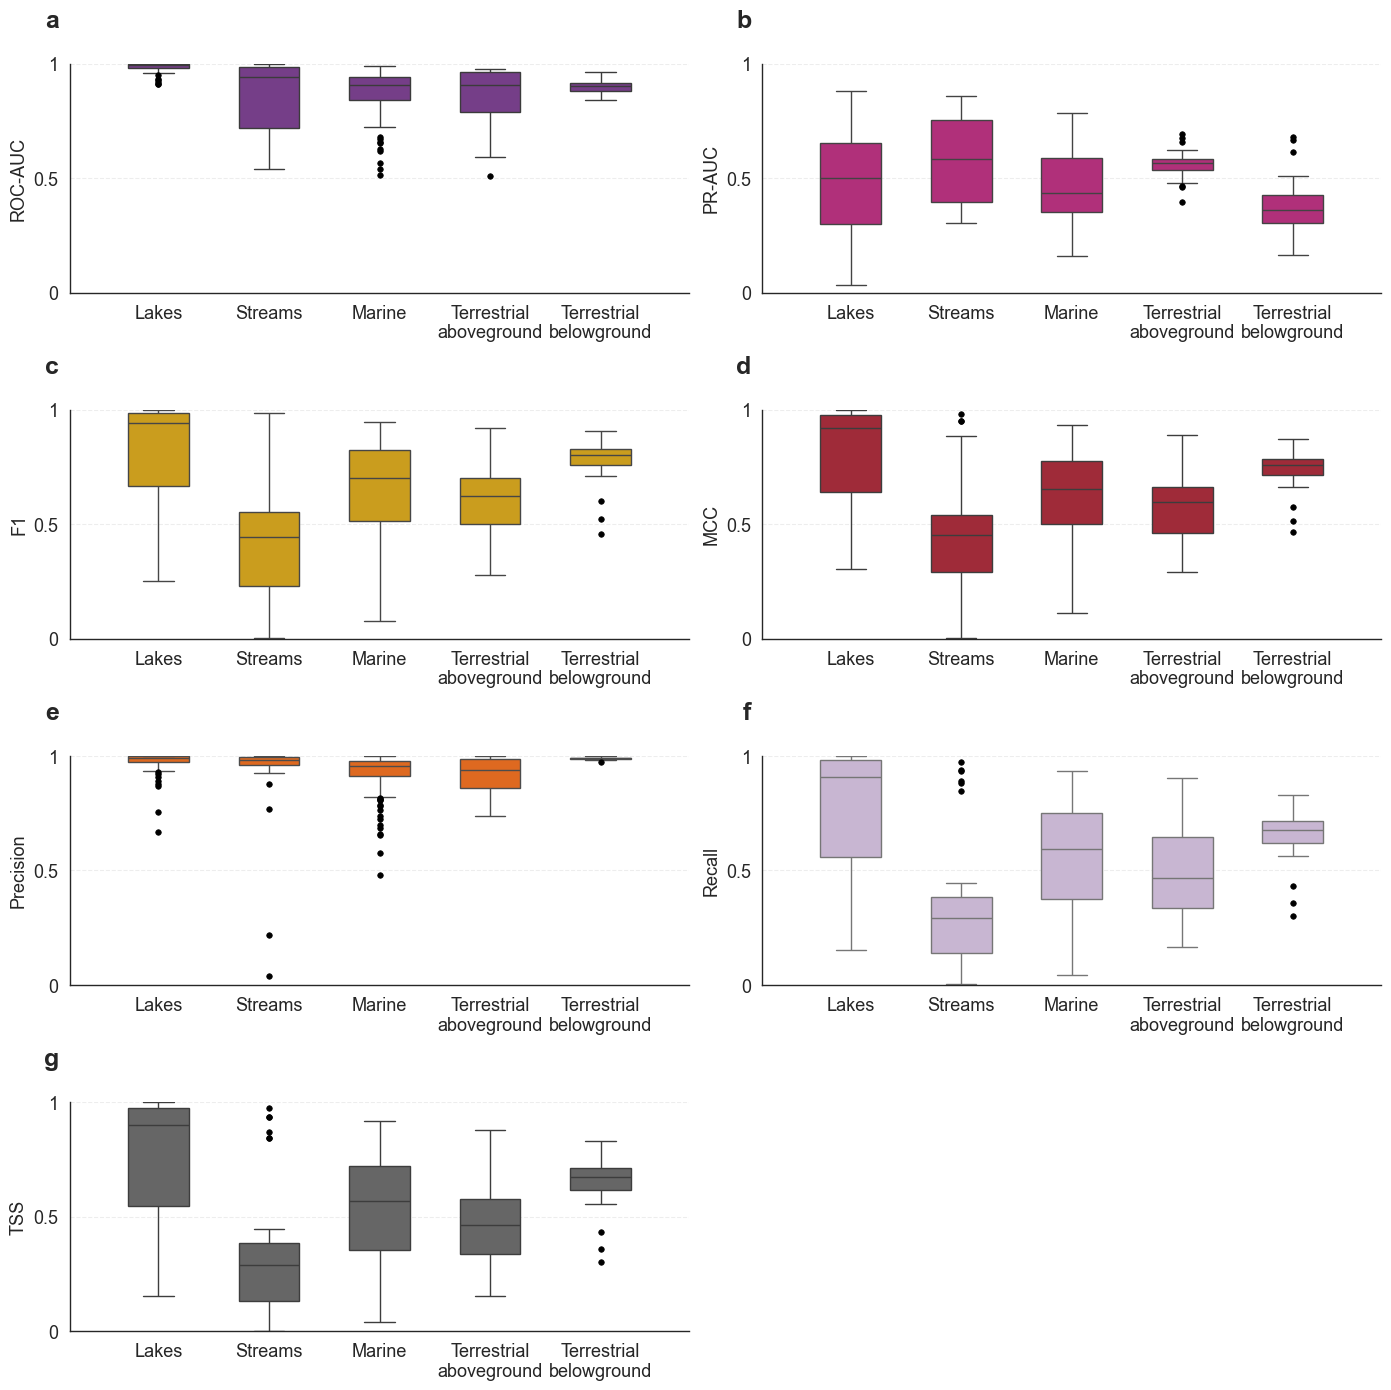

In [44]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_context("paper")
sns.set_style("white")

# ============================================================
# Locate repo root
# ============================================================
def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "src/matlab").exists() and (p / "docs").exists():
            return p
    raise RuntimeError(f"Could not locate repo root from {start}")


REPO_ROOT = find_repo_root()

# ============================================================
# Config
# ============================================================
RESULT_DIR = (
    REPO_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

results_dir = RESULT_DIR / "prediction_scores_logs"

ecosystem_file = REPO_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

OUT_DIR = RESULT_DIR / "statistical_tests/athen/figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

THRESHOLD_TARGET = 0.5
THRESHOLD_COL = "Threshold"
THRESHOLD_MODE_COL = "ThresholdMode"

OUT_PATH = (
    OUT_DIR
    / f"predictive_metrics_wlnm_dir_neg_train{TRAIN_RATIO_TARGET}_threshold0p5_by_ecosystem_web_level.png"
)

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "F1Score", "TestMCC", "Precision", "Recall", "TestTSS"]
xtick_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC", "Precision", "Recall", "TSS"]

SHOW_WEB_LEVEL_FLIERS = True

metric_palette = {
    "ROC_AUC": "#7B3294",
    "PR_AUC": "#C51B7D",
    "Precision": "#FE6100",
    "Recall": "#CAB2D6",
    "F1Score": "#E6AB02",
    "TestMCC": "#B2182B",
    "TestTSS": "#666666",
    "TestTPR": "#1B9E77",
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "TestMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "TestTSS": "TSS",
    "TestTPR": "TPR",
}

# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")

    for token in [
        "_tax_mass_results_random_wlnm_dir_neg",
        "_results_random_wlnm_dir_neg",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(part for part in name.split("_") if part)


def clean_foodweb_name_from_file(file_path: str) -> str:
    name = os.path.basename(file_path)
    name = name.replace("_results_random_wlnm_dir_neg.csv", "")
    name = name.removesuffix("_tax_mass")
    return name


# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ecosystem_file)
df_ecosystem.columns = [c.strip() for c in df_ecosystem.columns]

norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}

fw_col = next((norm_map[k] for k in ["foodweb", "foodwebname"] if k in norm_map), None)
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)
ecosystem_col = next(
    (
        norm_map[k]
        for k in ["ecosystem", "ecosystemtype", "ecosystem_type"]
        if k in norm_map
    ),
    None,
)

if fw_col is None or node_col is None or ecosystem_col is None:
    raise RuntimeError(
        "Could not find Foodweb, node-count, and ecosystem columns in ecosystem metadata."
    )

df_ecosystem["FW_KEY"] = df_ecosystem[fw_col].apply(normalize_fw_label)

# ============================================================
# Load result CSVs
# ============================================================
csv_files = sorted(glob.glob(os.path.join(str(results_dir), "*_tax_mass_results_random_wlnm_dir_neg.csv")))

print(f"[INFO] Using results_dir: {results_dir}")
print(f"[INFO] CSV files found: {len(csv_files)}")

dfs = []

for file in csv_files:
    df_i = pd.read_csv(file)
    df_i["Foodweb"] = clean_foodweb_name_from_file(file)
    df_i["FW_KEY"] = df_i["Foodweb"].apply(normalize_fw_label)
    dfs.append(df_i)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

print(f"[INFO] Run-level rows before filtering: {len(df_all):,}")
print(f"[INFO] Food webs before filtering: {df_all['Foodweb'].nunique()}")

# ============================================================
# Filter Threshold = 0.5
# ============================================================
if THRESHOLD_COL not in df_all.columns:
    raise RuntimeError(
        f"Column '{THRESHOLD_COL}' not found. "
        "These do not look like the latest threshold-sweep results."
    )

df_all[THRESHOLD_COL] = pd.to_numeric(df_all[THRESHOLD_COL], errors="coerce").round(1)
df_all = df_all[df_all[THRESHOLD_COL] == THRESHOLD_TARGET].copy()

if df_all.empty:
    raise RuntimeError(f"No rows found for {THRESHOLD_COL} = {THRESHOLD_TARGET}.")

# Avoid double-counting if both default and threshold_sweep rows exist.
if THRESHOLD_MODE_COL in df_all.columns:
    threshold_modes = df_all[THRESHOLD_MODE_COL].astype(str).str.lower()

    if threshold_modes.eq("threshold_sweep").any():
        df_all = df_all[threshold_modes.eq("threshold_sweep")].copy()

    if df_all.empty:
        raise RuntimeError(f"No threshold_sweep rows found for {THRESHOLD_COL} = {THRESHOLD_TARGET}.")

print(f"[INFO] Applied Threshold filter: kept only {THRESHOLD_COL} = {THRESHOLD_TARGET}.")
print(f"[INFO] Run-level rows after Threshold filter: {len(df_all):,}")

# ============================================================
# Filter TrainRatio
# ============================================================
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

for metric in METRIC_ORDER:
    if metric in df_all.columns:
        df_all[metric] = pd.to_numeric(df_all[metric], errors="coerce")
    else:
        raise RuntimeError(f"Metric column '{metric}' not found in result CSVs.")

print(f"[INFO] Applied TrainRatio filter: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")
print(f"[INFO] Run-level rows after TrainRatio filter: {len(df_all):,}")

# ============================================================
# Merge metrics with ecosystem metadata
# ============================================================
df_meta = df_ecosystem[["FW_KEY", fw_col, ecosystem_col, node_col]].copy()
df_meta = df_meta.rename(
    columns={
        fw_col: "FoodwebMetadata",
        ecosystem_col: "EcosystemType",
    }
)

df_merged = pd.merge(
    df_all,
    df_meta,
    on="FW_KEY",
    how="left",
)

missing_ecosystem = df_merged["EcosystemType"].isna().sum()
if missing_ecosystem:
    print(f"[WARNING] Rows without ecosystem metadata: {missing_ecosystem:,}")

# ============================================================
# Apply node-count filter
# ============================================================
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"[INFO] Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

if df_merged.empty:
    raise ValueError(f"No food webs left after filtering Nodes >= {MIN_NODES}.")

print("\n[INFO] Run-level observations after filtering:")
print(f"Total rows in df_merged: {len(df_merged):,}")
print("Rows per ecosystem:")
print(df_merged.groupby("EcosystemType").size())

# ============================================================
# Web-level aggregation
# ============================================================
# Each food web contributes one observation per metric.
# Repeated WLNM runs are averaged before plotting.
agg_dict = {metric: "mean" for metric in METRIC_ORDER}
agg_dict.update({
    "Iteration": "count",
    node_col: "first",
    THRESHOLD_COL: "median",
    TRAIN_RATIO_COL: "median",
})

df_web = (
    df_merged
    .groupby(["Foodweb", "EcosystemType"], as_index=False)
    .agg(agg_dict)
    .rename(columns={"Iteration": "RunsAveraged"})
)

print("\n[INFO] Web-level observations after averaging repeated runs:")
print(f"Total web-level rows: {len(df_web):,}")

display(
    df_web
    .groupby("EcosystemType")
    .agg(
        FoodWebs=("Foodweb", "nunique"),
        TrainRatio=(TRAIN_RATIO_COL, "median"),
        Threshold=(THRESHOLD_COL, "median"),
        MinRunsAveraged=("RunsAveraged", "min"),
        MedianRunsAveraged=("RunsAveraged", "median"),
        MaxRunsAveraged=("RunsAveraged", "max"),
    )
    .reset_index()
)

# ============================================================
# Precision summary by ecosystem, web-level
# ============================================================
precision_summary = (
    df_web
    .dropna(subset=["EcosystemType", "Precision"])
    .groupby("EcosystemType", as_index=False)
    .agg(
        n_foodwebs=("Foodweb", "nunique"),
        Precision_Median=("Precision", "median"),
        Precision_Variance=("Precision", lambda x: x.var(ddof=1)),
    )
)

precision_summary["Precision_Median"] = precision_summary["Precision_Median"].round(4)
precision_summary["Precision_Variance"] = precision_summary["Precision_Variance"].round(6)

print("\n=== Web-level precision median and variance by ecosystem ===")
display(precision_summary)

lowest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmin()]
highest_precision = precision_summary.loc[precision_summary["Precision_Median"].idxmax()]
lowest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmin()]
highest_variance = precision_summary.loc[precision_summary["Precision_Variance"].idxmax()]

print("\n=== Ecosystems with lowest/highest median precision and variance ===")
print(
    f"Lowest median precision:  {lowest_precision['EcosystemType']} "
    f"(median = {lowest_precision['Precision_Median']}, "
    f"variance = {lowest_precision['Precision_Variance']}, "
    f"n_foodwebs = {lowest_precision['n_foodwebs']})"
)
print(
    f"Highest median precision: {highest_precision['EcosystemType']} "
    f"(median = {highest_precision['Precision_Median']}, "
    f"variance = {highest_precision['Precision_Variance']}, "
    f"n_foodwebs = {highest_precision['n_foodwebs']})"
)
print(
    f"Lowest variance:          {lowest_variance['EcosystemType']} "
    f"(variance = {lowest_variance['Precision_Variance']}, "
    f"median = {lowest_variance['Precision_Median']}, "
    f"n_foodwebs = {lowest_variance['n_foodwebs']})"
)
print(
    f"Highest variance:         {highest_variance['EcosystemType']} "
    f"(variance = {highest_variance['Precision_Variance']}, "
    f"median = {highest_variance['Precision_Median']}, "
    f"n_foodwebs = {highest_variance['n_foodwebs']})"
)

# ============================================================
# Prepare long-format web-level data
# ============================================================
df_plot = df_web.melt(
    id_vars=["Foodweb", "EcosystemType", "RunsAveraged"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value",
)

# ============================================================
# Preferred ecosystem order
# ============================================================
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_web["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# ============================================================
# Labels
# ============================================================
labels_map = (
    df_web[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)

def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    return label_replacements.get(eco_lower, eco_clean.capitalize())

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

subset = df_plot.copy()
subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True,
)

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 14),
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        width=0.55,
        showfliers=SHOW_WEB_LEVEL_FLIERS,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1,
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)
    ax.set_ylim(0, 1.0)
    ax.grid(False, axis="x")

    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)

fig.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print(f"[INFO] Saved figure: {OUT_PATH}")

plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] Threshold = 0.5: 290 -> 290 food webs
[CHECK] ThresholdMode = threshold_sweep: 290 -> 290 food webs
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[FINAL] Food webs retained after structural filters: 290
[FINAL] Threshold retained: 0.5
[FINAL] TrainRatio retained: 90.0

=== OLS linear regression: metric ~ empirical connectance ===
a) ROC-AUC: y = 0.4914x + 0.8300; F1,288 = 15.3406; R2 = 0.0506; P = 0.0001; n = 290
b) PR-AUC: y = 1.4209x + 0.2815; F1,288 = 54.7724; R2 = 0.1598; P < 0.0001; n = 290
c) F1: y = 0.1629x + 0.6640; F1,288 = 0.3319; R2 = 0.0012; P = 0.5650; n = 290
d) MCC: y = 0.0389x + 0.6558; F1,288 = 0.0221; R2 = 0.0001; P = 0.8819; n = 290
e) Precision: y = -0.0430x + 0.9484; F1,288 = 0.1172; R2 = 0.000

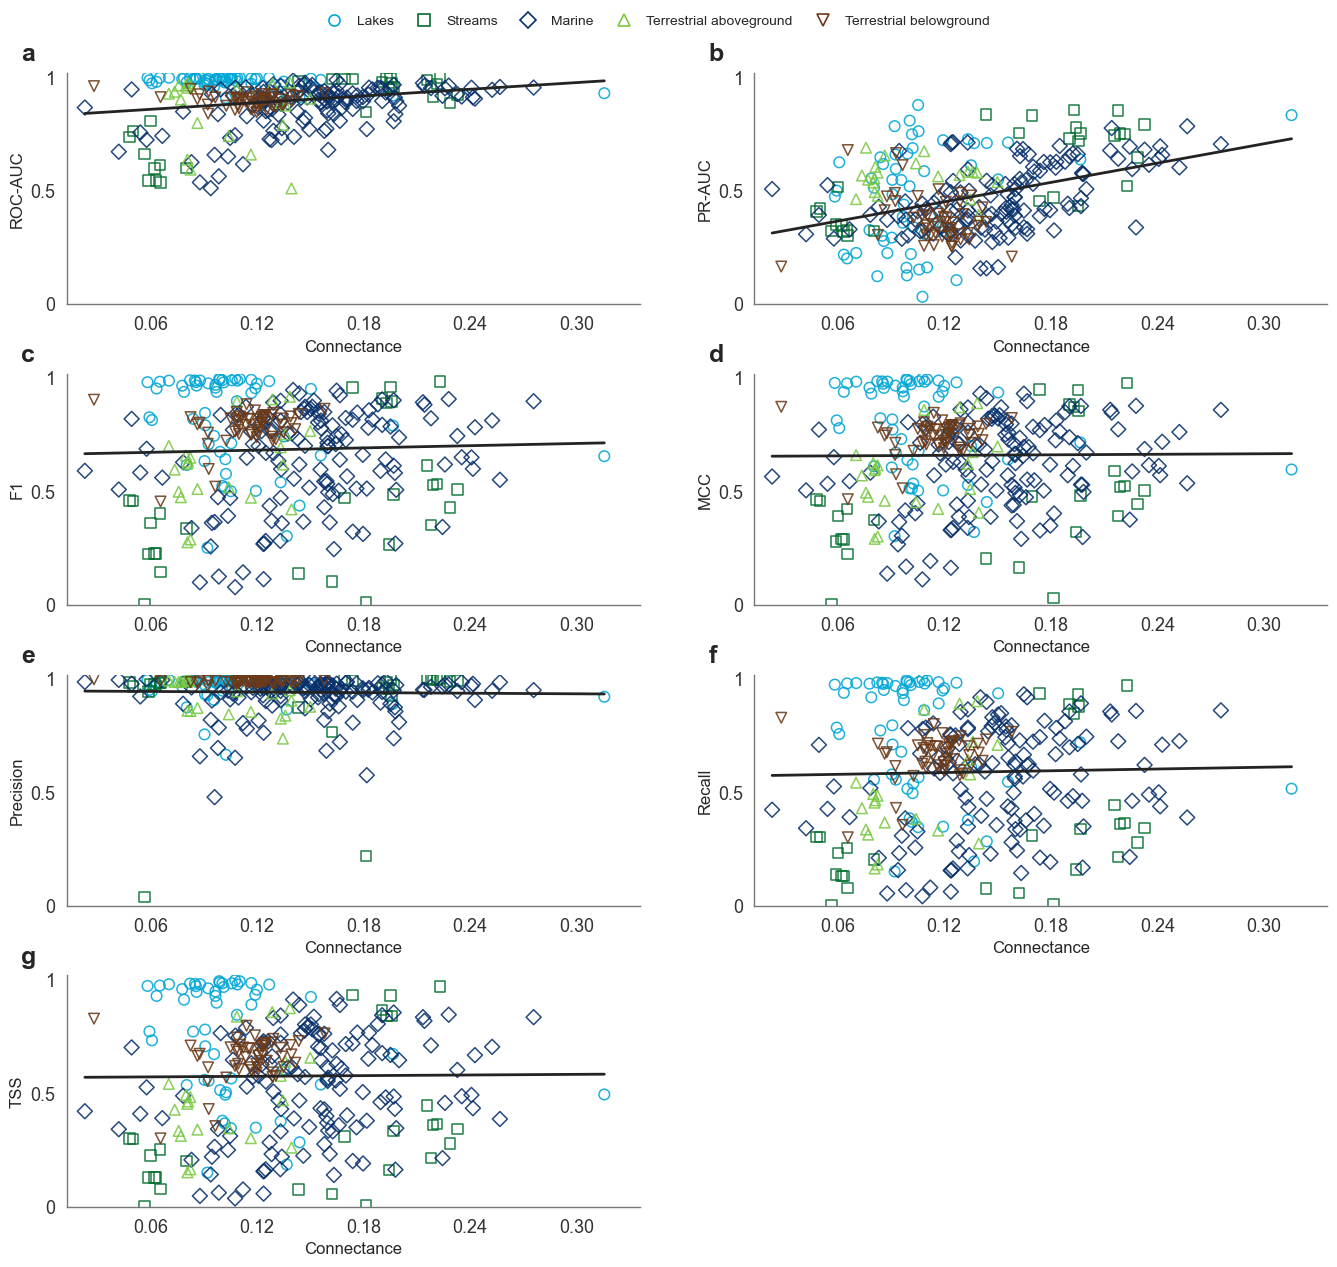

In [45]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_ROOT = (
    PROJECT_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

RESULTS_DIR = RESULTS_ROOT / "prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
THRESHOLD_TARGET = 0.5
THRESHOLD_COL = "Threshold"
THRESHOLD_MODE_COL = "ThresholdMode"

MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")

    for token in [
        "_results_random_wlnm_dir_neg",
        "_tax_mass_results_random_wlnm_dir_neg",
        "_results_",
        "_result_",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        s = s.replace(token, "_")

    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    name = Path(filepath).name
    name = name.replace("_results_random_wlnm_dir_neg.csv", "")
    name = name.removesuffix("_tax_mass")
    return name


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Data loading
# ============================================================

def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))

    if not files:
        raise FileNotFoundError(
            f"No result CSV files found in {results_dir} matching {pattern}"
        )

    frames = []

    for path in files:
        df = pd.read_csv(path).copy()

        foodweb = extract_foodweb_name(path)
        foodweb_key = normalize_foodweb_name(foodweb)

        file_meta = pd.DataFrame(
            {
                "Foodweb": foodweb,
                "FoodwebKey": foodweb_key,
            },
            index=df.index,
        )

        df = pd.concat([df, file_meta], axis=1).copy()
        frames.append(df)

    out = pd.concat(frames, ignore_index=True).copy()

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path).copy()

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[
        [
            "MetadataFoodweb",
            "EcosystemType",
            "Nodes",
            "Edges",
            "MetadataConnectance",
        ]
    ].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(
        meta["MetadataConnectance"],
        errors="coerce",
    )

    meta = meta.drop_duplicates(subset=["FoodwebKey"]).copy()

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


# ============================================================
# Data preparation
# ============================================================

def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="FoodwebKey", how="left").copy()

    rename_map = {}

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        rename_map["AUC"] = "ROC_AUC"

    if "TestMCC" not in df.columns and "MCC" in df.columns:
        rename_map["MCC"] = "TestMCC"

    if rename_map:
        df = df.rename(columns=rename_map).copy()

    numeric_cols = [
        "K",
        "TrainRatio",
        THRESHOLD_COL,
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "TestTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

    if existing_numeric_cols:
        df[existing_numeric_cols] = df[existing_numeric_cols].apply(
            pd.to_numeric,
            errors="coerce",
        )

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    if THRESHOLD_COL not in df.columns:
        raise RuntimeError(
            f"Column '{THRESHOLD_COL}' not found. "
            "These do not look like the latest threshold-sweep results."
        )

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])
    df[THRESHOLD_COL] = pd.to_numeric(df[THRESHOLD_COL], errors="coerce").round(1)

    before = set(df["Foodweb"].dropna().unique())

    df = df[df[THRESHOLD_COL] == THRESHOLD_TARGET].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Threshold = {THRESHOLD_TARGET}", before, after)
    before = after

    if THRESHOLD_MODE_COL in df.columns:
        threshold_modes = df[THRESHOLD_MODE_COL].astype(str).str.lower()

        if threshold_modes.eq("threshold_sweep").any():
            df = df[threshold_modes.eq("threshold_sweep")].copy()
            after = set(df["Foodweb"].dropna().unique())
            report_foodweb_count("ThresholdMode = threshold_sweep", before, after)
            before = after

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )

    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (
            df.loc[can_compute_conn, "Nodes"]
            * (df.loc[can_compute_conn, "Nodes"] - 1)
        )
    )

    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_count(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"TrainRatio = {TARGET_RATIO}", before, after)
    before = after

    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_count(f"Nodes >= {MIN_NODES}", before, after)

    missing_metrics = [
        metric
        for metric, _ in METRIC_SPECS
        if metric not in df.columns
    ]

    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            THRESHOLD_COL,
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]

        mean_cols = [metric for metric, _ in METRIC_SPECS]

        df = (
            df.groupby(group_cols, dropna=False, as_index=False)[mean_cols]
            .mean()
            .copy()
        )

    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"]).copy()
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_count("available connectance for x-axis", df_before_x, df_after_x)

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    metric_availability = (
        df[["Foodweb", *metric_cols]]
        .assign(HasAnySelectedMetric=lambda x: x[metric_cols].notna().any(axis=1))
        .copy()
    )

    foodwebs_without_metrics = (
        metric_availability.loc[
            ~metric_availability["HasAnySelectedMetric"],
            "Foodweb",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    print(f"[FINAL] Food webs retained after structural filters: {df['Foodweb'].nunique()}")
    print(f"[FINAL] Threshold retained: {THRESHOLD_TARGET}")
    print(f"[FINAL] TrainRatio retained: {TARGET_RATIO}")

    if foodwebs_without_metrics:
        print(
            "[INFO] Food webs retained but not plotted in metric panels "
            "because all selected metrics are missing:"
        )
        for fw in foodwebs_without_metrics:
            print(f"  - {fw}")

    return df.copy()


# ============================================================
# Regression helpers
# ============================================================

def fit_linear_regression(data: pd.DataFrame, metric: str, n_points: int = 100):
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return None

    work["EmpiricalConnectanceForPlot"] = work["EmpiricalConnectanceForPlot"].astype(float)
    work[metric] = work[metric].astype(float)

    if len(work) < 3 or work["EmpiricalConnectanceForPlot"].nunique() < 2:
        return None

    x = work[["EmpiricalConnectanceForPlot"]]
    y = work[metric]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params["EmpiricalConnectanceForPlot"]

    x_line = np.linspace(
        work["EmpiricalConnectanceForPlot"].min(),
        work["EmpiricalConnectanceForPlot"].max(),
        n_points,
    )

    x_line_model = pd.DataFrame(
        {"EmpiricalConnectanceForPlot": x_line}
    )
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "slope": slope,
        "intercept": intercept,
        "r_squared": model.rsquared,
        "p_value": model.pvalues["EmpiricalConnectanceForPlot"],
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "n": len(work),
        "model": model,
    }


def format_equation(slope: float, intercept: float) -> str:
    sign = "+" if intercept >= 0 else "-"
    return f"y = {slope:.4f}x {sign} {abs(intercept):.4f}"


def format_p_value(p_value: float) -> str:
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


# ============================================================
# Plotting
# ============================================================

def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Connectance", fontsize=12)
    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")

    ax.tick_params(axis="both", colors="#333333", labelsize=13)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    available_ecosystems = (
        plot_df["EcosystemType"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    available_by_label = {
        format_ecosystem_label(eco): eco
        for eco in available_ecosystems
    }

    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    eco_order += [
        eco
        for eco in available_ecosystems
        if eco not in eco_order
    ]

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(14, 14),
        sharex=False,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    x_min = plot_df["EmpiricalConnectanceForPlot"].min()
    x_max = plot_df["EmpiricalConnectanceForPlot"].max()

    print("\n=== OLS linear regression: metric ~ empirical connectance ===")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric]).copy()

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]

            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        fit = fit_linear_regression(data, metric)

        if fit is not None:
            ax.plot(
                fit["x_line"],
                fit["y_line"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

            equation = format_equation(fit["slope"], fit["intercept"])
            p_text = format_p_value(fit["p_value"])

            print(
                f"{panel_letters[i]}) {label}: "
                f"{equation}; "
                f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
                f"R2 = {fit['r_squared']:.4f}; "
                f"{p_text}; "
                f"n = {fit['n']}"
            )

        else:
            print(
                f"{panel_letters[i]}) {label}: "
                "regression not fitted; insufficient data."
            )

        style_axes(ax, label)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)

        ax.set_xlim(
            max(0.0, x_min - 0.01),
            x_max + 0.02,
        )

        ax.set_yticks([0, 0.5, 1.0])
        ax.set_yticklabels(["0", "0.5", "1"])

        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================

results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Run-level rows before filtering: 1,174,500
[CHECK] Threshold = 0.5: 290 -> 290 food webs
[CHECK] ThresholdMode = threshold_sweep: 290 -> 290 food webs
Filtered data: Threshold = 0.5, TrainRatio = 90.0, Nodes >= 0. Rows kept: 14500 / 130500. Food webs kept: 290 / 290.
[INFO] Web-level food webs retained: 290
[INFO] Threshold retained: 0.5
[INFO] TrainRatio retained: 90.0


,EcosystemType,FoodWebs,MedianNodes
0,lakes,55,37.0
1,marine,134,28.0
2,streams,28,83.5
3,terrestrial aboveground,21,97.0
4,terrestrial belowground,52,122.5



=== OLS linear regression: metric ~ number of nodes ===
a) ROC-AUC: y = 0.927643 - 0.000504x; F1,288 = 28.8664; R2 = 0.0911; P < 0.0001; n = 290
b) PR-AUC: y = 0.495903 - 0.000407x; F1,288 = 6.6093; R2 = 0.0224; P = 0.0106; n = 290
c) F1: y = 0.718319 - 0.000508x; F1,288 = 5.6138; R2 = 0.0191; P = 0.0185; n = 290
d) MCC: y = 0.691332 - 0.000471x; F1,288 = 5.6315; R2 = 0.0192; P = 0.0183; n = 290
e) Precision: y = 0.921383 + 0.000330x; F1,288 = 12.3397; R2 = 0.0411; P = 0.0005; n = 290
f) Recall: y = 0.647934 - 0.000897x; F1,288 = 14.4445; R2 = 0.0478; P = 0.0002; n = 290
g) TSS: y = 0.626925 - 0.000782x; F1,288 = 11.0585; R2 = 0.0370; P = 0.0010; n = 290


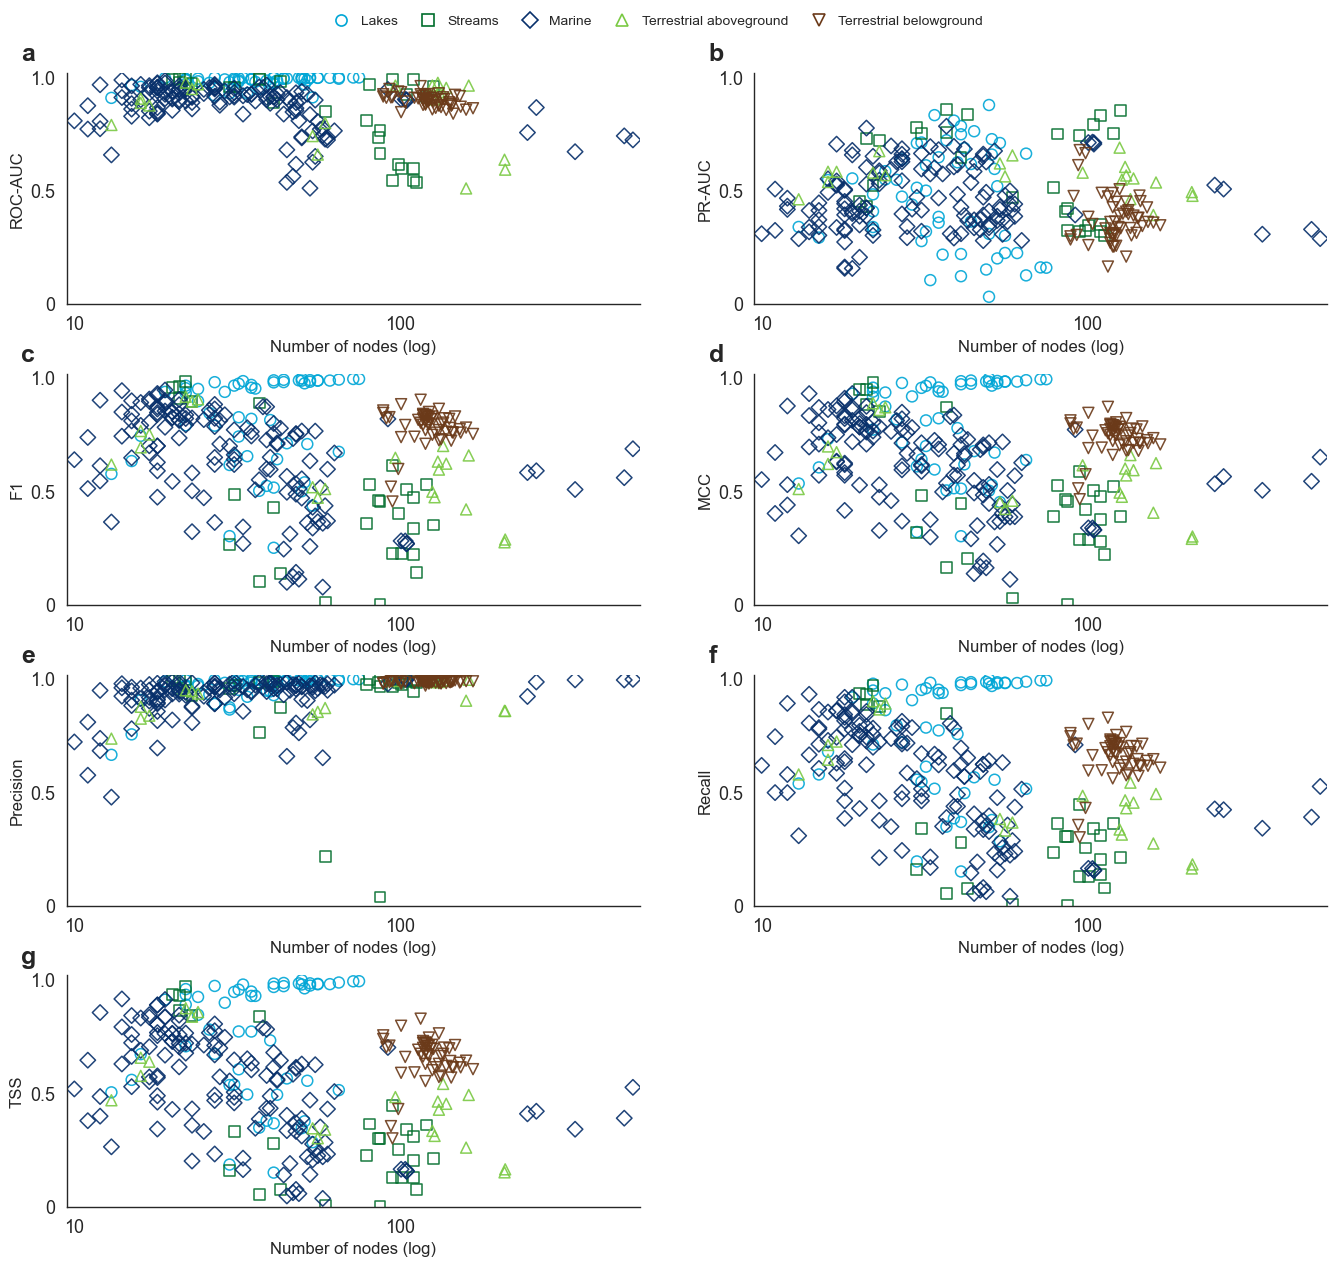

In [46]:
import os
import glob
import math
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()

    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path

    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_ROOT = (
    PROJECT_ROOT
    / "src/matlab/data"
    / "result_wlnm_dir_neg_50x290_train10-90_thresh10-90_masspref_trainmetrics_Apocrita"
)

RESULTS_DIR = RESULTS_ROOT / "prediction_scores_logs"
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
THRESHOLD_TARGET = 0.5
THRESHOLD_COL = "Threshold"
THRESHOLD_MODE_COL = "ThresholdMode"

MIN_NODES = 0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",
    "Streams": "#006D2C",
    "Marine": "#08306B",
    "Terrestrial aboveground": "#7AC943",
    "Terrestrial belowground": "#6B3A19",
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02
X_MAX = 550
N_COLS = 2


# ============================================================
# Helpers
# ============================================================

def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")

    for token in [
        "_results_random_wlnm_dir_neg",
        "_tax_mass_results_random_wlnm_dir_neg",
        "_results_",
        "_result_",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        s = s.replace(token, "_")

    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    name = Path(filepath).name
    name = name.replace("_results_random_wlnm_dir_neg.csv", "")
    name = name.removesuffix("_tax_mass")
    return name


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()

    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }

    return label_map.get(name, str(name).strip().capitalize())


def format_p_value(p_value: float) -> str:
    if pd.isna(p_value):
        return "P = NA"
    if p_value < 0.0001:
        return "P < 0.0001"
    return f"P = {p_value:.4f}"


def format_equation(intercept: float, slope: float) -> str:
    sign = "+" if slope >= 0 else "-"
    return f"y = {intercept:.6f} {sign} {abs(slope):.6f}x"


def report_foodweb_count(stage_name: str, before: set, after: set) -> None:
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")


# ============================================================
# Regression helper
# ============================================================

def fit_linear_regression(
    data: pd.DataFrame,
    x_col: str,
    y_col: str,
    n_points: int = 100,
):
    work = data[[x_col, y_col]].dropna().copy()

    if work.empty:
        return None

    work[x_col] = work[x_col].astype(float)
    work[y_col] = work[y_col].astype(float)

    if len(work) < 3 or work[x_col].nunique() < 2:
        return None

    x = work[[x_col]]
    y = work[y_col]

    x_model = sm.add_constant(x, has_constant="add")
    model = sm.OLS(y, x_model).fit()

    intercept = model.params["const"]
    slope = model.params[x_col]

    x_line = np.linspace(
        work[x_col].min(),
        work[x_col].max(),
        n_points,
    )

    x_line_model = pd.DataFrame({x_col: x_line})
    x_line_model = sm.add_constant(x_line_model, has_constant="add")
    y_line = model.predict(x_line_model)

    return {
        "x_line": x_line,
        "y_line": y_line,
        "intercept": intercept,
        "slope": slope,
        "f_value": model.fvalue,
        "df_model": int(model.df_model),
        "df_resid": int(model.df_resid),
        "p_value": model.pvalues[x_col],
        "r_squared": model.rsquared,
        "n": len(work),
        "model": model,
    }


# ============================================================
# Load ecosystem metadata
# ============================================================

df_ecosystem = pd.read_csv(ECOSYSTEM_FILE).copy()

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(
    df_ecosystem,
    ["ecosystemtype", "ecosystem", "ecosystem_type"],
)
nodes_col = find_column(
    df_ecosystem,
    ["nodes", "n_nodes", "num_nodes", "nodecount", "s"],
)

df_ecosystem = df_ecosystem.rename(
    columns={
        foodweb_col: "MetadataFoodweb",
        ecosystem_col: "EcosystemType",
        nodes_col: "Nodes",
    }
)

df_ecosystem = df_ecosystem[
    [
        "MetadataFoodweb",
        "EcosystemType",
        "Nodes",
    ]
].copy()

df_ecosystem["MetadataFoodweb"] = df_ecosystem["MetadataFoodweb"].astype(str)
df_ecosystem["FoodwebKey"] = df_ecosystem["MetadataFoodweb"].apply(
    normalize_foodweb_name
)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

df_ecosystem = df_ecosystem.drop_duplicates(subset=["FoodwebKey"]).copy()


# ============================================================
# Load results
# ============================================================

csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))

if not csv_files:
    raise RuntimeError(
        f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}"
    )

frames = []

for file in csv_files:
    df = pd.read_csv(file).copy()

    foodweb = extract_foodweb_name(file)
    foodweb_key = normalize_foodweb_name(foodweb)

    file_meta = pd.DataFrame(
        {
            "Foodweb": foodweb,
            "FoodwebKey": foodweb_key,
        },
        index=df.index,
    )

    df = pd.concat([df, file_meta], axis=1).copy()
    frames.append(df)

df_all = pd.concat(frames, ignore_index=True).copy()

print(f"[INFO] Result files found: {len(csv_files)}")
print(f"[INFO] Food webs in result files before filtering: {df_all['Foodweb'].nunique()}")
print(f"[INFO] Run-level rows before filtering: {len(df_all):,}")

if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"}).copy()

if "TestMCC" not in df_all.columns and "MCC" in df_all.columns:
    df_all = df_all.rename(columns={"MCC": "TestMCC"}).copy()

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]

if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")


# ============================================================
# Merge + filter
# ============================================================

df_merged = df_all.merge(
    df_ecosystem[["FoodwebKey", "EcosystemType", "Nodes"]],
    on="FoodwebKey",
    how="left",
).copy()

if "TrainRatio" not in df_merged.columns:
    raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

if THRESHOLD_COL not in df_merged.columns:
    raise RuntimeError(
        f"Column '{THRESHOLD_COL}' not found. "
        "These do not look like the latest threshold-sweep results."
    )

df_merged["TrainRatio"] = normalize_train_ratio(df_merged["TrainRatio"])
df_merged[THRESHOLD_COL] = pd.to_numeric(df_merged[THRESHOLD_COL], errors="coerce").round(1)
df_merged["Nodes"] = pd.to_numeric(df_merged["Nodes"], errors="coerce")
df_merged["EcosystemType"] = df_merged["EcosystemType"].fillna("Unknown")

numeric_cols = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "TestMCC",
    "Precision",
    "Recall",
    "TestTSS",
    "TestTPR",
]

for col in numeric_cols:
    if col in df_merged.columns:
        df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

before = set(df_merged["Foodweb"].dropna().unique())

df_merged = df_merged[df_merged[THRESHOLD_COL] == THRESHOLD_TARGET].copy()
after = set(df_merged["Foodweb"].dropna().unique())
report_foodweb_count(f"Threshold = {THRESHOLD_TARGET}", before, after)
before = after

if THRESHOLD_MODE_COL in df_merged.columns:
    threshold_modes = df_merged[THRESHOLD_MODE_COL].astype(str).str.lower()

    if threshold_modes.eq("threshold_sweep").any():
        df_merged = df_merged[threshold_modes.eq("threshold_sweep")].copy()
        after = set(df_merged["Foodweb"].dropna().unique())
        report_foodweb_count("ThresholdMode = threshold_sweep", before, after)
        before = after

before_rows = len(df_merged)
before_foodwebs = df_merged["Foodweb"].nunique()

df_tr = df_merged[
    np.isclose(df_merged["TrainRatio"], TARGET_RATIO, equal_nan=False)
    & (df_merged["Nodes"] >= MIN_NODES)
].copy()

after_rows = len(df_tr)
after_foodwebs = df_tr["Foodweb"].nunique()

print(
    f"Filtered data: Threshold = {THRESHOLD_TARGET}, "
    f"TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: {after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        f"No rows left after filtering Threshold = {THRESHOLD_TARGET}, "
        f"TrainRatio = {TARGET_RATIO}, and Nodes >= {MIN_NODES}."
    )


# ============================================================
# Mean per food web
# ============================================================

agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}
agg_dict.update({
    THRESHOLD_COL: "median",
    "TrainRatio": "median",
})

df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
    .copy()
)

df_scatter = df_scatter.dropna(subset=["Nodes"]).copy()

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

print(f"[INFO] Web-level food webs retained: {df_scatter['Foodweb'].nunique()}")
print(f"[INFO] Threshold retained: {df_scatter[THRESHOLD_COL].median()}")
print(f"[INFO] TrainRatio retained: {df_scatter['TrainRatio'].median()}")

display(
    df_scatter
    .groupby("EcosystemType")
    .agg(
        FoodWebs=("Foodweb", "nunique"),
        MedianNodes=("Nodes", "median"),
    )
    .reset_index()
)

x_min = max(1, df_scatter["Nodes"].min() * 0.95)
x_max = min(X_MAX, df_scatter["Nodes"].max() * 1.05)


# ============================================================
# Ecosystem order + palette
# ============================================================

available_ecosystems = (
    df_scatter["EcosystemType"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

available_by_label = {
    format_ecosystem_label(eco): eco
    for eco in available_ecosystems
}

eco_order = [
    available_by_label[label]
    for label in ECOSYSTEM_ORDER
    if label in available_by_label
]

eco_order += [
    eco
    for eco in available_ecosystems
    if eco not in eco_order
]

df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True,
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

eco_markers = {
    eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
    for eco in eco_order
}


# ============================================================
# Plot
# ============================================================

n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows,
    N_COLS,
    figsize=(14, 14),
    sharex=False,
    sharey=False,
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

print("\n=== OLS linear regression: metric ~ number of nodes ===")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    data = df_scatter.dropna(subset=["Nodes", metric_col]).copy()

    for eco in eco_order:
        sub = data[data["EcosystemType"] == eco]

        if sub.empty:
            continue

        ax.scatter(
            sub["Nodes"],
            sub[metric_col],
            marker=eco_markers[eco],
            facecolors="none",
            edgecolors=eco_palette[eco],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(eco),
        )

    fit = fit_linear_regression(data, "Nodes", metric_col)

    if fit is not None:
        equation = format_equation(fit["intercept"], fit["slope"])
        p_text = format_p_value(fit["p_value"])

        print(
            f"{panel_letters[i]}) {metric_label}: "
            f"{equation}; "
            f"F{fit['df_model']},{fit['df_resid']} = {fit['f_value']:.4f}; "
            f"R2 = {fit['r_squared']:.4f}; "
            f"{p_text}; "
            f"n = {fit['n']}"
        )

    else:
        print(
            f"{panel_letters[i]}) {metric_label}: "
            "regression not fitted; insufficient data."
        )

    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Number of nodes (log)", fontsize=12)

    ax.tick_params(axis="x", labelbottom=True, labelsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(axis="x", style="plain")

    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1.0"], fontsize=13)

    sns.despine(ax=ax)

    ax.text(
        -0.08,
        1.03,
        panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()


# ============================================================
# Figure-level legend
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker=eco_markers[eco],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[eco],
        markeredgewidth=1.2,
        label=format_ecosystem_label(eco),
    )
    for eco in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.4,
    fontsize=10,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09,
)

plt.show()